# Building and Evaluating a Shallow Neural Network for California Housing Prices

**A controlled study of capacity, activation and generalisation in one-hidden-layer networks**  
**Author:** Anush Goel  
**Date:** October 2026

<a id="summary"></a>

## Summary of findings

A one-hidden-layer network with 256 ReLU units prices an unseen California block group with a typical error of \$34,929 (test MAE; 95% bootstrap interval \$33,614 to \$36,319) and explains 80% of the variance in median house values (R² = 0.801). Width and activation were each varied with everything else held fixed and five seeds per configuration. Wider networks fitted better without overfitting inside the 100-epoch budget, and ReLU trained far faster and further than tanh or sigmoid. The stronger tests in 6c qualify the headline in four ways. Cross-validation suggests that \$35,000 to \$37,000 is a fairer expectation than the test score, regions the model has never seen cost 20.7% more error, gradient-boosted trees remain \$4,605 more accurate, and the network under-predicts neighbourhoods at the \$500,000 ceiling by about \$80,000. Its 90% conformal intervals covered 91.0% of the test block groups.

| | Result |
|---|---|
| Final model | 256 ReLU units, weights from epoch 96 of 100 |
| Test MAE | \$34,929 (95% bootstrap interval \$33,614 to \$36,319) |
| Test RMSE and R² | \$51,277 and 0.801 |
| 90% conformal interval | ±\$82,868, covering 91.0% of test block groups |
| Cross-validated MAE, random against spatial folds | \$37,280 against \$45,004 (+20.7%) |
| Gradient-boosted trees, for context | test MAE \$30,324 |

Every number above comes from the outputs below, produced in one run with deterministic kernels (artifact fingerprint `f0d7955fc3a6`).

## How this notebook is organised

The notebook follows a seven-step protocol, from exploration to a single final test. Four extensions go further than the core protocol, and each one sits where it belongs in a sound workflow: the hyperparameter search (5b) happens before the test set is touched; the error diagnostics (6b) and the stronger tests (6c) come after the single test evaluation and change nothing about the model; and the export (6d) feeds the Streamlit dashboard that accompanies this notebook. Every extension is labelled, and none of them changes a setting of the core experiments.

| Step | Section | What it does |
|---|---|---|
| 0 | [Setup and reproducibility](#setup) | libraries, fixed settings, seeds, helper functions |
| 1 | [Data loading and exploration](#step1) | shapes, summary statistics, target distribution, scales, data quality |
| 2 | [Data preprocessing](#step2) | 70/15/15 split, standardisation fitted on training rows only, leakage audit |
| 3 | [Baseline model](#step3) | 64 ReLU units, learning curves, diagnosis |
| 4 | [Hidden-layer size](#step4) | 16, 64 and 256 units, seed robustness, selection |
| 5 | [Activation function](#step5) | ReLU, tanh and sigmoid; convergence, stability, saturation |
| 5b | [Extension: hyperparameter search](#ext-a) | random search on validation data only |
| 6 | [Final evaluation](#step6) | one evaluation on the test set, dollar terms, the price ceiling |
| 6b | [Extension: error diagnostics](#ext-b) | residuals, error map, feature importance, learned price surface |
| 6c | [Extension: stronger testing](#ext-c) | bootstrap intervals, paired comparisons, random and spatial cross-validation, slice tests, conformal intervals |
| 6d | [Extension: export](#ext-d) | files for the Streamlit app, the GitHub repository and cloud storage |
| 7 | [Final analysis and reflection](#step7) | answers to the two reflection questions |
| | [References](#references) | APA 7th edition |

<a id="setup"></a>

## 0. Setup and reproducibility

Everything that can change a result is fixed in one place: the random seed, the batch size, the epoch budget and the split fractions. One seed (42) controls the data split, the weight initialisation and the order of mini-batches, and TensorFlow's deterministic kernels are switched on, so rerunning a configuration reproduces its curve exactly rather than approximately. Step 4 checks this directly.

The batch size is 64 for every model in the notebook, so that batch size never becomes a hidden second variable. Batches this small keep some noise in the gradient estimate, which tends to generalise better than very large batches (Keskar et al., 2017), and the resulting 226 updates per epoch keep a 100-epoch run short on a CPU.

Two switches control the extensions. `QUICK_MODE = True` gives a fast smoke test with fewer seeds and trials; the full run uses `False`. `USE_CACHE = True` stores every finished run in `artifacts/runs/` and reloads it the next time the notebook runs, so editing text or figures does not require retraining. Deleting that folder forces a clean retrain. A complete run from scratch trains about 70 small networks and takes roughly 30 to 60 minutes on a laptop CPU, most of it in the training-heavy extensions (5b and 6c).

In [1]:
# Libraries -----------------------------------------------------------------
import os
import json
import time
import hashlib
import platform
import warnings
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # hide TensorFlow start-up messages

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
import scipy
from scipy import stats
from scipy.spatial import cKDTree

import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
keras = tf.keras
layers = keras.layers

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)


def keras_version() -> str:
    try:
        import keras as standalone_keras
        return standalone_keras.__version__
    except Exception:
        return getattr(tf.keras, "__version__", "unknown")


VERSIONS = {
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "keras": keras_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "scipy": scipy.__version__,
    "matplotlib": mpl.__version__,
}
for lib, ver in VERSIONS.items():
    print(f"{lib:<14}{ver}")
print(f"{'devices':<14}{[d.device_type for d in tf.config.list_physical_devices()]}")

python        3.11.7
tensorflow    2.12.0
keras         2.12.0
numpy         1.23.5
pandas        1.5.3
scikit-learn  1.2.2
scipy         1.10.1
matplotlib    3.8.0
devices       ['CPU']


In [2]:
# Fixed settings for every core model ------------------------------------
SEED = 42              # one seed for the split, weight initialisation and batch shuffling
BATCH_SIZE = 64        # chosen once and used for every model in this notebook
EPOCHS = 100           # fixed maximum number of epochs, the same for every core run
VAL_FRAC, TEST_FRAC = 0.15, 0.15
TARGET_CAP = 5.0       # target ceiling, in units of $100,000
DOLLARS = 100_000      # one target unit in dollars

# Extensions (beyond the core protocol) ------------------------------------------------
ROBUSTNESS_SEEDS = [42, 7, 123, 2024, 31337]   # repeat runs to measure seed-to-seed noise
HPO_TRIALS = 24                                 # random-search budget (plus one anchor trial)
HPO_MAX_EPOCHS = 300                            # upper limit; early stopping ends most trials sooner
HPO_PATIENCE = 20
HPO_CONFIRM_SEEDS = [42, 7, 123]                # the top three configurations are re-run on these seeds
QUICK_MODE = False     # True = fast smoke test with fewer seeds and trials; keep False for the full run
USE_CACHE = True       # reuse finished runs saved in artifacts/runs (delete that folder to retrain)

if QUICK_MODE:
    ROBUSTNESS_SEEDS, HPO_TRIALS, HPO_CONFIRM_SEEDS = [42, 7], 6, [42, 7]

# Inside the GitHub repository the notebook lives in notebooks/, so results go to the repository-level artifacts/
ART_DIR = Path("../artifacts") if Path("../app.py").exists() else Path("artifacts")
RUN_DIR = ART_DIR / "runs"
RUN_DIR.mkdir(parents=True, exist_ok=True)


def set_global_determinism(seed: int) -> None:
    """Reset Keras state and seed Python, NumPy and TensorFlow so that a run is repeatable."""
    keras.backend.clear_session()
    os.environ["PYTHONHASHSEED"] = str(seed)
    keras.utils.set_random_seed(seed)


try:
    tf.config.experimental.enable_op_determinism()
    DETERMINISTIC_OPS = True
except Exception as err:      # very old TensorFlow builds do not offer this switch
    DETERMINISTIC_OPS = False
    print("Deterministic kernels are not available:", err)

set_global_determinism(SEED)
print(f"seed {SEED} | batch size {BATCH_SIZE} | max epochs {EPOCHS} | deterministic kernels {DETERMINISTIC_OPS} "
      f"| quick mode {QUICK_MODE} | cache {USE_CACHE}")

seed 42 | batch size 64 | max epochs 100 | deterministic kernels True | quick mode False | cache True


In [3]:
# Plot style: one palette for the whole notebook (and the dashboard) ----------
INK, SUBTLE, GRID = "#24313D", "#5F6B76", "#E4E9EE"
PACIFIC, POPPY, HIGHWAY = "#1D4E89", "#E8772E", "#00704A"
REDWOOD, SAGE, GOLD = "#A23B2A", "#6E9B6B", "#C9961A"
TRAIN_C, VAL_C = PACIFIC, POPPY
WIDTH_C = {16: "#8DB8E0", 64: "#3A75B0", 256: "#0E3563"}
ACT_C = {"relu": HIGHWAY, "tanh": PACIFIC, "sigmoid": POPPY, "elu": SAGE, "gelu": GOLD}
HALO = [pe.withStroke(linewidth=2.6, foreground="white")]
CITIES = {"San Francisco": (37.77, -122.42), "San Jose": (37.34, -121.89), "Sacramento": (38.58, -121.49),
          "Fresno": (36.74, -119.79), "Los Angeles": (34.05, -118.24), "San Diego": (32.72, -117.16)}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#8994A0", "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 8,
    "axes.labelsize": 10, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": SUBTLE, "ytick.color": SUBTLE, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 8.8, "font.size": 10,
})


def headline(fig, title, subtitle=None):
    """Left-aligned figure title with a one-line takeaway computed from the data underneath."""
    h = fig.get_figheight()
    fig.suptitle(title, x=0.01, y=1 - 0.10 / h, ha="left", va="top", fontsize=13, fontweight="bold", color=INK)
    if subtitle:
        fig.text(0.01, 1 - 0.42 / h, subtitle, ha="left", va="top", fontsize=9.5, color=SUBTLE)
    fig.tight_layout(rect=(0, 0, 1, 1 - (0.78 if subtitle else 0.48) / h))


def nice_log_y(ax):
    """Log-scaled y axis with plain decimal tick labels."""
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1.0, 1.5, 2.0, 3.0, 5.0, 7.0), numticks=20))
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())


def usd_plot(value, digits=0):
    """Dollar label for matplotlib text (the backslash stops '$' being read as maths)."""
    sign = "-" if value < 0 else ""
    return f"{sign}\\${abs(value):,.{digits}f}"


def geo_axes(ax, cities=True):
    """Equal-distance aspect for California's latitude, plus city labels."""
    ax.set_aspect(1 / np.cos(np.deg2rad(37)))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(False)
    if cities:
        for city, (clat, clon) in CITIES.items():
            ax.plot(clon, clat, marker="o", ms=3.2, color=INK)
            ax.annotate(city, (clon, clat), xytext=(5, 3), textcoords="offset points",
                        fontsize=8.3, color=INK, path_effects=HALO)

In [4]:
# Training utilities -----------------------------------------------------------
DATA = {}      # filled in Step 2 (and 5b): name -> (X_train, y_train, X_val, y_val)
RUN_LOG = {}   # every finished run, used for the dashboard export and the run log


def build_shallow_net(hidden_units=64, activation="relu", n_features=8, l2=0.0, dropout=0.0, name=None):
    """Input -> one hidden Dense layer -> one linear output unit.
    l2 and dropout stay at 0 for every core model; only extension 5b uses them."""
    regulariser = keras.regularizers.l2(l2) if l2 > 0 else None
    stack = [
        keras.Input(shape=(n_features,)),
        layers.Dense(hidden_units, activation=activation, kernel_regularizer=regulariser, name="hidden"),
    ]
    if dropout > 0:
        stack.append(layers.Dropout(dropout, name="dropout"))
    stack.append(layers.Dense(1, activation="linear", name="output"))
    return keras.Sequential(stack, name=name)


def compile_model(model, cfg):
    if cfg["lr"] is None:
        # Core models: the reference compile call (Adam with Keras defaults).
        model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    else:
        # Extension 5b only: a tuned learning rate, and pure MSE tracked as a metric because
        # val_loss would also contain the L2 penalty whenever weight decay is switched on.
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"]), loss="mse", metrics=["mae", "mse"])
    return model


class BestEpochTracker(keras.callbacks.Callback):
    """Keeps a copy of the weights from the epoch with the lowest monitored value.
    It never stops training, so the full learning curves stay visible."""

    def __init__(self, monitor="val_loss"):
        super().__init__()
        self.monitor = monitor
        self.best_value, self.best_epoch, self.best_weights = np.inf, None, None

    def on_epoch_end(self, epoch, logs=None):
        value = (logs or {}).get(self.monitor)
        if value is not None and float(value) < self.best_value:
            self.best_value, self.best_epoch = float(value), epoch + 1
            self.best_weights = [w.copy() for w in self.model.get_weights()]


def make_cfg(hidden_units, activation, seed=SEED, epochs=EPOCHS, lr=None, l2=0.0, dropout=0.0,
             patience=None, reduce_lr=False, features="raw"):
    """Every setting that defines a run; two runs with equal cfg dicts are the same experiment."""
    return {"hidden_units": int(hidden_units), "activation": str(activation), "seed": int(seed),
            "epochs": int(epochs), "batch_size": BATCH_SIZE, "lr": lr, "l2": float(l2),
            "dropout": float(dropout), "patience": patience, "reduce_lr": bool(reduce_lr), "features": features}


def run_key(cfg):
    return hashlib.md5((json.dumps(cfg, sort_keys=True) + "|v1").encode()).hexdigest()[:10]


def package_result(name, cfg, history, tracker, seconds, n_params, monitor="val_loss"):
    hist = {k: [float(v) for v in vals] for k, vals in history.items()}
    val = np.asarray(hist[monitor])
    best = int(np.argmin(np.where(np.isfinite(val), val, np.inf)))   # robust to a diverged epoch
    train_key = "loss" if monitor == "val_loss" else "mse"
    return {"name": name, "cfg": cfg, "history": hist, "monitor": monitor,
            "best_epoch": best + 1, "best_val_loss": float(val[best]), "best_val_mae": float(hist["val_mae"][best]),
            "final_train_loss": float(hist[train_key][-1]), "final_val_loss": float(val[-1]),
            "epochs_run": int(len(val)), "seconds": float(seconds), "n_params": int(n_params),
            "best_weights": tracker.best_weights}


def print_run(res):
    timing = "from cache" if res.get("cached") else f"{res['seconds']:.0f} s"
    print(f"{res['name']:<20} best val MSE {res['best_val_loss']:.4f} at epoch {res['best_epoch']:>3}/{res['epochs_run']:<3}"
          f" | final train MSE {res['final_train_loss']:.4f} | {timing}")


def run_experiment(cfg, name, verbose=True):
    """Train one configuration, or reload it from the cache, and return a result dictionary."""
    key = run_key(cfg)
    meta_path, weight_path = RUN_DIR / f"{name}_{key}.json", RUN_DIR / f"{name}_{key}.npz"
    if USE_CACHE and meta_path.exists() and weight_path.exists():
        res = json.loads(meta_path.read_text())
        with np.load(weight_path) as npz:
            res["best_weights"] = [npz[f"w{i}"] for i in range(len(npz.files))]
        res["cached"] = True
    else:
        X_tr, y_tr, X_va, y_va = DATA[cfg["features"]]
        set_global_determinism(cfg["seed"])
        model = build_shallow_net(cfg["hidden_units"], cfg["activation"], X_tr.shape[1],
                                  cfg["l2"], cfg["dropout"], name=name)
        compile_model(model, cfg)
        monitor = "val_loss" if cfg["lr"] is None else "val_mse"
        tracker = BestEpochTracker(monitor)
        callbacks = [tracker]
        if cfg["patience"]:
            callbacks.append(keras.callbacks.EarlyStopping(monitor=monitor, mode="min", patience=cfg["patience"],
                                                           restore_best_weights=True))
        if cfg["reduce_lr"]:
            callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor=monitor, mode="min", factor=0.5,
                                                               patience=8, min_lr=1e-5))
        t0 = time.perf_counter()
        hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=cfg["epochs"],
                         batch_size=cfg["batch_size"], shuffle=True, verbose=0, callbacks=callbacks)
        if tracker.best_weights is None:            # only if no epoch produced a finite loss
            tracker.best_weights = model.get_weights()
        res = package_result(name, cfg, hist.history, tracker, time.perf_counter() - t0, model.count_params(), monitor)
        meta_path.write_text(json.dumps({k: v for k, v in res.items() if k != "best_weights"}))
        np.savez(weight_path, **{f"w{i}": w for i, w in enumerate(res["best_weights"])})
        res["cached"] = False
    RUN_LOG[name] = res
    if verbose:
        print_run(res)
    return res


def restore_model(res):
    """Rebuild a run's architecture and load the weights from its best validation epoch."""
    cfg = res["cfg"]
    n_features = DATA[cfg["features"]][0].shape[1]
    model = build_shallow_net(cfg["hidden_units"], cfg["activation"], n_features, cfg["l2"], cfg["dropout"],
                              name=f"{res['name']}_restored")
    compile_model(model, cfg)
    model.set_weights(res["best_weights"])
    return model


def predict(model, X):
    return model.predict(X, batch_size=4096, verbose=0).ravel()

In [5]:
# Analysis and plotting utilities ------------------------------------------------
def history_arrays(res):
    """Training and validation MSE per epoch (pure MSE, so runs with weight decay compare fairly)."""
    h = res["history"]
    train_key = "loss" if res["monitor"] == "val_loss" else "mse"
    return np.asarray(h[train_key]), np.asarray(h[res["monitor"]])


def curve_stats(res, tail=20, window=30):
    tr, va = history_arrays(res)
    best = float(va.min())
    gain = va[0] - best
    t95 = int(np.argmax(va <= va[0] - 0.95 * gain)) + 1 if gain > 0 else 1
    k = min(tail, len(va) - 1)
    diffs = np.diff(va[-window:])
    return {
        "final_train_mse": float(tr[-1]), "final_val_mse": float(va[-1]), "best_val_mse": best,
        "best_epoch": int(np.argmin(va)) + 1,
        "gap_end": float(va[-1] - tr[-1]), "gap_end_pct": float(100 * (va[-1] - tr[-1]) / tr[-1]),
        "val_trend_pct": float(100 * (va[-1] - va[-1 - k]) / va[-1 - k]),
        "train_trend_pct": float(100 * (tr[-1] - tr[-1 - k]) / tr[-1 - k]),
        "epochs_to_95pct": t95,
        "val_volatility_x1e3": float(1e3 * diffs.std()) if diffs.size > 1 else float("nan"),
        "max_val_rise": float(np.max(np.diff(va)[10:])) if len(va) > 12 else float("nan"),
        "end_above_best_pct": float(100 * (va[-1] / best - 1)),
    }


STAT_LABELS = {
    "final_train_mse": "final training MSE",
    "final_val_mse": "final validation MSE",
    "best_val_mse": "best validation MSE",
    "best_epoch": "epoch of best validation MSE",
    "gap_end": "gap at the last epoch (validation - training)",
    "gap_end_pct": "gap at the last epoch, % of training MSE",
    "val_trend_pct": "change in validation MSE over the last 20 epochs (%)",
    "train_trend_pct": "change in training MSE over the last 20 epochs (%)",
    "epochs_to_95pct": "epochs needed for 95% of the total improvement",
    "val_volatility_x1e3": "volatility: SD of epoch-to-epoch validation change, last 30 epochs (x 1e-3)",
    "max_val_rise": "largest single-epoch rise in validation MSE after epoch 10",
    "end_above_best_pct": "final validation MSE above its best (%)",
}


def stats_frame(results: dict) -> pd.DataFrame:
    """Readable table of curve_stats for one or more runs (columns = runs)."""
    table = pd.DataFrame({name: curve_stats(res) for name, res in results.items()})
    table.index = [STAT_LABELS[i] for i in table.index]
    return table.apply(lambda col: col.map(lambda v: f"{v:,.0f}" if float(v).is_integer() and abs(v) >= 1 else f"{v:.4f}"))


def plot_curves(ax, res, label="", c_train=TRAIN_C, c_val=VAL_C, show_train=True, show_val=True,
                mark_best=True, shade_gap=True, lw=1.8, alpha=1.0):
    tr, va = history_arrays(res)
    ep = np.arange(1, len(va) + 1)
    sep = " " if label else ""
    if show_train:
        ax.plot(ep, tr, color=c_train, lw=lw, alpha=alpha, label=f"{label}{sep}training")
    if show_val:
        ax.plot(ep, va, color=c_val, lw=lw, alpha=alpha, label=f"{label}{sep}validation")
    if shade_gap and show_train and show_val:
        ax.fill_between(ep, tr, va, where=va >= tr, color=c_val, alpha=0.10, lw=0, interpolate=True)
    if mark_best and show_val:
        b = res["best_epoch"]
        ax.scatter([b], [va[b - 1]], marker="*", s=95, color=INK, zorder=6)
        ax.annotate(f"best {va[b - 1]:.4f}\nat epoch {b}", (b, va[b - 1]), xytext=(-8, 14), textcoords="offset points",
                    ha="right", va="bottom", fontsize=8.3, color=INK, path_effects=HALO)
    ax.set_xlabel("Epoch")
    return ax


def experiment_table(runs: dict, key_name: str) -> pd.DataFrame:
    rows = []
    for key, res in runs.items():
        s = curve_stats(res)
        rows.append({key_name: key, "Parameters": res["n_params"],
                     "Final training loss": s["final_train_mse"], "Best validation loss": s["best_val_mse"],
                     "Epoch of best validation loss": s["best_epoch"], "Final validation loss": s["final_val_mse"],
                     "Validation MAE at best epoch": res["best_val_mae"], "Gap at last epoch": s["gap_end"],
                     "Epochs to 95% of improvement": s["epochs_to_95pct"]})
    return pd.DataFrame(rows).set_index(key_name)


def seed_summary(runs_by_key: dict) -> pd.DataFrame:
    """Mean, spread and standard error of the best validation loss across seeds."""
    rows = []
    for key, runs in runs_by_key.items():
        best = np.array([r["best_val_loss"] for r in runs.values()])
        n = len(best)
        sd = best.std(ddof=1) if n > 1 else np.nan
        rows.append({"config": key, "seeds": n, "mean best val loss": best.mean(), "SD": sd,
                     "SE": sd / np.sqrt(n) if n > 1 else np.nan, "min": best.min(), "max": best.max(),
                     "mean best epoch": np.mean([r["best_epoch"] for r in runs.values()]),
                     "mean final train loss": np.mean([r["final_train_loss"] for r in runs.values()])})
    return pd.DataFrame(rows).set_index("config")


def one_se_choice(summary: pd.DataFrame, order: list):
    """Simplest option (first in `order`) whose mean is within one standard error of the best mean."""
    best_key = summary["mean best val loss"].idxmin()
    se = summary.loc[best_key, "SE"]
    threshold = summary.loc[best_key, "mean best val loss"] + (se if np.isfinite(se) else 0.0)
    choice = next(k for k in order if summary.loc[k, "mean best val loss"] <= threshold)
    return choice, best_key, float(threshold)


def scores(y_true, y_pred):
    return {"MSE": mean_squared_error(y_true, y_pred), "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

<a id="step1"></a>

## 1. Data loading and exploration

The California Housing data describe 20,640 census block groups from the 1990 U.S. census. A block group is the smallest area for which the Census Bureau published sample data, and it is typically home to 600 to 3,000 people. Each row gives eight numeric features for one block group, and the target is the median house value in units of \$100,000 (Pace & Barry, 1997; scikit-learn developers, n.d.).

### 1.1 Shapes and feature names

In [6]:
housing = fetch_california_housing(as_frame=True)
X_df = housing.data.copy()
y_sr = housing.target.copy()
FEATURES = list(X_df.columns)
TARGET = y_sr.name or "MedHouseVal"

print(f"Feature matrix X shape: {X_df.shape}   ({X_df.shape[0]:,} block groups x {X_df.shape[1]} features)")
print(f"Target array   y shape: {y_sr.shape}")
print(f"Target name           : {TARGET} (median house value, in units of $100,000)")
print(f"Feature names         : {', '.join(FEATURES)}")

Feature matrix X shape: (20640, 8)   (20,640 block groups x 8 features)
Target array   y shape: (20640,)
Target name           : MedHouseVal (median house value, in units of $100,000)
Feature names         : MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude


In [7]:
FEATURE_INFO = {
    "MedInc": ("Median household income in the block group", "$10,000s"),
    "HouseAge": ("Median age of the houses in the block group", "years"),
    "AveRooms": ("Average number of rooms per household", "rooms"),
    "AveBedrms": ("Average number of bedrooms per household", "bedrooms"),
    "Population": ("Number of residents in the block group", "people"),
    "AveOccup": ("Average number of people per household", "people"),
    "Latitude": ("Latitude of the block group", "degrees north"),
    "Longitude": ("Longitude of the block group", "degrees east (negative = west)"),
}
display(pd.DataFrame([(f, *FEATURE_INFO.get(f, ("", ""))) for f in FEATURES],
                     columns=["feature", "meaning", "unit"]).set_index("feature"))
display(pd.concat([X_df, y_sr], axis=1).head())

,meaning,unit
feature,,
MedInc,Median household income in the block group,"$10,000s"
HouseAge,Median age of the houses in the block group,years
AveRooms,Average number of rooms per household,rooms
AveBedrms,Average number of bedrooms per household,bedrooms
Population,Number of residents in the block group,people
AveOccup,Average number of people per household,people
Latitude,Latitude of the block group,degrees north
Longitude,Longitude of the block group,degrees east (negative = west)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.9841,1.0238,322.0,2.5556,37.88,-122.23,4.526
1,8.3014,21.0,6.2381,0.9719,2401.0,2.1098,37.86,-122.22,3.585
2,7.2574,52.0,8.2881,1.0734,496.0,2.8023,37.85,-122.24,3.521
3,5.6431,52.0,5.8174,1.0731,558.0,2.5479,37.85,-122.25,3.413
4,3.8462,52.0,6.2819,1.0811,565.0,2.1815,37.85,-122.25,3.422


### 1.2 Summary statistics

Besides the usual `describe()` columns, the table adds skewness and a tail-length ratio (maximum divided by the 99th percentile). A ratio near 1 means the largest value is in line with the rest of the distribution; a large ratio flags a few extreme rows. The ratio is not meaningful for the two coordinates, so it is left blank for them.

In [8]:
summary = X_df.describe().T.rename(columns={"50%": "median"})
summary["skew"] = X_df.skew()
positive = [f for f in FEATURES if f not in ("Latitude", "Longitude")]
summary["p99"] = X_df.quantile(0.99)
summary["max / p99"] = (X_df[positive].max() / X_df[positive].quantile(0.99)).reindex(FEATURES)
display(summary.round(3))

target_summary = y_sr.describe().to_frame().T.rename(columns={"50%": "median"})
target_summary["skew"] = y_sr.skew()
display(target_summary.round(3))

,count,mean,std,min,25%,median,75%,max,skew,p99,max / p99
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000,1.647,10.597,1.416
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000,0.060,52.000,1.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909,20.698,10.357,13.702
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067,31.317,2.128,16.012
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000,4.936,5805.830,6.146
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333,97.640,5.395,230.468
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950,0.466,40.626,NaN
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310,-0.298,-116.290,NaN


,count,mean,std,min,25%,median,75%,max,skew
MedHouseVal,20640.0,2.069,1.154,0.15,1.196,1.797,2.647,5.0,0.978


### 1.3 Missing, invalid and top-coded values

In [9]:
full = pd.concat([X_df, y_sr], axis=1)
at_cap = y_sr >= TARGET_CAP
checks = {
    "missing values (all columns)": int(full.isna().sum().sum()),
    "non-finite values (inf, nan)": int((~np.isfinite(full.to_numpy())).sum()),
    "duplicated rows": int(full.duplicated().sum()),
    "AveBedrms greater than AveRooms (impossible)": int((X_df["AveBedrms"] > X_df["AveRooms"]).sum()),
    "AveRooms above 20 per household": int((X_df["AveRooms"] > 20).sum()),
    "AveOccup above 10 people per household": int((X_df["AveOccup"] > 10).sum()),
    "Population below 10 residents": int((X_df["Population"] < 10).sum()),
    f"target at its ceiling (>= {TARGET_CAP:.0f}, i.e. $500,000)": int(at_cap.sum()),
    "HouseAge at its maximum value (top-coded)": int((X_df["HouseAge"] == X_df["HouseAge"].max()).sum()),
    "MedInc at its maximum value (top-coded)": int((X_df["MedInc"] == X_df["MedInc"].max()).sum()),
}
quality = pd.DataFrame({"rows": checks})
quality["share of all rows"] = (quality["rows"] / len(full)).map("{:.2%}".format)
display(quality)

,rows,share of all rows
AveBedrms greater than AveRooms (impossible),0,0.00%
AveOccup above 10 people per household,37,0.18%
AveRooms above 20 per household,69,0.33%
HouseAge at its maximum value (top-coded),1273,6.17%
MedInc at its maximum value (top-coded),49,0.24%
Population below 10 residents,9,0.04%
duplicated rows,0,0.00%
missing values (all columns),0,0.00%
"non-finite values (inf, nan)",0,0.00%
"target at its ceiling (>= 5, i.e. $500,000)",992,4.81%


### 1.4 Target distribution

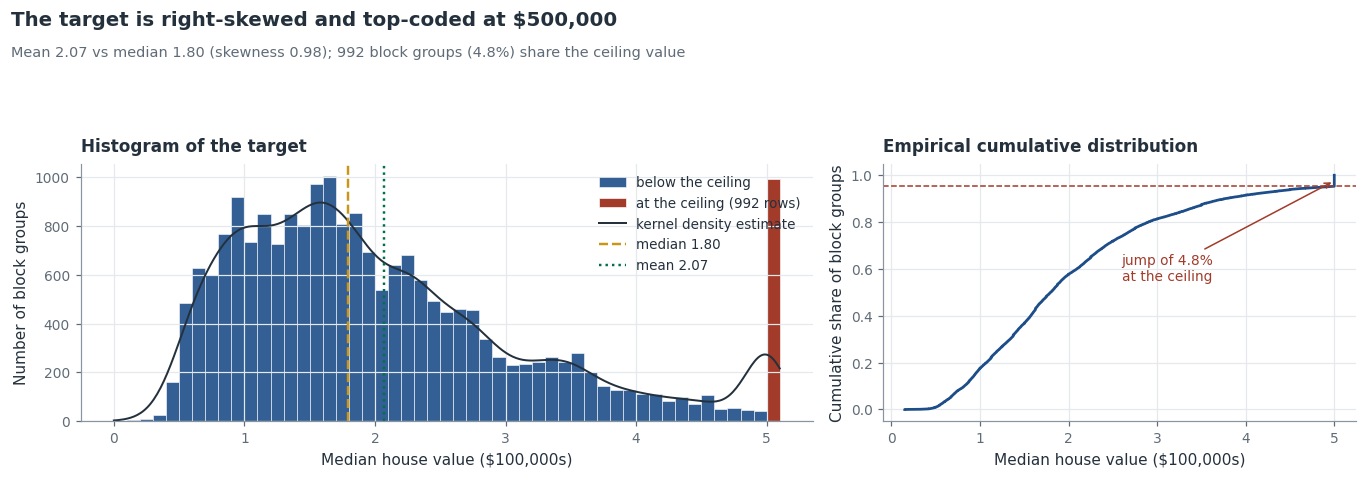

In [10]:
y_np = y_sr.to_numpy()
cap_np = at_cap.to_numpy()
cap_share = cap_np.mean()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": [1.55, 1]})
ax = axes[0]
bins = np.linspace(0, 5.1, 52)
ax.hist(y_np[~cap_np], bins=bins, color=PACIFIC, alpha=0.9, edgecolor="white", linewidth=0.4, label="below the ceiling")
ax.hist(y_np[cap_np], bins=bins, color=REDWOOD, edgecolor="white", linewidth=0.4,
        label=f"at the ceiling ({cap_np.sum():,} rows)")
kde = stats.gaussian_kde(y_np)
xs = np.linspace(0, 5.1, 400)
ax.plot(xs, kde(xs) * len(y_np) * (bins[1] - bins[0]), color=INK, lw=1.3, label="kernel density estimate")
ax.axvline(np.median(y_np), color=GOLD, lw=1.6, ls="--", label=f"median {np.median(y_np):.2f}")
ax.axvline(y_np.mean(), color=HIGHWAY, lw=1.6, ls=":", label=f"mean {y_np.mean():.2f}")
ax.set_xlabel("Median house value (\\$100,000s)")
ax.set_ylabel("Number of block groups")
ax.set_title("Histogram of the target")
ax.legend(loc="upper right")

ax = axes[1]
ys = np.sort(y_np)
ax.plot(ys, np.arange(1, len(ys) + 1) / len(ys), color=PACIFIC, lw=1.8)
ax.axhline(1 - cap_share, color=REDWOOD, lw=1, ls="--")
ax.annotate(f"jump of {cap_share:.1%}\nat the ceiling", xy=(5.0, 1 - cap_share / 2), xytext=(2.6, 0.55),
            fontsize=9, color=REDWOOD, arrowprops=dict(arrowstyle="->", color=REDWOOD, lw=1))
ax.set_xlabel("Median house value (\\$100,000s)")
ax.set_ylabel("Cumulative share of block groups")
ax.set_title("Empirical cumulative distribution")
skew_word = "right-skewed" if y_sr.skew() > 0.5 else "roughly symmetric"
headline(fig, f"The target is {skew_word} and top-coded at {usd_plot(500_000)}",
         f"Mean {y_np.mean():.2f} vs median {np.median(y_np):.2f} (skewness {y_sr.skew():.2f}); "
         f"{cap_np.sum():,} block groups ({cap_share:.1%}) share the ceiling value")
plt.show()

### 1.5 Features on very different scales

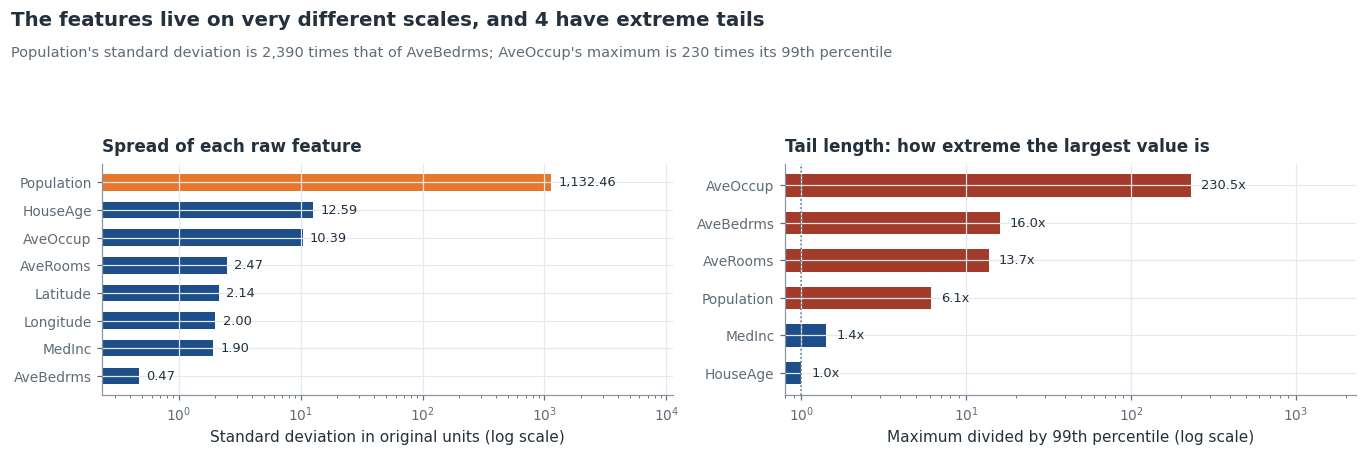

In [11]:
spread = X_df.std().sort_values()
tail_ratio = (X_df[positive].max() / X_df[positive].quantile(0.99)).sort_values()
n_heavy = int((tail_ratio >= 5).sum())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
ax.barh(spread.index, spread.values, color=[POPPY if v >= 100 else PACIFIC for v in spread.values], height=0.6)
ax.set_xscale("log")
for i, v in enumerate(spread.values):
    ax.text(v * 1.15, i, f"{v:,.2f}", va="center", fontsize=8.5, color=INK)
ax.set_xlim(spread.min() / 2, spread.max() * 10)
ax.set_xlabel("Standard deviation in original units (log scale)")
ax.set_title("Spread of each raw feature")

ax = axes[1]
ax.barh(tail_ratio.index, tail_ratio.values, color=[REDWOOD if v >= 5 else PACIFIC for v in tail_ratio.values], height=0.6)
ax.set_xscale("log")
ax.axvline(1, color=SUBTLE, lw=1, ls=":")
for i, v in enumerate(tail_ratio.values):
    ax.text(v * 1.15, i, f"{v:,.1f}x", va="center", fontsize=8.5, color=INK)
ax.set_xlim(0.8, tail_ratio.max() * 10)
ax.set_xlabel("Maximum divided by 99th percentile (log scale)")
ax.set_title("Tail length: how extreme the largest value is")
headline(fig, f"The features live on very different scales, and {n_heavy} have extreme tails",
         f"Population's standard deviation is {X_df['Population'].std() / X_df['AveBedrms'].std():,.0f} times that of "
         f"AveBedrms; AveOccup's maximum is {tail_ratio['AveOccup']:.0f} times its 99th percentile")
plt.show()

### 1.6 Geography of value and of the price ceiling

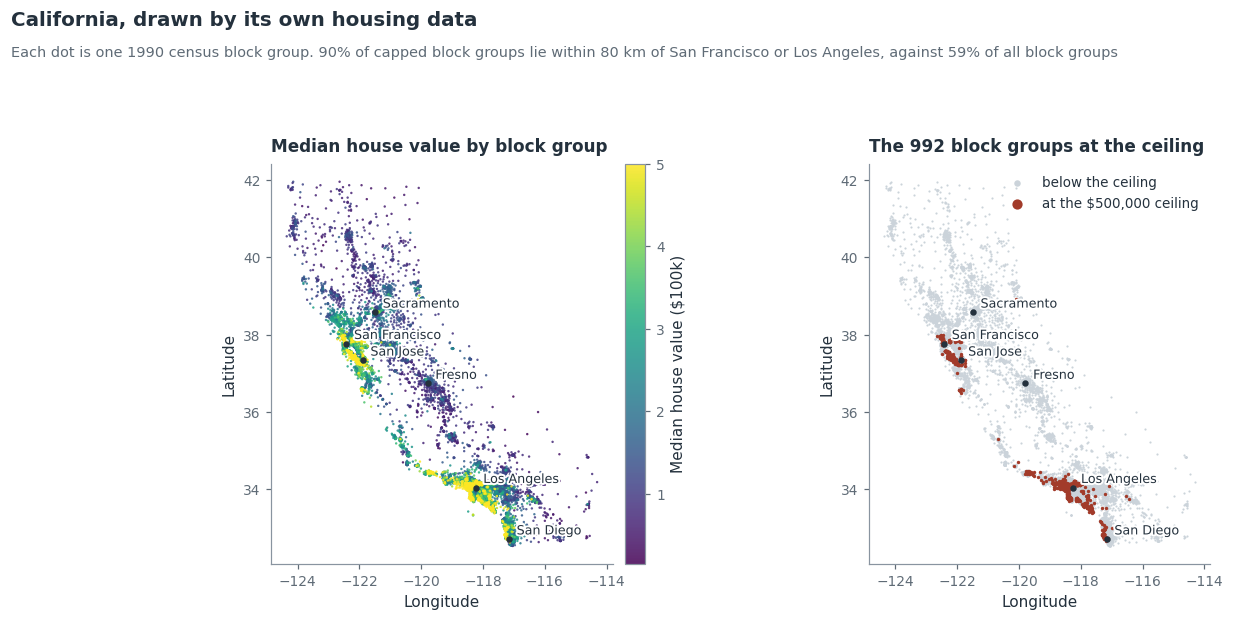

In [12]:
lon, lat = X_df["Longitude"].to_numpy(), X_df["Latitude"].to_numpy()


def within_km(lat0, lon0, km=80):
    dy = (lat - lat0) * 111.0
    dx = (lon - lon0) * 111.0 * np.cos(np.deg2rad(lat0))
    return np.hypot(dx, dy) <= km


near_metro = within_km(*CITIES["San Francisco"]) | within_km(*CITIES["Los Angeles"])
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.7))
order = np.argsort(y_np)
sc = axes[0].scatter(lon[order], lat[order], c=y_np[order], cmap="viridis", s=2.5, linewidths=0, alpha=0.85)
cb = fig.colorbar(sc, ax=axes[0], fraction=0.045, pad=0.02)
cb.set_label("Median house value (\\$100k)")
axes[0].set_title("Median house value by block group")
axes[1].scatter(lon[~cap_np], lat[~cap_np], color="#CBD3DA", s=2, linewidths=0, label="below the ceiling")
axes[1].scatter(lon[cap_np], lat[cap_np], color=REDWOOD, s=5, linewidths=0, label=f"at the {usd_plot(500_000)} ceiling")
axes[1].legend(loc="upper right", markerscale=3)
axes[1].set_title(f"The {cap_np.sum():,} block groups at the ceiling")
for ax in axes:
    geo_axes(ax)
headline(fig, "California, drawn by its own housing data",
         f"Each dot is one 1990 census block group. {near_metro[cap_np].mean():.0%} of capped block groups lie within "
         f"80 km of San Francisco or Los Angeles, against {near_metro.mean():.0%} of all block groups")
plt.show()

### 1.7 Relationships between features and the target

Spearman rank correlations are used because several features are heavily skewed; they measure monotonic association without being dominated by a handful of extreme rows.

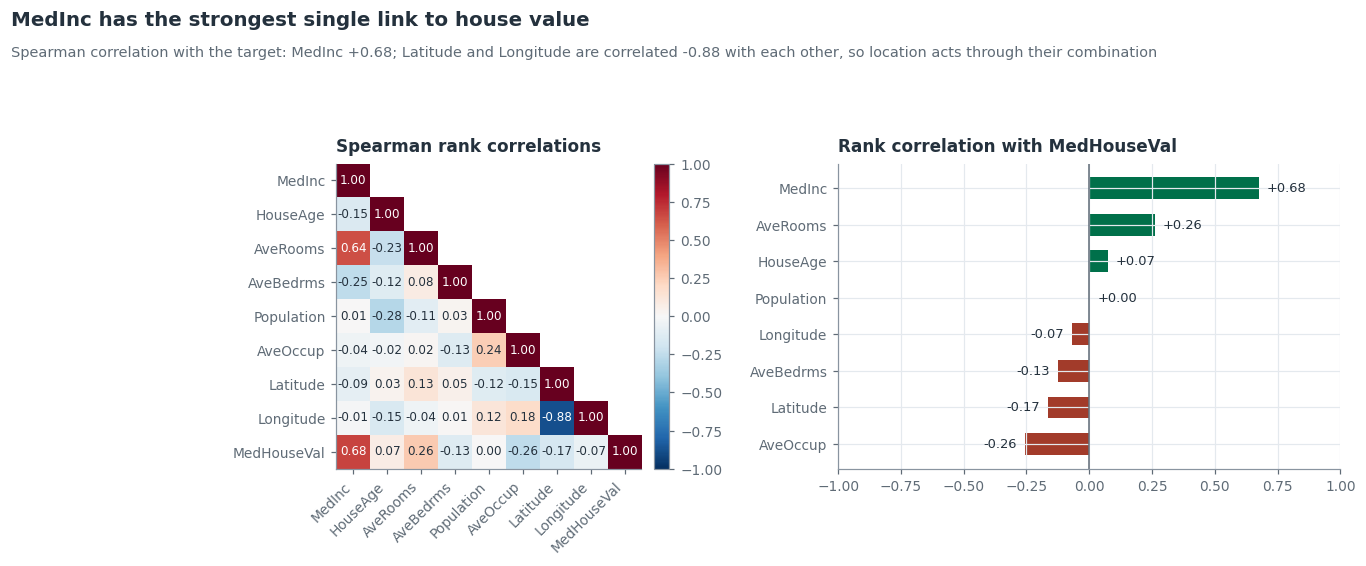

In [13]:
corr = full.corr(method="spearman")
labels = corr.columns.tolist()
upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
with_target = corr[TARGET].drop(TARGET).sort_values()
top_feature = with_target.abs().idxmax()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
im = ax.imshow(np.ma.masked_where(upper, corr.to_numpy()), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(i + 1):
        v = corr.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.8, color="white" if abs(v) > 0.6 else INK)
ax.grid(False)
ax.set_title("Spearman rank correlations")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)

ax = axes[1]
ax.barh(with_target.index, with_target.values, color=[REDWOOD if v < 0 else HIGHWAY for v in with_target.values], height=0.6)
ax.axvline(0, color=SUBTLE, lw=1)
for i, v in enumerate(with_target.values):
    ax.text(v + (0.03 if v >= 0 else -0.03), i, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=8.5)
ax.set_xlim(-1, 1)
ax.set_title(f"Rank correlation with {TARGET}")
headline(fig, f"{top_feature} has the strongest single link to house value",
         f"Spearman correlation with the target: {top_feature} {corr.loc[top_feature, TARGET]:+.2f}; "
         f"Latitude and Longitude are correlated {corr.loc['Latitude', 'Longitude']:+.2f} with each other, "
         "so location acts through their combination")
plt.show()

### 1.8 What the exploration means for preprocessing

The data are clean in the narrow sense. There are 20,640 rows and eight numeric features with no missing or non-finite values, so nothing needs imputing. They are not clean in the statistical sense, and four findings shape what happens next.

**The features sit on very different scales.** Population has a standard deviation above 1,000 people, while AveBedrms varies by less than half a bedroom. Fed to the network unchanged, the weights attached to Population would receive far larger gradients than the others and the loss surface would be badly conditioned. Standardising each feature to zero mean and unit variance is the standard remedy (LeCun et al., 2012), and every model here uses it.

**Four count features have extreme right tails.** AveRooms, AveBedrms, Population and AveOccup have maxima far beyond their 99th percentiles; AveOccup reaches roughly 1,243 people per household. The scikit-learn documentation explains that these per-household averages become very large in block groups with few households and many empty homes, such as resort areas (scikit-learn developers, n.d.). These rows look like real but unusual places rather than recording errors, so I keep them. Standardisation will not tame them, though: after scaling, a handful of rows will still sit dozens of standard deviations from the mean. Extension 5b tests a log transform of these four features as a candidate fix.

**The target is censored.** House values were top-coded at \$500,000 (5.0 in target units), and about 5% of block groups sit exactly at that ceiling. HouseAge and MedInc are top-coded too. A model trained on a censored target learns to predict the ceiling for the most expensive areas instead of their real value, so errors at the top of the market are understated, which is the classic limited-dependent-variable problem (Tobin, 1958). Dropping the capped rows would make the test set unrepresentative, so I keep them and analyse them separately in Step 6.

**Location matters, and it is spatially structured.** The most valuable block groups cluster along the coast around San Francisco and Los Angeles. A random split puts neighbouring block groups into both the training and the test set, so the test error measures how well the model fills gaps on a map it has already seen, not how well it would price an unseen region (Roberts et al., 2017). The data are also aggregated to block groups and date from 1990 (Pace & Barry, 1997). The model therefore describes neighbourhoods in 1990, not individual homes today, and reading its group-level patterns as statements about individual houses would be an ecological fallacy (Robinson, 1950).

**Preprocessing plan.** Split first; standardise with training-set statistics only; keep the outliers and the capped rows; evaluate the capped rows separately at the end.

<a id="step2"></a>

## 2. Data preprocessing

### 2.1 Train, validation and test split (70 / 15 / 15)

I split row indices rather than arrays, so that every later prediction can be traced back to its block group (for the error map in 6b). The first split holds out 30% of the rows; the second divides that 30% evenly into validation and test. Both use the fixed `random_state`, so the split is identical on every run.

In [14]:
X_all = X_df.to_numpy(dtype=np.float32)
y_all = y_sr.to_numpy(dtype=np.float32)
row_ids = np.arange(len(X_all))

idx_train, idx_hold = train_test_split(row_ids, test_size=VAL_FRAC + TEST_FRAC, random_state=SEED, shuffle=True)
idx_val, idx_test = train_test_split(idx_hold, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
                                     random_state=SEED, shuffle=True)
X_train, X_val, X_test = X_all[idx_train], X_all[idx_val], X_all[idx_test]
y_train, y_val, y_test = y_all[idx_train], y_all[idx_val], y_all[idx_test]
SPLITS = {"train": idx_train, "validation": idx_val, "test": idx_test}

assert len(set(idx_train) | set(idx_val) | set(idx_test)) == len(row_ids), "rows lost or duplicated"
split_table = pd.DataFrame({"rows": {name: len(idx) for name, idx in SPLITS.items()}})
split_table["share of all rows"] = (split_table["rows"] / len(row_ids)).map("{:.1%}".format)
display(split_table)

,rows,share of all rows
test,3096,15.0%
train,14448,70.0%
validation,3096,15.0%


### 2.2 Are the three sets comparable?

A random split should give the three sets the same target distribution. The two-sample Kolmogorov–Smirnov statistic *D* is the largest vertical distance between two empirical CDFs; small values mean the held-out sets look like the training set.

,count,mean,std,min,25%,50%,75%,max,share at ceiling,KS D vs train,KS p-value
train,14448.0,2.0692,1.1575,0.150,1.1930,1.7930,2.6460,5.0,0.0492,NaN,NaN
validation,3096.0,2.0680,1.1416,0.150,1.2100,1.8260,2.6440,5.0,0.0452,0.0161,0.5194
test,3096.0,2.0660,1.1501,0.175,1.1987,1.7815,2.6643,5.0,0.0455,0.0092,0.9813


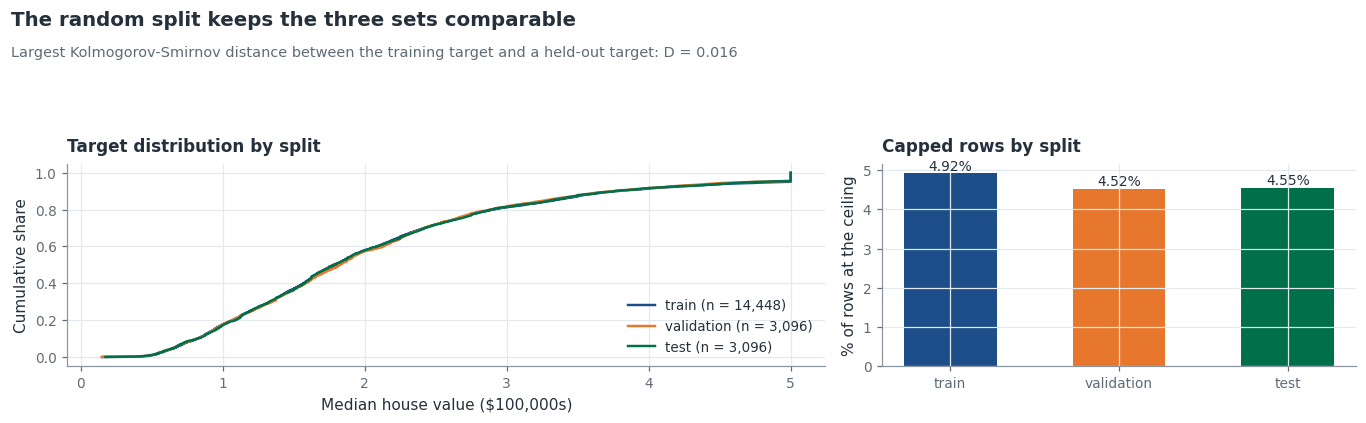

In [15]:
rep = pd.DataFrame({name: pd.Series(y_all[idx]).describe() for name, idx in SPLITS.items()}).T
rep["share at ceiling"] = [np.mean(y_all[idx] >= TARGET_CAP) for idx in SPLITS.values()]
for name in ("validation", "test"):
    ks = stats.ks_2samp(y_train, y_all[SPLITS[name]])
    rep.loc[name, "KS D vs train"] = ks.statistic
    rep.loc[name, "KS p-value"] = ks.pvalue
display(rep.round(4))

split_colors = {"train": PACIFIC, "validation": POPPY, "test": HIGHWAY}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9), gridspec_kw={"width_ratios": [1.6, 1]})
for name, idx in SPLITS.items():
    ys = np.sort(y_all[idx])
    axes[0].plot(ys, np.arange(1, len(ys) + 1) / len(ys), color=split_colors[name], lw=1.6,
                 label=f"{name} (n = {len(idx):,})")
axes[0].set_xlabel("Median house value (\\$100,000s)")
axes[0].set_ylabel("Cumulative share")
axes[0].legend(loc="lower right")
axes[0].set_title("Target distribution by split")
shares = rep["share at ceiling"]
axes[1].bar(shares.index, shares.values * 100, color=[split_colors[k] for k in shares.index], width=0.55)
for i, v in enumerate(shares.values):
    axes[1].text(i, v * 100 + 0.08, f"{v:.2%}", ha="center", fontsize=9)
axes[1].set_ylabel("% of rows at the ceiling")
axes[1].set_title("Capped rows by split")
max_d = rep["KS D vs train"].max()
headline(fig, "The random split keeps the three sets comparable" if max_d < 0.03 else
         "The held-out targets differ noticeably from the training targets",
         f"Largest Kolmogorov-Smirnov distance between the training target and a held-out target: D = {max_d:.3f}")
plt.show()

### 2.3 Standardisation fitted on the training set only

Each feature $j$ is transformed as $z_{ij} = (x_{ij} - \hat{\mu}_j) / \hat{\sigma}_j$, where $\hat{\mu}_j$ and $\hat{\sigma}_j$ are the mean and standard deviation of feature $j$ **in the training rows**. The validation and test rows are transformed with those same training statistics, never with their own.

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)                                         # statistics from the training rows only
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)        # same training statistics, not refitted
X_test_s = scaler.transform(X_test).astype(np.float32)      # same training statistics, not refitted
DATA["raw"] = (X_train_s, y_train, X_val_s, y_val)

after = pd.DataFrame({
    "train mean": X_train_s.mean(axis=0), "train SD": X_train_s.std(axis=0),
    "validation mean": X_val_s.mean(axis=0), "validation SD": X_val_s.std(axis=0),
    "test mean": X_test_s.mean(axis=0), "test SD": X_test_s.std(axis=0),
}, index=FEATURES)
display(after.round(3))

,train mean,train SD,validation mean,validation SD,test mean,test SD
MedInc,0.0,1.0,-0.021,0.974,-0.000,1.008
HouseAge,0.0,1.0,0.016,1.005,0.018,0.980
AveRooms,-0.0,1.0,-0.033,0.731,0.009,1.256
AveBedrms,0.0,1.0,-0.028,0.665,0.008,1.539
Population,0.0,1.0,0.001,1.043,-0.016,0.906
AveOccup,-0.0,1.0,-0.015,0.067,-0.011,0.160
Latitude,-0.0,1.0,-0.056,0.999,-0.002,1.001
Longitude,0.0,1.0,0.056,0.994,-0.008,1.006


### 2.4 Leakage audit and the outliers that scaling leaves behind

To make the leakage argument concrete, the next cell fits a second scaler on all 20,640 rows (the wrong way, used only for this comparison) and measures how far its statistics move from the training-only ones. The figure then shows what standardisation does and does not fix.

,train-only mean,all-data mean,mean shift (train SDs),train-only SD,all-data SD,SD ratio (all / train)
MedInc,3.8769,3.8707,-0.0033,1.9048,1.8998,0.9973
HouseAge,28.5754,28.6395,0.0051,12.6132,12.5853,0.9978
AveRooms,5.4381,5.4290,-0.0037,2.4535,2.4741,1.0084
AveBedrms,1.0980,1.0967,-0.0030,0.4475,0.4739,1.0590
Population,1427.9273,1425.4767,-0.0021,1140.1857,1132.4347,0.9932
AveOccup,3.1192,3.0707,-0.0039,12.3732,10.3858,0.8394
Latitude,35.6507,35.6319,-0.0088,2.1357,2.1359,1.0001
Longitude,-119.5841,-119.5697,0.0072,2.0029,2.0035,1.0003


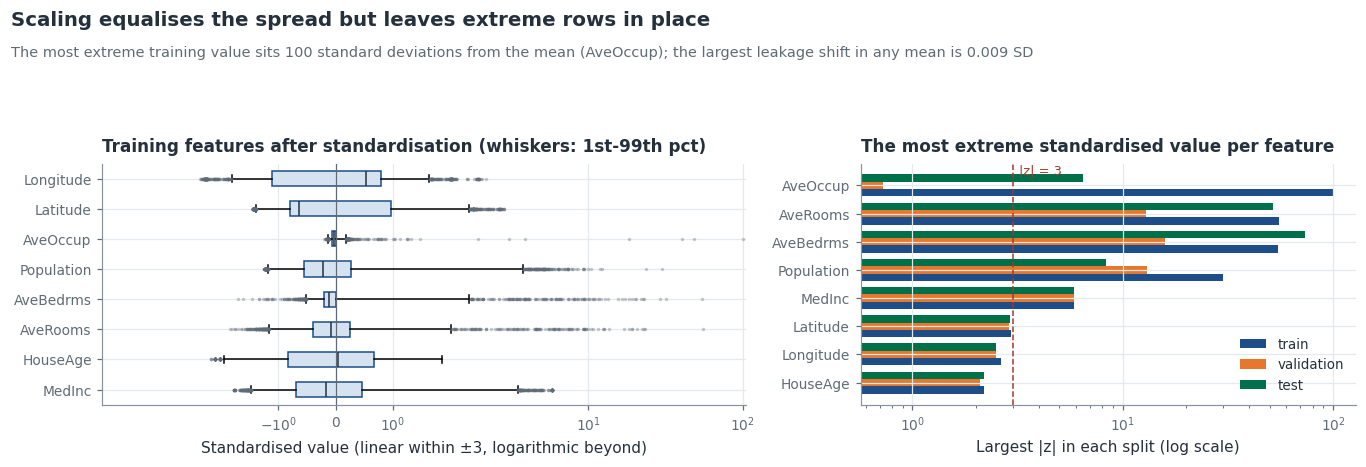

In [17]:
leaky = StandardScaler().fit(X_all)        # deliberately wrong: sees validation and test rows
audit = pd.DataFrame({
    "train-only mean": scaler.mean_, "all-data mean": leaky.mean_,
    "mean shift (train SDs)": (leaky.mean_ - scaler.mean_) / scaler.scale_,
    "train-only SD": scaler.scale_, "all-data SD": leaky.scale_,
    "SD ratio (all / train)": leaky.scale_ / scaler.scale_,
}, index=FEATURES)
display(audit.round(4))

max_z = pd.DataFrame({name: np.abs(arr).max(axis=0) for name, arr in
                      [("train", X_train_s), ("validation", X_val_s), ("test", X_test_s)]}, index=FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
bp = ax.boxplot([X_train_s[:, j] for j in range(len(FEATURES))], vert=False, whis=(1, 99), patch_artist=True,
                medianprops=dict(color=INK), flierprops=dict(marker=".", ms=2.5, alpha=0.35, markeredgecolor=SUBTLE))
for patch in bp["boxes"]:
    patch.set_facecolor("#D5E3F1")
    patch.set_edgecolor(PACIFIC)
ax.set_yticks(range(1, len(FEATURES) + 1), FEATURES)
ax.set_xscale("symlog", linthresh=3)
ax.axvline(0, color=SUBTLE, lw=0.8)
ax.set_xlabel("Standardised value (linear within ±3, logarithmic beyond)")
ax.set_title("Training features after standardisation (whiskers: 1st-99th pct)")

ax = axes[1]
order_z = max_z["train"].sort_values().index
ypos = np.arange(len(order_z))
for k, (name, col) in enumerate(zip(["train", "validation", "test"], [PACIFIC, POPPY, HIGHWAY])):
    ax.barh(ypos + (k - 1) * 0.26, max_z.loc[order_z, name], height=0.26, color=col, label=name)
ax.set_yticks(ypos, order_z)
ax.set_xscale("log")
ax.axvline(3, color=REDWOOD, ls="--", lw=1)
ax.text(3.2, len(order_z) - 0.6, "|z| = 3", color=REDWOOD, fontsize=8.5)
ax.legend(loc="lower right")
ax.set_xlabel("Largest |z| in each split (log scale)")
ax.set_title("The most extreme standardised value per feature")
headline(fig, "Scaling equalises the spread but leaves extreme rows in place",
         f"The most extreme training value sits {max_z['train'].max():.0f} standard deviations from the mean "
         f"({max_z['train'].idxmax()}); the largest leakage shift in any mean is "
         f"{audit['mean shift (train SDs)'].abs().max():.3f} SD")
plt.show()

### 2.5 Why scaling matters, and why the scaler may only see the training set

Gradient descent moves every weight by a step proportional to its gradient, and the gradient of a first-layer weight is proportional to the input it multiplies. With raw inputs, a weight connected to Population (values in the thousands) would receive gradients thousands of times larger than a weight connected to AveBedrms (values near 1), so a single learning rate would be too large for one and too small for the other. Standardising puts all inputs on the same footing, makes the loss surface better conditioned, and keeps the initial pre-activations in the range where tanh and sigmoid units still pass back useful gradients (LeCun et al., 2012; Goodfellow et al., 2016). It also matches the assumption behind Keras's default Glorot initialisation, which sets the initial weight scale for inputs of roughly unit variance (Glorot & Bengio, 2010).

The scaler's means and standard deviations are parameters estimated from data, so they are part of the model. Estimating them on the full dataset would let information about the validation and test rows, including their means, spread and outliers, flow into the training pipeline, and the held-out scores would stop being measurements on genuinely unseen data. That is data leakage (Kaufman et al., 2012). The audit shows that the means would barely move, by less than 0.01 training standard deviations, but the spread of AveOccup would shrink by 16%, because its most extreme block group happens to sit among the training rows; leakage would have changed that feature's scale noticeably. The principle does not depend on the size of the effect, though: a deployed model can only ever be scaled with statistics from data that existed at training time, and the evaluation has to imitate that. The validation and test means in 2.3 are close to zero without being exactly zero, which is the expected signature of a scaler that has seen the training rows only.

<a id="step3"></a>

## 3. Baseline model: build and train

The baseline is the reference configuration for every later comparison.

| Component | Setting |
|---|---|
| Input | 8 standardised features |
| Hidden layer | 64 units, ReLU |
| Output | 1 unit, linear activation |
| Parameters | 8 x 64 + 64 = 576 in the hidden layer, 64 + 1 = 65 in the output layer, 641 in total |
| Optimiser | Adam with Keras defaults, learning rate 0.001 (Kingma & Ba, 2014) |
| Loss and metric | mean squared error (loss), mean absolute error (metric) |
| Batch size and epochs | 64 and 100 |
| Initialisation | Keras defaults: Glorot-uniform weights, zero biases |

A single hidden layer is enough in principle: with sufficiently many units, a one-hidden-layer network can approximate any continuous function on a bounded domain to any accuracy (Hornik et al., 1989). The theorem says nothing about how many units are needed or how easily they train, and those are the practical questions Steps 4 and 5 ask. ReLU is the default activation because it does not saturate for positive inputs, which keeps gradients alive, and it is cheap to compute (Nair & Hinton, 2010; Glorot et al., 2011).

To report the epoch with the lowest validation loss without interfering with training, I attach the `BestEpochTracker` callback defined in Section 0. It copies the weights whenever validation loss reaches a new minimum and never stops training, so the curves below show all 100 epochs.

In [18]:
BASELINE_CFG = make_cfg(hidden_units=64, activation="relu", seed=SEED)

set_global_determinism(SEED)      # same seed -> same initial weights and the same batch order
baseline_model = build_shallow_net(hidden_units=64, activation="relu", n_features=X_train_s.shape[1],
                                   name="baseline_relu64")
baseline_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
baseline_model.summary()

Model: "baseline_relu64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden (Dense)              (None, 64)                576       
                                                                 
 output (Dense)              (None, 1)                 65        
                                                                 
Total params: 641
Trainable params: 641
Non-trainable params: 0
_________________________________________________________________


In [19]:
tracker = BestEpochTracker(monitor="val_loss")
t0 = time.perf_counter()
history = baseline_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=0,
    callbacks=[tracker],
)
baseline = package_result("baseline_relu64", BASELINE_CFG, history.history, tracker,
                          time.perf_counter() - t0, baseline_model.count_params())
RUN_LOG[baseline["name"]] = baseline
print_run(baseline)

baseline_relu64      best val MSE 0.3151 at epoch 100/100 | final train MSE 0.2902 | 59 s


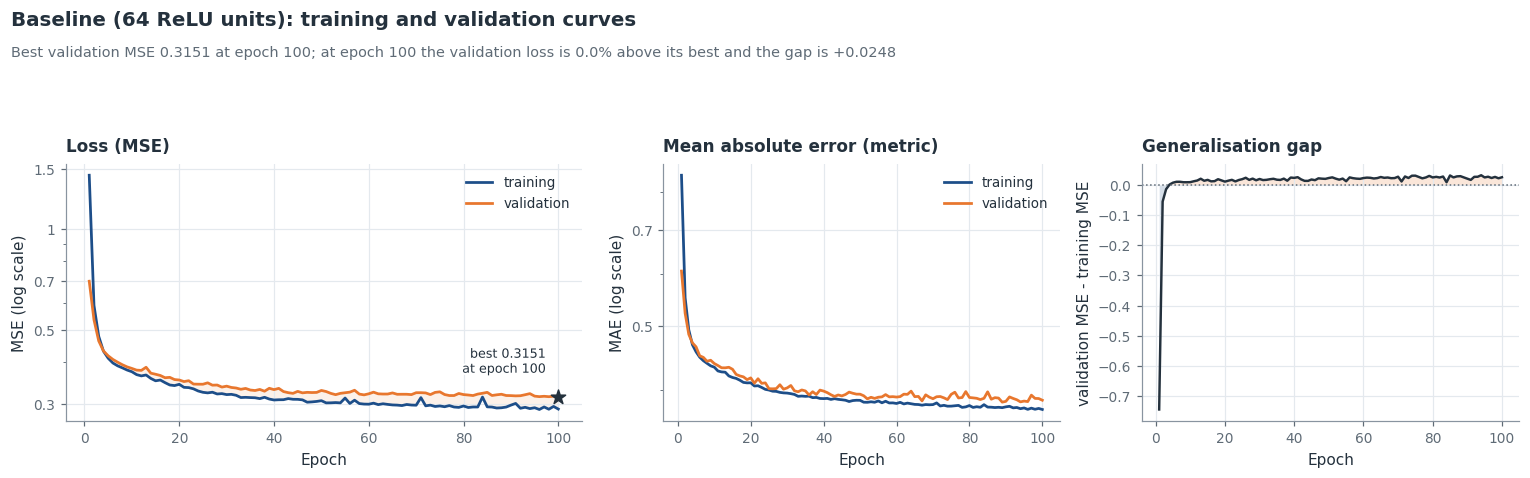

,baseline (64 ReLU)
epoch of best validation MSE,100
best validation MSE,0.3151
final validation MSE above its best (%),0.0000
epochs needed for 95% of the total improvement,33
final training MSE,0.2902
final validation MSE,0.3151
gap at the last epoch (validation - training),0.0248
"gap at the last epoch, % of training MSE",8.5508
largest single-epoch rise in validation MSE after epoch 10,0.0082
change in training MSE over the last 20 epochs (%),-2.0751


In [20]:
tr, va = history_arrays(baseline)
h = baseline["history"]
ep = np.arange(1, len(va) + 1)
s3 = curve_stats(baseline)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.3, 1, 0.95]})
plot_curves(axes[0], baseline)
nice_log_y(axes[0])
axes[0].set_ylabel("MSE (log scale)")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss (MSE)")

axes[1].plot(ep, h["mae"], color=TRAIN_C, lw=1.8, label="training")
axes[1].plot(ep, h["val_mae"], color=VAL_C, lw=1.8, label="validation")
nice_log_y(axes[1])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (log scale)")
axes[1].legend(loc="upper right")
axes[1].set_title("Mean absolute error (metric)")

gap = va - tr
axes[2].plot(ep, gap, color=INK, lw=1.6)
axes[2].axhline(0, color=SUBTLE, lw=1, ls=":")
axes[2].fill_between(ep, 0, gap, where=gap > 0, color=VAL_C, alpha=0.18, lw=0, interpolate=True)
axes[2].fill_between(ep, 0, gap, where=gap <= 0, color=TRAIN_C, alpha=0.18, lw=0, interpolate=True)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("validation MSE - training MSE")
axes[2].set_title("Generalisation gap")
headline(fig, "Baseline (64 ReLU units): training and validation curves",
         f"Best validation MSE {s3['best_val_mse']:.4f} at epoch {s3['best_epoch']}; at epoch {len(va)} the validation "
         f"loss is {s3['end_above_best_pct']:.1f}% above its best and the gap is {s3['gap_end']:+.4f}")
plt.show()

display(stats_frame({"baseline (64 ReLU)": baseline}))

### 3.1 Interpretation of the baseline curves

The baseline learns quickly and cleanly. Validation MSE falls from 0.697 after the first epoch to 0.383 by epoch 10 and 0.330 by epoch 50, and 95% of the total improvement is in place by epoch 33. After that both curves keep sliding slowly downwards. Over the last 20 epochs training MSE fell by another 2.1% and validation MSE by 1.7%, and the lowest validation loss of the run, 0.3151, came in the very last epoch.

There is no sign of overfitting. The validation curve never turns upwards, and at epoch 100 the gap between the curves is small: 0.025, or 8.6% of the training MSE. For the first few epochs the validation loss is actually below the training loss. That is an artefact of how Keras reports the losses, not a property of the model: the training loss is averaged over an epoch during which the weights are still improving, while the validation loss is measured with the weights at the end of the epoch.

If anything, the curves point to mild underfitting, or more precisely to a model that has not finished converging. With both losses still falling, 64 units trained for 100 epochs leave accuracy on the table. That raises two questions: does the network need more capacity, which Step 4 tests, or more training, which the tuning extension in 5b tests?

<a id="step4"></a>

## 4. Experiment: hidden-layer size

| | |
|---|---|
| **What changes** | the number of hidden units: 16, 64 and 256 (161, 641 and 2,561 parameters) |
| **What stays fixed** | data split, scaler, ReLU, Adam with default settings, MSE loss, MAE metric, batch size 64, 100 epochs, seed 42, default initialisation |
| **Why** | width sets the capacity of a shallow network. Too little capacity underfits, with high training and validation loss; more capacity fits the training data more closely, and enough of it opens a gap between training and validation loss (Goodfellow et al., 2016; Hastie et al., 2009) |

**Expectation, written before training.** 16 units should underfit, and 256 units should reach the lowest training loss. Whether 256 units also reach the lowest *validation* loss within 100 epochs is the open question.

**Selection rule, written before training.** A single run can rank two configurations differently from a second run that differs only in its random seed, so a one-seed comparison can mistake noise for an effect (Bouthillier et al., 2021). After the main seed-42 comparison I therefore repeat every width with five seeds and compare the mean best validation loss. If a smaller network's mean lies within one standard error of the best mean, I take the smaller network, following the one-standard-error rule (Hastie et al., 2009). The test set plays no part in this decision.

In [21]:
WIDTHS = [16, 64, 256]
width_runs = {u: run_experiment(make_cfg(u, "relu", seed=SEED), name=f"w{u}_relu_s{SEED}") for u in WIDTHS}

# Reproducibility check: the 64-unit run has exactly the baseline's configuration and seed.
repro_gap = float(np.max(np.abs(np.asarray(width_runs[64]["history"]["val_loss"])
                                - np.asarray(baseline["history"]["val_loss"]))))
print(f"\nLargest per-epoch difference in validation loss between the Step 3 baseline and the Step 4 "
      f"64-unit run: {repro_gap:.2e}")

w16_relu_s42         best val MSE 0.3288 at epoch  96/100 | final train MSE 0.3122 | 67 s
w64_relu_s42         best val MSE 0.3151 at epoch 100/100 | final train MSE 0.2902 | 67 s
w256_relu_s42        best val MSE 0.2918 at epoch  96/100 | final train MSE 0.2668 | 72 s

Largest per-epoch difference in validation loss between the Step 3 baseline and the Step 4 64-unit run: 0.00e+00


### 4.1 Results table (seed 42)

The first three columns after the parameter count are the three core measurements. The remaining columns support the interpretation: the validation loss at the last epoch (to see whether the curve turned upwards after its best point), the gap between validation and training loss at the last epoch, and the number of epochs each model needed to achieve 95% of its total improvement in validation loss.

In [22]:
width_table = experiment_table(width_runs, "Hidden units")
display(width_table.round(4))

,Parameters,Final training loss,Best validation loss,Epoch of best validation loss,Final validation loss,Validation MAE at best epoch,Gap at last epoch,Epochs to 95% of improvement
Hidden units,,,,,,,,
16,161,0.3122,0.3288,96,0.3300,0.3935,0.0178,32
64,641,0.2902,0.3151,100,0.3151,0.3856,0.0248,33
256,2561,0.2668,0.2918,96,0.2981,0.3631,0.0312,72


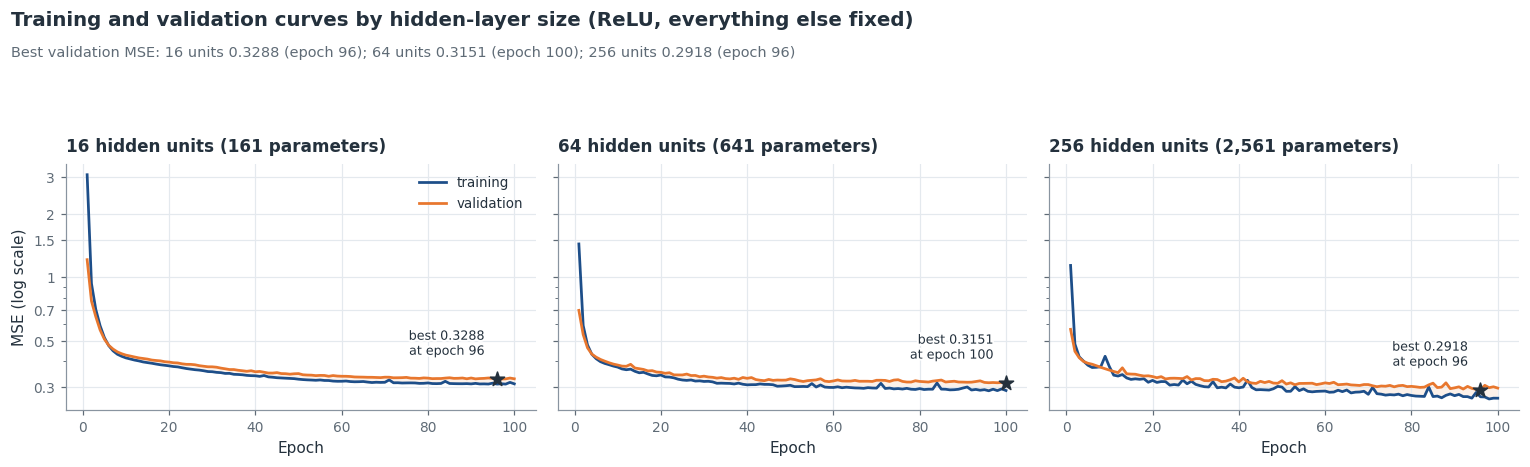

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True)
for ax, u in zip(axes, WIDTHS):
    plot_curves(ax, width_runs[u])
    nice_log_y(ax)
    ax.set_title(f"{u} hidden units ({width_runs[u]['n_params']:,} parameters)")
axes[0].set_ylabel("MSE (log scale)")
axes[0].legend(loc="upper right")
headline(fig, "Training and validation curves by hidden-layer size (ReLU, everything else fixed)",
         "Best validation MSE: " + "; ".join(f"{u} units {width_runs[u]['best_val_loss']:.4f} "
                                              f"(epoch {width_runs[u]['best_epoch']})" for u in WIDTHS))
plt.show()

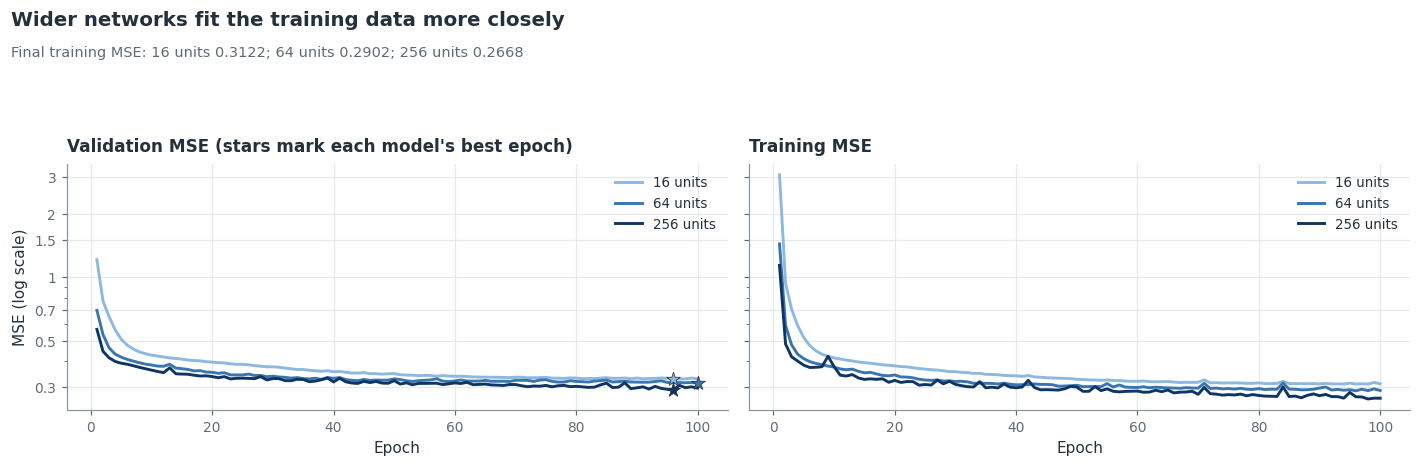

In [24]:
final_train = {u: width_runs[u]["final_train_loss"] for u in WIDTHS}
monotone = all(final_train[a] > final_train[b] for a, b in zip(WIDTHS, WIDTHS[1:]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
for u in WIDTHS:
    tr_u, va_u = history_arrays(width_runs[u])
    ep_u = np.arange(1, len(va_u) + 1)
    axes[0].plot(ep_u, va_u, color=WIDTH_C[u], lw=1.9, label=f"{u} units")
    axes[1].plot(ep_u, tr_u, color=WIDTH_C[u], lw=1.9, label=f"{u} units")
    b = width_runs[u]["best_epoch"]
    axes[0].scatter([b], [va_u[b - 1]], color=WIDTH_C[u], marker="*", s=90, zorder=5, edgecolor=INK, linewidth=0.5)
for ax, title in zip(axes, ["Validation MSE (stars mark each model's best epoch)", "Training MSE"]):
    nice_log_y(ax)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper right")
axes[0].set_ylabel("MSE (log scale)")
headline(fig, "Wider networks fit the training data more closely" if monotone else
         "Training fit does not improve steadily with width",
         "Final training MSE: " + "; ".join(f"{u} units {final_train[u]:.4f}" for u in WIDTHS))
plt.show()

### 4.2 Robustness check across random seeds (extension)

Each width is retrained with four more seeds. Only the seed changes, which alters the initial weights and the order of mini-batches; the data split and everything else stay fixed, so the spread across seeds measures training noise rather than sampling noise.

In [25]:
width_seed_runs = {}
for u in WIDTHS:
    width_seed_runs[u] = {s: (width_runs[u] if s == SEED else
                              run_experiment(make_cfg(u, "relu", seed=s), name=f"w{u}_relu_s{s}"))
                          for s in ROBUSTNESS_SEEDS}
width_seed_table = seed_summary(width_seed_runs)
width_seed_table.index.name = "Hidden units"
display(width_seed_table.round(4))

w16_relu_s7          best val MSE 0.3289 at epoch  99/100 | final train MSE 0.3174 | 62 s
w16_relu_s123        best val MSE 0.3370 at epoch  99/100 | final train MSE 0.3219 | 59 s
w16_relu_s2024       best val MSE 0.3292 at epoch  98/100 | final train MSE 0.3178 | 61 s
w16_relu_s31337      best val MSE 0.3334 at epoch 100/100 | final train MSE 0.3115 | 60 s
w64_relu_s7          best val MSE 0.3144 at epoch  96/100 | final train MSE 0.3009 | 61 s
w64_relu_s123        best val MSE 0.3129 at epoch  99/100 | final train MSE 0.2892 | 70 s
w64_relu_s2024       best val MSE 0.3118 at epoch  98/100 | final train MSE 0.2897 | 62 s
w64_relu_s31337      best val MSE 0.3188 at epoch  97/100 | final train MSE 0.2916 | 81 s
w256_relu_s7         best val MSE 0.2976 at epoch  99/100 | final train MSE 0.2699 | 72 s
w256_relu_s123       best val MSE 0.2913 at epoch  98/100 | final train MSE 0.2698 | 75 s
w256_relu_s2024      best val MSE 0.2861 at epoch  98/100 | final train MSE 0.2637 | 66 s
w256_relu_

,seeds,mean best val loss,SD,SE,min,max,mean best epoch,mean final train loss
Hidden units,,,,,,,,
16,5,0.3314,0.0036,0.0016,0.3288,0.3370,98.4,0.3162
64,5,0.3146,0.0027,0.0012,0.3118,0.3188,98.0,0.2923
256,5,0.2919,0.0041,0.0018,0.2861,0.2976,98.0,0.2665


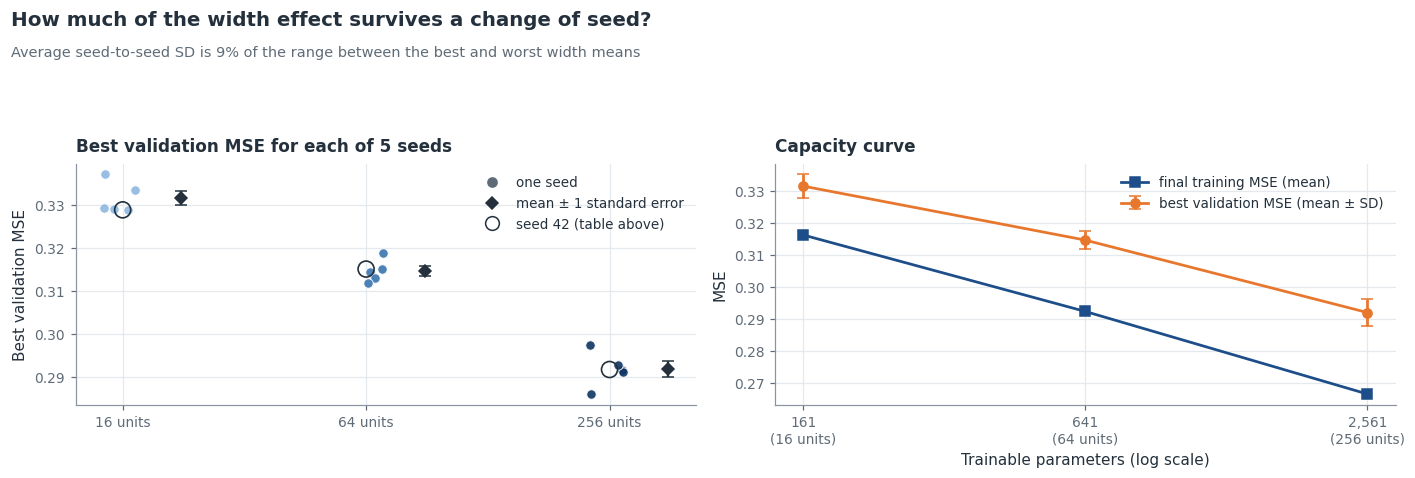

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
jitter = np.random.default_rng(0)
for i, u in enumerate(WIDTHS):
    vals = np.array([r["best_val_loss"] for r in width_seed_runs[u].values()])
    ax.scatter(i + jitter.uniform(-0.08, 0.08, len(vals)), vals, color=WIDTH_C[u], s=38, alpha=0.9,
               edgecolor="white", linewidth=0.6, zorder=3)
    m, se = width_seed_table.loc[u, "mean best val loss"], width_seed_table.loc[u, "SE"]
    ax.errorbar(i + 0.24, m, yerr=0 if not np.isfinite(se) else se, fmt="D", color=INK, ms=6, capsize=4, zorder=4)
    ax.scatter([i], [width_seed_runs[u][SEED]["best_val_loss"]], s=110, facecolor="none", edgecolor=INK, lw=1.1, zorder=5)
ax.set_xticks(range(len(WIDTHS)), [f"{u} units" for u in WIDTHS])
ax.set_ylabel("Best validation MSE")
ax.set_title(f"Best validation MSE for each of {len(ROBUSTNESS_SEEDS)} seeds")
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=SUBTLE, label="one seed"),
                   Line2D([], [], marker="D", ls="", color=INK, label="mean ± 1 standard error"),
                   Line2D([], [], marker="o", ls="", markerfacecolor="none", markeredgecolor=INK,
                          ms=9, label=f"seed {SEED} (table above)")], loc="upper right")

ax = axes[1]
params = [width_runs[u]["n_params"] for u in WIDTHS]
ax.errorbar(params, width_seed_table["mean best val loss"], yerr=np.nan_to_num(width_seed_table["SD"].to_numpy()),
            color=VAL_C, marker="o", lw=1.8, capsize=4, label="best validation MSE (mean ± SD)")
ax.plot(params, width_seed_table["mean final train loss"], color=TRAIN_C, marker="s", lw=1.8,
        label="final training MSE (mean)")
ax.set_xscale("log")
ax.set_xticks(params, [f"{p:,}\n({u} units)" for p, u in zip(params, WIDTHS)])
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlabel("Trainable parameters (log scale)")
ax.set_ylabel("MSE")
ax.legend(loc="upper right")
ax.set_title("Capacity curve")
spread_ratio = width_seed_table["SD"].mean() / np.ptp(width_seed_table["mean best val loss"].to_numpy())
headline(fig, "How much of the width effect survives a change of seed?",
         f"Average seed-to-seed SD is {spread_ratio:.0%} of the range between the best and worst width means")
plt.show()

### 4.3 Selecting the hidden-layer size (validation data only)

In [27]:
choice, best_key, threshold = one_se_choice(width_seed_table, order=sorted(WIDTHS))
single_best = min(WIDTHS, key=lambda u: width_runs[u]["best_val_loss"])
CHOSEN_UNITS = int(choice)
width_decision = pd.Series({
    f"lowest best validation loss, seed-{SEED} run": f"{single_best} units ({width_runs[single_best]['best_val_loss']:.4f})",
    f"lowest mean over {len(ROBUSTNESS_SEEDS)} seeds": f"{best_key} units ({width_seed_table.loc[best_key, 'mean best val loss']:.4f}"
                                                      f" ± {width_seed_table.loc[best_key, 'SE']:.4f} SE)",
    "one-standard-error threshold": f"{threshold:.4f}",
    "smallest width within the threshold": f"{choice} units",
    "selected hidden-layer size": f"{CHOSEN_UNITS} units",
}, name="Step 4 decision (validation data only)")
display(width_decision.to_frame())

,Step 4 decision (validation data only)
"lowest best validation loss, seed-42 run",256 units (0.2918)
lowest mean over 5 seeds,256 units (0.2919 ± 0.0018 SE)
one-standard-error threshold,0.2938
smallest width within the threshold,256 units
selected hidden-layer size,256 units


### 4.4 Interpretation: capacity, convergence and validation performance

Width behaved as capacity theory predicts, with one twist. Training error fell steadily as the layer widened: averaged over five seeds, the final training MSE was 0.316 with 16 units, 0.292 with 64 and 0.267 with 256 (Goodfellow et al., 2016). Validation error fell in step, from 0.331 to 0.315 and 0.292, so the extra capacity went into structure that generalises rather than into noise. The twist is that no width overfitted within 100 epochs. The generalisation gap did widen with width (0.018, 0.025 and 0.031 at the last epoch of the seed-42 runs), which is the early signature of overfitting, but even at 256 units the validation curve was still trending down, and the best epoch came at 96 of 100.

The 16-unit network underfits: it has the highest training and validation errors, and its curves flatten first. The 256-unit network kept improving for longer, needing 72 epochs to achieve 95% of its improvement, against about 33 for the two smaller networks, because it kept finding structure they could not represent. Its validation curve is also visibly noisier: it ended 2.2% above its best value (0.298 against 0.292). That is why keeping the best-epoch weights matters more as networks grow.

The seed analysis makes the decision unambiguous. Seed-to-seed standard deviations were 0.003 to 0.004, while the gap between 64 and 256 units was 0.023, about six standard deviations; the best validation losses across seeds do not even overlap between widths. The one-standard-error threshold was 0.2938 and only 256 units fell below it (Hastie et al., 2009), so 256 units go forward to Step 5.

<a id="step5"></a>

## 5. Experiment: activation function

| | |
|---|---|
| **What changes** | the hidden-layer activation: ReLU, tanh and sigmoid |
| **What stays fixed** | the hidden-layer size selected in Step 4 and every other setting, including Keras default initialisation (Glorot-uniform weights, zero biases) for all three models |
| **Why** | the activation shapes both what the network can represent and how easily it trains |

**What theory predicts.** Sigmoid and tanh saturate: for large |z| their derivatives approach zero, so a unit that drifts into those regions passes back almost no gradient and stops learning. Sigmoid carries two further handicaps. Its largest derivative is 0.25, a quarter of tanh's, and its outputs are always positive, which LeCun et al. (2012) show slows gradient descent compared with zero-centred units such as tanh. ReLU does not saturate for positive inputs, but a unit whose input is negative for every training example receives no gradient at all (Glorot et al., 2011). The first figure below shows the three functions, their derivatives, and where the standardised training data actually place the first-layer pre-activations at initialisation.

**How I measure convergence and stability.** Besides the best validation loss and its epoch, convergence speed is measured in two ways: the number of epochs needed to reach a common target (110% of the best validation loss achieved by any of the three activations) and the epoch by which each model achieved 95% of its own improvement. Stability is measured as the standard deviation of epoch-to-epoch changes in validation loss over the last 30 epochs, and as the largest single-epoch rise after epoch 10.

**Selection rule.** The same five-seed protocol as Step 4: the lowest mean best validation loss wins, and a tie within one standard error goes to ReLU, the cheapest of the three to compute.

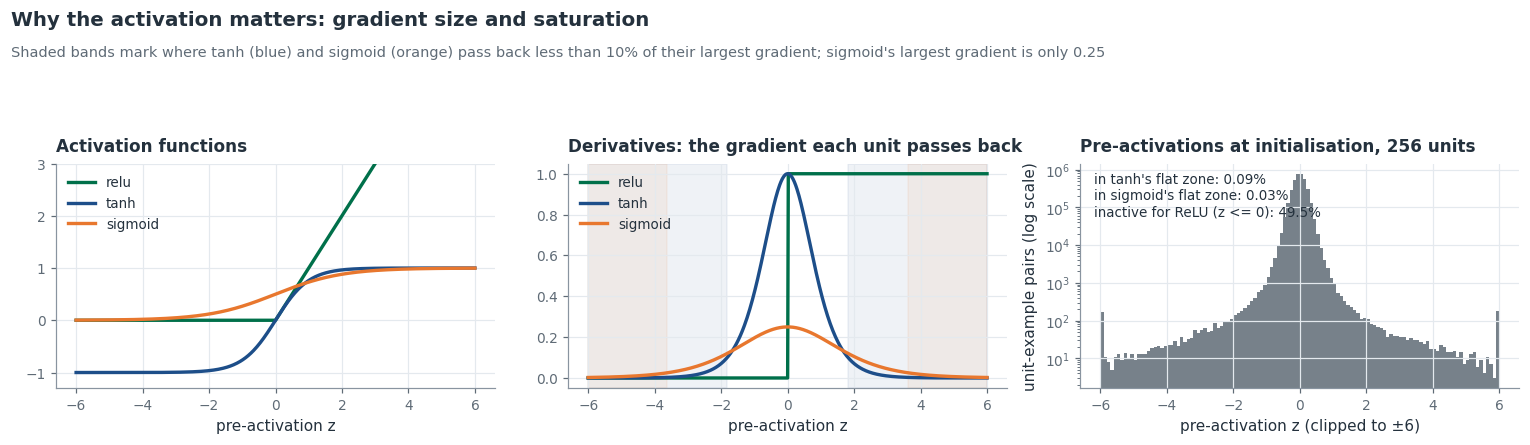

In [28]:
z = np.linspace(-6, 6, 601)
sig = 1 / (1 + np.exp(-z))
act_f = {"relu": np.maximum(z, 0), "tanh": np.tanh(z), "sigmoid": sig}
act_d = {"relu": (z > 0).astype(float), "tanh": 1 - np.tanh(z) ** 2, "sigmoid": sig * (1 - sig)}
# "Saturated" = derivative below 10% of its maximum (|z| > 1.82 for tanh, |z| > 3.64 for sigmoid)
SAT_LIMITS = {"tanh": float(np.arctanh(np.sqrt(0.9))), "sigmoid": float(np.log((1 + np.sqrt(0.9)) / (1 - np.sqrt(0.9))))}

# First-layer pre-activations at initialisation: the exact initial weights used by the Step 5 models
set_global_determinism(SEED)
probe = build_shallow_net(CHOSEN_UNITS, "relu", X_train_s.shape[1])
W0, b0 = probe.get_layer("hidden").get_weights()
z0 = (X_train_s @ W0 + b0).ravel()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
for name in ["relu", "tanh", "sigmoid"]:
    axes[0].plot(z, act_f[name], color=ACT_C[name], lw=2.2, label=name)
    axes[1].plot(z, act_d[name], color=ACT_C[name], lw=2.2, label=name)
for name in ["tanh", "sigmoid"]:
    lim = SAT_LIMITS[name]
    axes[1].axvspan(lim, 6, color=ACT_C[name], alpha=0.07)
    axes[1].axvspan(-6, -lim, color=ACT_C[name], alpha=0.07)
axes[0].set_ylim(-1.3, 3.0)
axes[0].set_title("Activation functions")
axes[1].set_title("Derivatives: the gradient each unit passes back")
for ax in axes[:2]:
    ax.set_xlabel("pre-activation z")
    ax.legend(loc="upper left")
axes[2].hist(np.clip(z0, -6, 6), bins=120, color=SUBTLE, alpha=0.85)
axes[2].set_yscale("log")
axes[2].set_xlabel("pre-activation z (clipped to ±6)")
axes[2].set_ylabel("unit-example pairs (log scale)")
axes[2].set_title(f"Pre-activations at initialisation, {CHOSEN_UNITS} units")
axes[2].text(0.03, 0.96, f"in tanh's flat zone: {np.mean(np.abs(z0) > SAT_LIMITS['tanh']):.2%}\n"
                          f"in sigmoid's flat zone: {np.mean(np.abs(z0) > SAT_LIMITS['sigmoid']):.2%}\n"
                          f"inactive for ReLU (z <= 0): {np.mean(z0 <= 0):.1%}",
             transform=axes[2].transAxes, va="top", fontsize=8.8, color=INK)
headline(fig, "Why the activation matters: gradient size and saturation",
         "Shaded bands mark where tanh (blue) and sigmoid (orange) pass back less than 10% of their largest gradient; "
         "sigmoid's largest gradient is only 0.25")
plt.show()

In [29]:
ACTIVATIONS = ["relu", "tanh", "sigmoid"]
act_runs = {"relu": width_runs[CHOSEN_UNITS]}     # identical configuration, already trained in Step 4
for act in ["tanh", "sigmoid"]:
    act_runs[act] = run_experiment(make_cfg(CHOSEN_UNITS, act, seed=SEED), name=f"w{CHOSEN_UNITS}_{act}_s{SEED}")

w256_tanh_s42        best val MSE 0.3283 at epoch 100/100 | final train MSE 0.3120 | 73 s
w256_sigmoid_s42     best val MSE 0.3559 at epoch 100/100 | final train MSE 0.3383 | 88 s


### 5.1 Results table (seed 42)

In [30]:
best_any = min(r["best_val_loss"] for r in act_runs.values())
target_level = 1.10 * best_any
rows = []
for act, res in act_runs.items():
    tr_a, va_a = history_arrays(res)
    s = curve_stats(res)
    reached = np.flatnonzero(va_a <= target_level)
    rows.append({"Activation": act, "Best validation loss": s["best_val_mse"],
                 "Epoch of best validation loss": s["best_epoch"],
                 "Final training loss": s["final_train_mse"], "Final validation loss": s["final_val_mse"],
                 "Epochs to common target": float(reached[0] + 1) if reached.size else np.nan,
                 "Epochs to 95% of own improvement": s["epochs_to_95pct"],
                 "Volatility, last 30 epochs (x 1e-3)": s["val_volatility_x1e3"],
                 "Largest rise after epoch 10": s["max_val_rise"],
                 "Gap at last epoch": s["gap_end"]})
act_table = pd.DataFrame(rows).set_index("Activation")
print(f"Common convergence target = 110% of the best validation loss of any activation = {target_level:.4f} "
      "(NaN = never reached)")
display(act_table.round(4))

Common convergence target = 110% of the best validation loss of any activation = 0.3210 (NaN = never reached)


,Best validation loss,Epoch of best validation loss,Final training loss,Final validation loss,Epochs to common target,Epochs to 95% of own improvement,"Volatility, last 30 epochs (x 1e-3)",Largest rise after epoch 10,Gap at last epoch
Activation,,,,,,,,,
relu,0.2918,96,0.2668,0.2981,36.0,72,7.2360,0.0191,0.0312
tanh,0.3283,100,0.3120,0.3283,NaN,83,4.9054,0.0147,0.0162
sigmoid,0.3559,100,0.3383,0.3559,NaN,89,4.7507,0.0216,0.0176


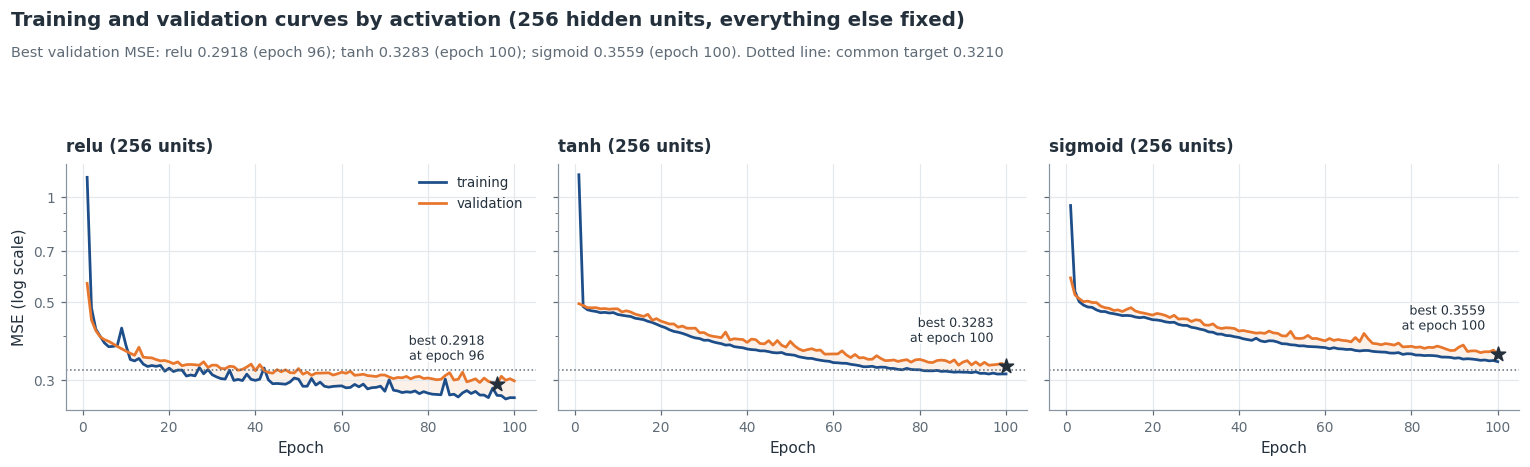

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True)
for ax, act in zip(axes, ACTIVATIONS):
    plot_curves(ax, act_runs[act])
    nice_log_y(ax)
    ax.axhline(target_level, color=SUBTLE, lw=1, ls=":")
    ax.set_title(f"{act} ({CHOSEN_UNITS} units)")
axes[0].set_ylabel("MSE (log scale)")
axes[0].legend(loc="upper right")
headline(fig, f"Training and validation curves by activation ({CHOSEN_UNITS} hidden units, everything else fixed)",
         "Best validation MSE: " + "; ".join(f"{a} {act_runs[a]['best_val_loss']:.4f} (epoch {act_runs[a]['best_epoch']})"
                                              for a in ACTIVATIONS) + f". Dotted line: common target {target_level:.4f}")
plt.show()

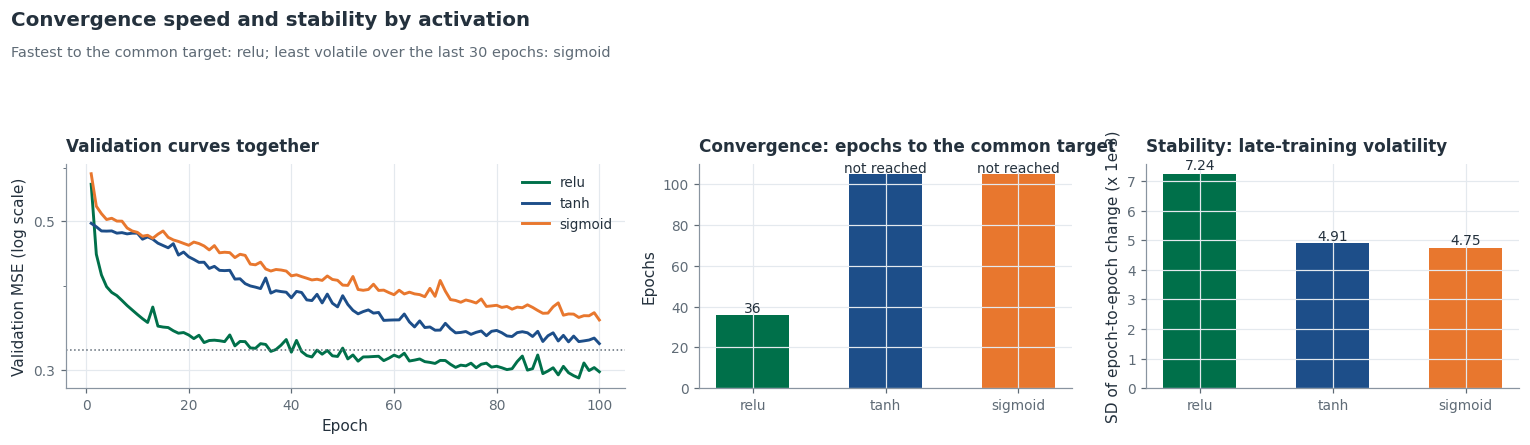

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1), gridspec_kw={"width_ratios": [1.5, 1, 1]})
for act in ACTIVATIONS:
    _, va_a = history_arrays(act_runs[act])
    axes[0].plot(np.arange(1, len(va_a) + 1), va_a, color=ACT_C[act], lw=1.9, label=act)
axes[0].axhline(target_level, color=SUBTLE, lw=1, ls=":")
nice_log_y(axes[0])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation MSE (log scale)")
axes[0].legend(loc="upper right")
axes[0].set_title("Validation curves together")
bars = act_table["Epochs to common target"].fillna(EPOCHS + 5)
axes[1].bar(ACTIVATIONS, bars[ACTIVATIONS], color=[ACT_C[a] for a in ACTIVATIONS], width=0.55)
for i, a in enumerate(ACTIVATIONS):
    v = act_table.loc[a, "Epochs to common target"]
    axes[1].text(i, bars[a] + 1, "not reached" if np.isnan(v) else f"{v:.0f}", ha="center", fontsize=9)
axes[1].set_ylabel("Epochs")
axes[1].set_title("Convergence: epochs to the common target")
vol = act_table["Volatility, last 30 epochs (x 1e-3)"]
axes[2].bar(ACTIVATIONS, vol[ACTIVATIONS], color=[ACT_C[a] for a in ACTIVATIONS], width=0.55)
for i, a in enumerate(ACTIVATIONS):
    axes[2].text(i, vol[a] * 1.02, f"{vol[a]:.2f}", ha="center", fontsize=9)
axes[2].set_ylabel("SD of epoch-to-epoch change (x 1e-3)")
axes[2].set_title("Stability: late-training volatility")
fastest = act_table["Epochs to common target"].idxmin() if act_table["Epochs to common target"].notna().any() else "none"
steadiest = vol.idxmin()
headline(fig, "Convergence speed and stability by activation",
         f"Fastest to the common target: {fastest}; least volatile over the last 30 epochs: {steadiest}")
plt.show()

### 5.2 Robustness across seeds and a look inside the hidden layer (extension)

The seed check repeats Step 4's protocol. The saturation analysis then uses each trained model's best-epoch weights to compute the hidden-layer pre-activations $z = xW_1 + b_1$ for every training example, and counts how often each unit sits in the flat part of its activation. For ReLU, being inactive for roughly half of the examples is normal and even useful (it makes the representation sparse); what matters is whether some units are inactive for almost every example, because those units have stopped learning.

In [33]:
act_seed_runs = {"relu": width_seed_runs[CHOSEN_UNITS]}
for act in ["tanh", "sigmoid"]:
    act_seed_runs[act] = {s: (act_runs[act] if s == SEED else
                              run_experiment(make_cfg(CHOSEN_UNITS, act, seed=s), name=f"w{CHOSEN_UNITS}_{act}_s{s}"))
                          for s in ROBUSTNESS_SEEDS}
act_seed_table = seed_summary(act_seed_runs)
act_seed_table.index.name = "Activation"
display(act_seed_table.round(4))

w256_tanh_s7         best val MSE 0.3289 at epoch  94/100 | final train MSE 0.3118 | 62 s
w256_tanh_s123       best val MSE 0.3281 at epoch  97/100 | final train MSE 0.3122 | 65 s
w256_tanh_s2024      best val MSE 0.3272 at epoch  97/100 | final train MSE 0.3103 | 83 s
w256_tanh_s31337     best val MSE 0.3276 at epoch  98/100 | final train MSE 0.3106 | 77 s
w256_sigmoid_s7      best val MSE 0.3569 at epoch 100/100 | final train MSE 0.3348 | 77 s
w256_sigmoid_s123    best val MSE 0.3596 at epoch  99/100 | final train MSE 0.3411 | 69 s
w256_sigmoid_s2024   best val MSE 0.3653 at epoch  97/100 | final train MSE 0.3428 | 75 s
w256_sigmoid_s31337  best val MSE 0.3551 at epoch  99/100 | final train MSE 0.3439 | 70 s


,seeds,mean best val loss,SD,SE,min,max,mean best epoch,mean final train loss
Activation,,,,,,,,
relu,5,0.2919,0.0041,0.0018,0.2861,0.2976,98.0,0.2665
tanh,5,0.3280,0.0007,0.0003,0.3272,0.3289,97.2,0.3114
sigmoid,5,0.3586,0.0041,0.0019,0.3551,0.3653,99.0,0.3402


,flat region (ReLU: z <= 0; others: saturated),share of unit-example pairs in the flat region,units flat for more than 99% of examples,units in the layer,median |z|
Activation,,,,,
relu,z <= 0,0.5713,4,256,0.2456
tanh,|z| > 1.82,0.0091,0,256,0.1594
sigmoid,|z| > 3.64,0.0119,0,256,0.3961


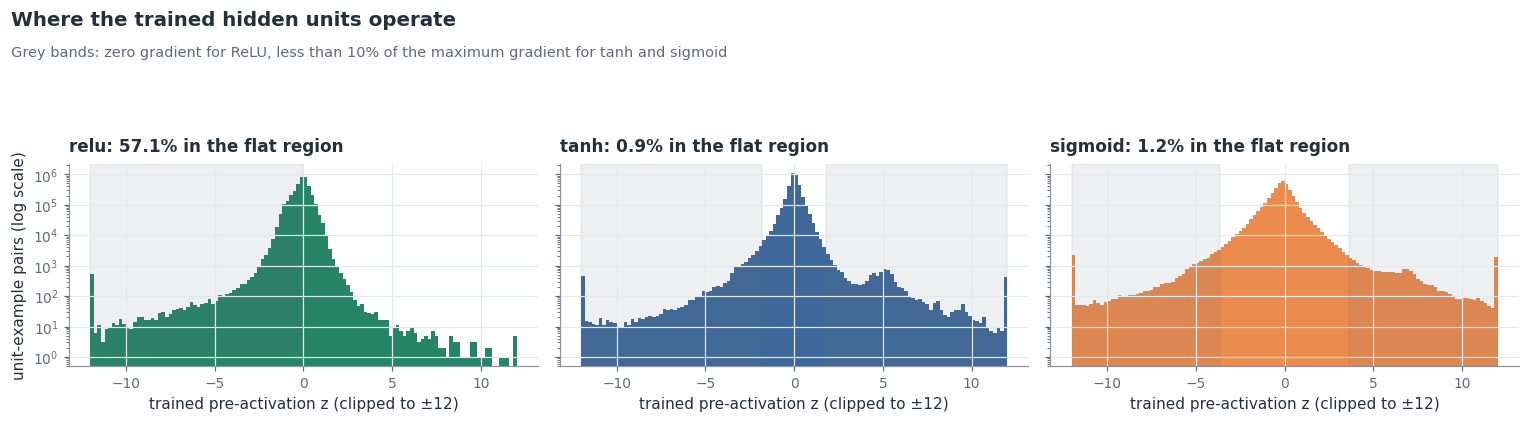

In [34]:
sat_rows, Z_trained = [], {}
for act, res in act_runs.items():
    W1, b1 = res["best_weights"][0], res["best_weights"][1]
    Z = X_train_s @ W1 + b1
    Z_trained[act] = Z
    flat = (Z <= 0) if act == "relu" else (np.abs(Z) > SAT_LIMITS[act])
    sat_rows.append({"Activation": act,
                     "flat region (ReLU: z <= 0; others: saturated)": "z <= 0" if act == "relu" else f"|z| > {SAT_LIMITS[act]:.2f}",
                     "share of unit-example pairs in the flat region": flat.mean(),
                     "units flat for more than 99% of examples": int((flat.mean(axis=0) > 0.99).sum()),
                     "units in the layer": Z.shape[1],
                     "median |z|": float(np.median(np.abs(Z)))})
sat_table = pd.DataFrame(sat_rows).set_index("Activation")
display(sat_table.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9), sharey=True)
for ax, act in zip(axes, ACTIVATIONS):
    zz = np.clip(Z_trained[act].ravel(), -12, 12)
    ax.hist(zz, bins=120, color=ACT_C[act], alpha=0.85)
    if act == "relu":
        ax.axvspan(-12, 0, color=SUBTLE, alpha=0.10)
    else:
        lim = SAT_LIMITS[act]
        ax.axvspan(lim, 12, color=SUBTLE, alpha=0.10)
        ax.axvspan(-12, -lim, color=SUBTLE, alpha=0.10)
    ax.set_yscale("log")
    ax.set_title(f"{act}: {sat_table.loc[act, 'share of unit-example pairs in the flat region']:.1%} in the flat region")
    ax.set_xlabel("trained pre-activation z (clipped to ±12)")
axes[0].set_ylabel("unit-example pairs (log scale)")
headline(fig, "Where the trained hidden units operate",
         "Grey bands: zero gradient for ReLU, less than 10% of the maximum gradient for tanh and sigmoid")
plt.show()

### 5.3 Selecting the activation function (validation data only)

In [35]:
act_choice, act_best, act_threshold = one_se_choice(act_seed_table, order=ACTIVATIONS)
single_best_act = min(ACTIVATIONS, key=lambda a: act_runs[a]["best_val_loss"])
CHOSEN_ACT = str(act_choice)
FINAL_RES = act_runs[CHOSEN_ACT]          # seed-42 run of the selected configuration
act_decision = pd.Series({
    f"lowest best validation loss, seed-{SEED} run": f"{single_best_act} ({act_runs[single_best_act]['best_val_loss']:.4f})",
    f"lowest mean over {len(ROBUSTNESS_SEEDS)} seeds": f"{act_best} ({act_seed_table.loc[act_best, 'mean best val loss']:.4f}"
                                                      f" ± {act_seed_table.loc[act_best, 'SE']:.4f} SE)",
    "one-standard-error threshold": f"{act_threshold:.4f}",
    "selected activation (ties go to ReLU)": CHOSEN_ACT,
    "final configuration": f"{CHOSEN_UNITS} {CHOSEN_ACT} units",
}, name="Step 5 decision (validation data only)")
display(act_decision.to_frame())

,Step 5 decision (validation data only)
"lowest best validation loss, seed-42 run",relu (0.2918)
lowest mean over 5 seeds,relu (0.2919 ± 0.0018 SE)
one-standard-error threshold,0.2938
selected activation (ties go to ReLU),relu
final configuration,256 relu units


### 5.4 Interpretation: convergence speed, stability and validation performance

ReLU won on every measure of accuracy and speed. Its mean best validation MSE over five seeds was 0.292, against 0.328 for tanh and 0.359 for sigmoid, and the seed ranges do not overlap. It reached the common target of 0.321 (110% of the best result) after 36 epochs, while neither tanh nor sigmoid reached it within 100. Both smooth activations show a characteristic plateau. Tanh actually started better than ReLU (0.496 after one epoch against 0.567), but it then stalled near 0.48 for ten epochs, and sigmoid only drifted from 0.48 to 0.46 between epochs 10 and 25. Both descended slowly after that, and both were still improving at epoch 100, which is where their best validation losses came.

The mechanism is more interesting than the textbook story. Saturation was not the problem: after training, only 0.9% of tanh pre-activations and 1.2% of sigmoid pre-activations sat on the flat parts of their curves, because standardised inputs and Glorot initialisation keep the pre-activations near zero (Glorot & Bengio, 2010). Near zero, however, both functions are almost linear (the median pre-activation was 0.16 for tanh and 0.40 for sigmoid), so both networks begin life close to a linear model and must grow their weights before the non-linearity starts to pay. Sigmoid is handicapped twice over, since its slope there is only a quarter of tanh's and its outputs are always positive (LeCun et al., 2012). ReLU, in contrast, is non-linear at every scale: its kink at zero exists however small the weights are. About 57% of ReLU unit-example pairs were inactive, which is the normal sparsity of rectifiers rather than a fault (Glorot et al., 2011), and only 4 of the 256 units were effectively dead.

Stability tells the opposite story. ReLU's validation curve was the most volatile late in training: the standard deviation of its epoch-to-epoch changes over the last 30 epochs was 7.2 × 10⁻³, against 4.9 × 10⁻³ for tanh and 4.8 × 10⁻³ for sigmoid. Tanh was also by far the most consistent across seeds, with a standard deviation of 0.0007. The smooth activations learn smoothly but slowly; ReLU learns faster and further but more bumpily. The selection rule rewards accuracy and the best-epoch weights absorb the bumps, so ReLU is selected, and the final configuration is 256 ReLU units.

<a id="ext-a"></a>

## 5b. Extension: hyperparameter search (validation data only)

The core protocol fixes Adam's default learning rate and a single batch size, and Steps 4 and 5 respect both. This extension asks a different question: how much better can a *shallow* network get on these data if its remaining hyperparameters are tuned? Three constraints keep the answer honest. The architecture stays shallow, with one hidden layer. The batch size stays at 64, so the one-batch-size rule still holds. And the search uses only the training and validation sets, before the test set is opened in Step 6.

| Hyperparameter | Values searched | Why it is in the search |
|---|---|---|
| Hidden units | 32, 64, 128, 256, 512 | extends the capacity range of Step 4 |
| Activation | ReLU, ELU, GELU, tanh | adds two smooth relatives of ReLU (Clevert et al., 2016; Hendrycks & Gimpel, 2016); sigmoid is dropped after Step 5 |
| Adam learning rate | log-uniform between 0.0003 and 0.01 | the setting that most often decides how well Adam trains (Kingma & Ba, 2014) |
| L2 weight decay | 0, 1e-6, 1e-5, 1e-4 | penalises large weights (Krogh & Hertz, 1992) |
| Dropout after the hidden layer | 0, 0.1, 0.2 | randomly silences hidden units during training (Srivastava et al., 2014) |
| Feature transform | standardised raw features, or log1p of the four heavy-tailed counts followed by standardisation | tests the heavy-tail hypothesis from Step 1 |

**Training protocol for every trial.** Up to 300 epochs, early stopping on validation MSE with a patience of 20 epochs and restoration of the best weights (Prechelt, 2012), and a halving of the learning rate whenever validation MSE stalls for 8 epochs. Trials are compared on validation MSE *without* the L2 penalty, so weight decay cannot make a trial look better or worse through its penalty term alone.

**Why random search.** With a fixed budget, random sampling covers each individual hyperparameter more densely than a grid does, which matters when only a few of them have a real effect (Bergstra & Bengio, 2012). Trial 0 is an anchor: the configuration selected in Steps 4 and 5, trained under the new protocol, which separates the effect of the protocol from the effect of the hyperparameters.

**The winner's curse.** Picking the best of 25 noisy scores rewards luck as well as quality, so the winning validation score is biased downwards (Cawley & Talbot, 2010). To reduce that bias, the three best configurations are retrained with two more seeds, and the champion is the configuration with the lowest mean.

### 5b.1 A log-transformed copy of the features

In [36]:
LOG_FEATURES = ["AveRooms", "AveBedrms", "Population", "AveOccup"]
LOG_IDX = [FEATURES.index(f) for f in LOG_FEATURES]


def log1p_heavy(X):
    """log(1 + x) for the four heavy-tailed count features; every other column is unchanged."""
    out = np.array(X, dtype=np.float64, copy=True)
    out[:, LOG_IDX] = np.log1p(out[:, LOG_IDX])
    return out


scaler_log = StandardScaler().fit(log1p_heavy(X_train))      # fitted on training rows only, as in Step 2
X_train_l, X_val_l, X_test_l = (scaler_log.transform(log1p_heavy(X)).astype(np.float32)
                                for X in (X_train, X_val, X_test))
DATA["log"] = (X_train_l, y_train, X_val_l, y_val)
VAL_INPUTS = {"raw": X_val_s, "log": X_val_l}
TEST_INPUTS = {"raw": X_test_s, "log": X_test_l}

display(pd.DataFrame({"largest |z|, standardised raw features": np.abs(X_train_s).max(axis=0),
                      "largest |z|, log1p then standardised": np.abs(X_train_l).max(axis=0)},
                     index=FEATURES).round(1))

,"largest |z|, standardised raw features","largest |z|, log1p then standardised"
MedInc,5.8,5.8
HouseAge,2.2,2.2
AveRooms,55.6,13.4
AveBedrms,54.8,24.0
Population,30.0,7.7
AveOccup,100.2,27.2
Latitude,2.9,2.9
Longitude,2.6,2.6


### 5b.2 Random search

In [37]:
SPACE = {
    "hidden_units": [32, 64, 128, 256, 512],
    "activation": ["relu", "elu", "gelu", "tanh"],
    "lr": [3e-4, 1e-2],                    # bounds; sampled log-uniformly
    "l2": [0.0, 1e-6, 1e-5, 1e-4],
    "dropout": [0.0, 0.1, 0.2],
    "features": ["raw", "log"],
}
HP_COLS = ["hidden_units", "activation", "lr", "l2", "dropout", "features"]
search_rng = np.random.default_rng(SEED)


def sample_params(rng):
    lo, hi = np.log(SPACE["lr"][0]), np.log(SPACE["lr"][1])
    return {"hidden_units": int(rng.choice(SPACE["hidden_units"])),
            "activation": str(rng.choice(SPACE["activation"])),
            "lr": float(np.round(np.exp(rng.uniform(lo, hi)), 6)),
            "l2": float(rng.choice(SPACE["l2"])),
            "dropout": float(rng.choice(SPACE["dropout"])),
            "features": str(rng.choice(SPACE["features"]))}


def hpo_cfg(p, seed=SEED):
    return make_cfg(p["hidden_units"], p["activation"], seed=seed, epochs=HPO_MAX_EPOCHS, lr=p["lr"], l2=p["l2"],
                    dropout=p["dropout"], patience=HPO_PATIENCE, reduce_lr=True, features=p["features"])


anchor = {"hidden_units": CHOSEN_UNITS, "activation": CHOSEN_ACT, "lr": 0.001, "l2": 0.0, "dropout": 0.0, "features": "raw"}
trial_params = [anchor] + [sample_params(search_rng) for _ in range(HPO_TRIALS)]
print(f"{len(trial_params)} trials: one anchor plus {HPO_TRIALS} random configurations\n")
hpo_runs = [run_experiment(hpo_cfg(p), name=f"hpo{i:02d}") for i, p in enumerate(trial_params)]

25 trials: one anchor plus 24 random configurations

hpo00                best val MSE 0.2919 at epoch 298/300 | final train MSE 0.2541 | 200 s
hpo01                best val MSE 0.3502 at epoch 260/280 | final train MSE 0.3600 | 175 s
hpo02                best val MSE 0.2906 at epoch 104/124 | final train MSE 0.2747 | 87 s
hpo03                best val MSE 0.3537 at epoch 203/223 | final train MSE 0.3537 | 187 s
hpo04                best val MSE 0.2989 at epoch 160/180 | final train MSE 0.2921 | 120 s
hpo05                best val MSE 0.3634 at epoch 154/174 | final train MSE 0.3620 | 137 s
hpo06                best val MSE 0.2987 at epoch  82/102 | final train MSE 0.2755 | 67 s
hpo07                best val MSE 0.3593 at epoch 142/162 | final train MSE 0.3551 | 138 s
hpo08                best val MSE 0.3393 at epoch 164/184 | final train MSE 0.3413 | 180 s
hpo09                best val MSE 0.3149 at epoch 153/173 | final train MSE 0.3122 | 126 s
hpo10                best val MSE 0.333

In [38]:
trials = pd.DataFrame([{**{k: r["cfg"][k] for k in HP_COLS}, "best val MSE": r["best_val_loss"],
                        "best epoch": r["best_epoch"], "epochs run": r["epochs_run"], "minutes": r["seconds"] / 60}
                       for r in hpo_runs])
trials.index.name = "trial"
print("Ten best trials by validation MSE:")
display(trials.sort_values("best val MSE").head(10).round({"lr": 5, "best val MSE": 4, "minutes": 2}))

Ten best trials by validation MSE:


,hidden_units,activation,lr,l2,dropout,features,best val MSE,best epoch,epochs run,minutes
trial,,,,,,,,,,
15,256,relu,0.0006,1.0000e-04,0.0,log,0.2875,123,143,1.39
2,256,relu,0.0092,0.0000e+00,0.2,log,0.2906,104,124,1.46
0,256,relu,0.0010,0.0000e+00,0.0,raw,0.2919,298,300,3.33
11,256,relu,0.0005,1.0000e-05,0.1,raw,0.2969,218,238,3.23
16,256,tanh,0.0036,1.0000e-05,0.0,log,0.2969,82,102,1.03
21,512,relu,0.0013,1.0000e-04,0.2,raw,0.2983,179,199,2.80
6,32,tanh,0.0027,1.0000e-04,0.0,log,0.2987,82,102,1.11
4,64,relu,0.0029,1.0000e-04,0.1,log,0.2989,160,180,2.00
14,512,tanh,0.0008,1.0000e-06,0.0,log,0.3084,154,174,1.87


### 5b.3 Re-running the top three configurations on more seeds

In [39]:
top3 = trials.nsmallest(3, "best val MSE").index.tolist()
confirm_runs = {t: {s: (hpo_runs[t] if s == SEED else
                        run_experiment(hpo_cfg(trial_params[t], seed=s), name=f"hpo{t:02d}_s{s}"))
                    for s in HPO_CONFIRM_SEEDS}
                for t in top3}
confirm_table = seed_summary(confirm_runs)
confirm_table.index.name = "trial"
CHAMP_TRIAL = int(confirm_table["mean best val loss"].idxmin())
champion = hpo_runs[CHAMP_TRIAL]
CHAMP_FEATURES = champion["cfg"]["features"]
display(confirm_table.round(4))
print(f"Champion: trial {CHAMP_TRIAL} with " + ", ".join(f"{k} = {champion['cfg'][k]}" for k in HP_COLS))

hpo15_s7             best val MSE 0.2862 at epoch 152/172 | final train MSE 0.2403 | 104 s
hpo15_s123           best val MSE 0.2863 at epoch 142/162 | final train MSE 0.2445 | 110 s
hpo02_s7             best val MSE 0.2966 at epoch 111/131 | final train MSE 0.2758 | 102 s
hpo02_s123           best val MSE 0.2941 at epoch  71/91  | final train MSE 0.2796 | 66 s
hpo00_s7             best val MSE 0.2923 at epoch 201/221 | final train MSE 0.2490 | 143 s
hpo00_s123           best val MSE 0.2945 at epoch 125/145 | final train MSE 0.2594 | 86 s


,seeds,mean best val loss,SD,SE,min,max,mean best epoch,mean final train loss
trial,,,,,,,,
15,3,0.2867,0.0007,0.0004,0.2862,0.2875,139.0000,0.2440
2,3,0.2938,0.0030,0.0017,0.2906,0.2966,95.3333,0.2767
0,3,0.2929,0.0014,0.0008,0.2919,0.2945,208.0000,0.2542


Champion: trial 15 with hidden_units = 256, activation = relu, lr = 0.000605, l2 = 0.0001, dropout = 0.0, features = log


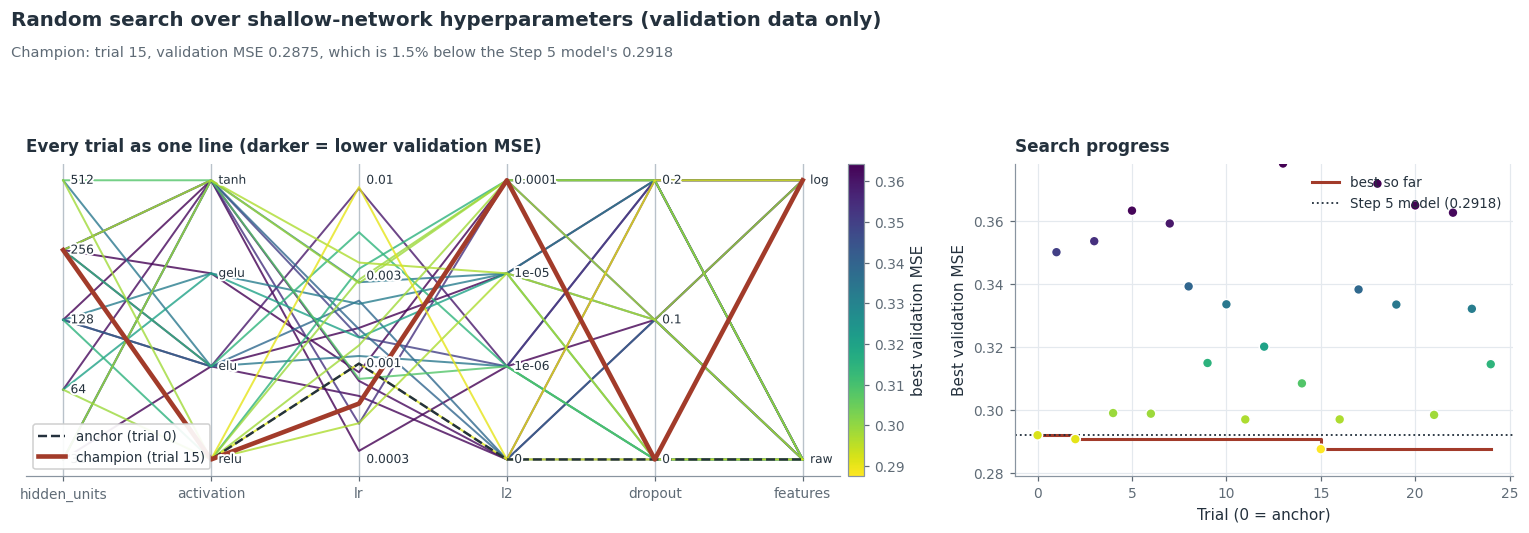

In [40]:
def encode_axes(df, cols):
    """Map each hyperparameter to [0, 1] for a parallel-coordinates plot."""
    enc, ticks = {}, {}
    for c in cols:
        if c == "lr":
            lo, hi = np.log10(SPACE["lr"][0]), np.log10(SPACE["lr"][1])
            enc[c] = (np.log10(df[c].astype(float)) - lo) / (hi - lo)
            ticks[c] = [((np.log10(t) - lo) / (hi - lo), f"{t:g}") for t in (3e-4, 1e-3, 3e-3, 1e-2)]
        else:
            levels = list(dict.fromkeys(list(SPACE[c]) + sorted(set(df[c]) - set(SPACE[c]), key=str)))
            pos = {lvl: k / max(len(levels) - 1, 1) for k, lvl in enumerate(levels)}
            enc[c] = df[c].map(pos)
            ticks[c] = [(pos[l], f"{l:g}" if isinstance(l, float) else str(l)) for l in levels]
    return pd.DataFrame(enc), ticks


enc, ticks = encode_axes(trials, HP_COLS)
score = trials["best val MSE"]
norm = mpl.colors.Normalize(vmin=score.min(), vmax=score.quantile(0.9))
cmap = mpl.colormaps["viridis_r"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.9), gridspec_kw={"width_ratios": [1.7, 1]})
ax = axes[0]
xs = np.arange(len(HP_COLS))
for t in score.sort_values(ascending=False).index:          # best trials drawn last, on top
    ax.plot(xs, enc.loc[t, HP_COLS].to_numpy(dtype=float), color=cmap(norm(score[t])), lw=1.3, alpha=0.8)
ax.plot(xs, enc.loc[0, HP_COLS].to_numpy(dtype=float), color=INK, lw=1.6, ls="--", label="anchor (trial 0)")
ax.plot(xs, enc.loc[CHAMP_TRIAL, HP_COLS].to_numpy(dtype=float), color=REDWOOD, lw=3, label=f"champion (trial {CHAMP_TRIAL})")
for k, c in enumerate(HP_COLS):
    ax.axvline(k, color="#B9C2CA", lw=0.9, zorder=0)
    for p, lab in ticks[c]:
        ax.text(k + 0.05, p, lab, fontsize=8, va="center", color=INK, path_effects=HALO)
ax.set_xticks(xs, HP_COLS)
ax.set_yticks([])
ax.set_ylim(-0.06, 1.06)
ax.grid(False)
ax.spines["left"].set_visible(False)
ax.legend(loc="lower left", frameon=True, framealpha=0.92)
ax.set_title("Every trial as one line (darker = lower validation MSE)")
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.03, pad=0.01, label="best validation MSE")

ax = axes[1]
ax.scatter(trials.index, score, color=[cmap(norm(v)) for v in score], s=42, edgecolor="white", zorder=3)
ax.step(trials.index, score.cummin(), where="post", color=REDWOOD, lw=2, label="best so far")
ax.axhline(FINAL_RES["best_val_loss"], color=INK, ls=":", lw=1.2, label=f"Step 5 model ({FINAL_RES['best_val_loss']:.4f})")
ax.set_ylim(score.min() * 0.97, min(score.max(), score.quantile(0.9) * 1.25))
ax.set_xlabel("Trial (0 = anchor)")
ax.set_ylabel("Best validation MSE")
ax.legend(loc="upper right")
ax.set_title("Search progress")
gain = 100 * (1 - champion["best_val_loss"] / FINAL_RES["best_val_loss"])
headline(fig, "Random search over shallow-network hyperparameters (validation data only)",
         f"Champion: trial {CHAMP_TRIAL}, validation MSE {champion['best_val_loss']:.4f}, which is {gain:.1f}% below "
         f"the Step 5 model's {FINAL_RES['best_val_loss']:.4f}")
plt.show()

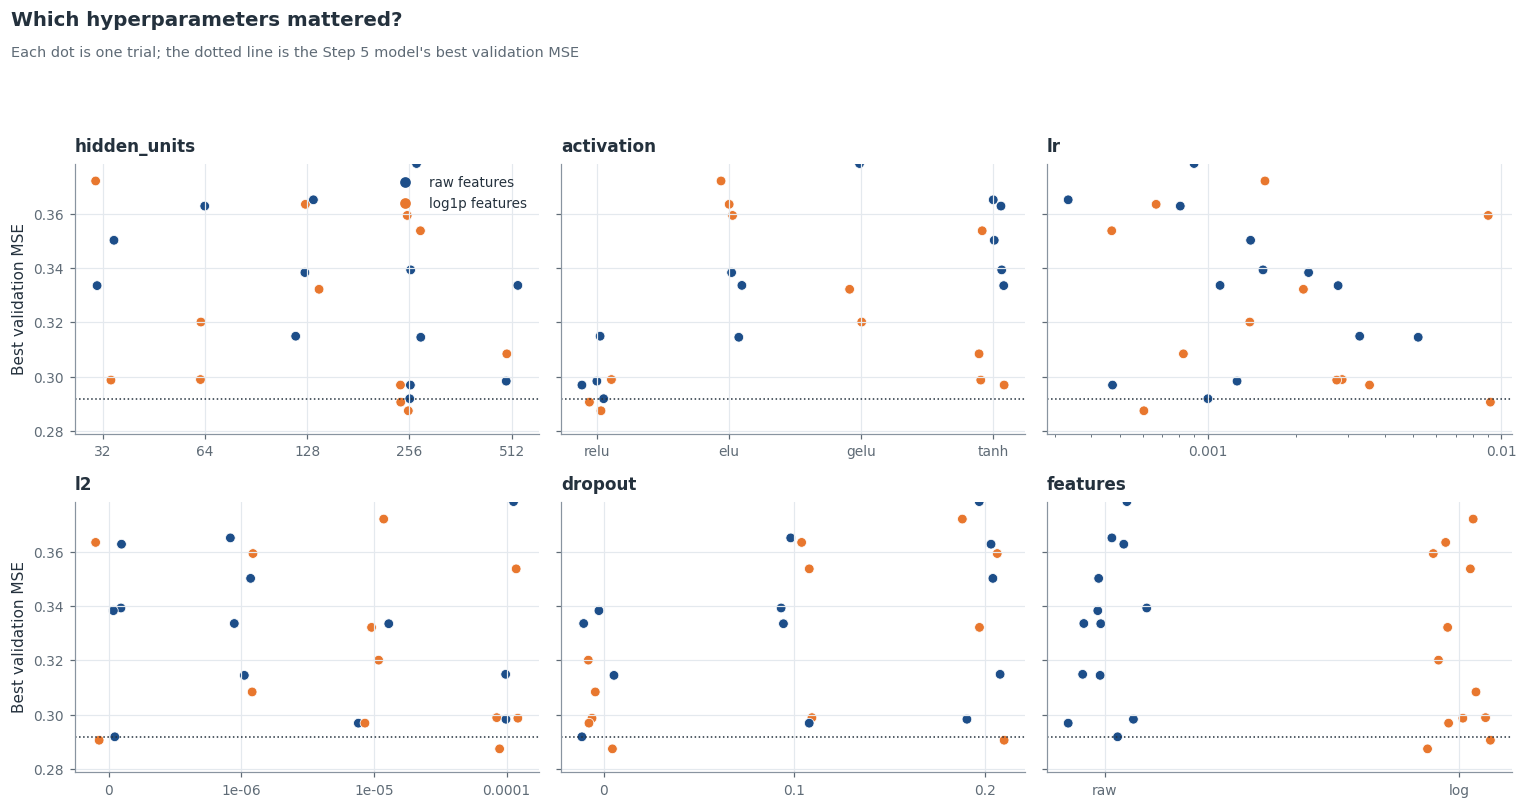

In [41]:
feat_c = {"raw": PACIFIC, "log": POPPY}
y_top = min(score.max(), score.quantile(0.9) * 1.25)
jit = np.random.default_rng(1)
fig, axes = plt.subplots(2, 3, figsize=(14, 7.4), sharey=True)
for ax, c in zip(axes.ravel(), HP_COLS):
    colors = trials["features"].map(feat_c).fillna(SUBTLE).tolist()
    if c == "lr":
        ax.scatter(trials["lr"], score, c=colors, s=40, edgecolor="white", linewidth=0.5)
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:g}"))
    else:
        n_lv = len(ticks[c])
        xpos = enc[c] * (n_lv - 1) + jit.uniform(-0.12, 0.12, len(trials))
        ax.scatter(xpos, score, c=colors, s=40, edgecolor="white", linewidth=0.5)
        ax.set_xticks([p * (n_lv - 1) for p, _ in ticks[c]], [lab for _, lab in ticks[c]])
    ax.axhline(FINAL_RES["best_val_loss"], color=INK, ls=":", lw=1)
    ax.set_ylim(score.min() * 0.97, y_top)
    ax.set_title(c)
for ax in axes[:, 0]:
    ax.set_ylabel("Best validation MSE")
axes[0, 0].legend(handles=[Line2D([], [], marker="o", ls="", color=PACIFIC, label="raw features"),
                           Line2D([], [], marker="o", ls="", color=POPPY, label="log1p features")], loc="upper right")
clipped = int((score > y_top).sum())
headline(fig, "Which hyperparameters mattered?",
         "Each dot is one trial; the dotted line is the Step 5 model's best validation MSE"
         + (f"; {clipped} poor trial(s) above the plotted range" if clipped else ""))
plt.show()

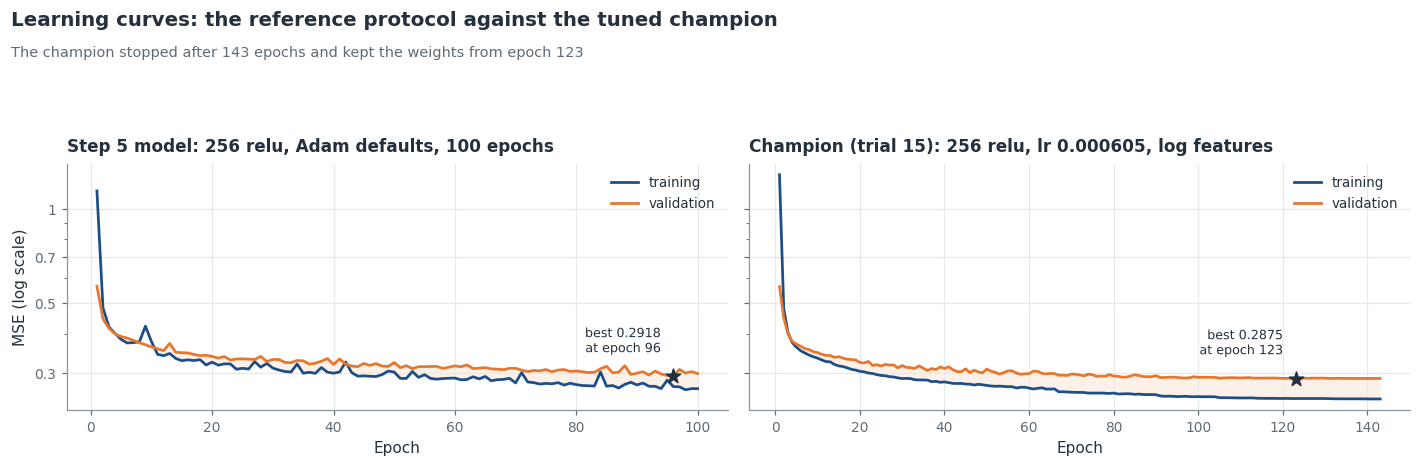

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
plot_curves(axes[0], FINAL_RES)
axes[0].set_title(f"Step 5 model: {CHOSEN_UNITS} {CHOSEN_ACT}, Adam defaults, {EPOCHS} epochs")
plot_curves(axes[1], champion)
axes[1].set_title(f"Champion (trial {CHAMP_TRIAL}): {champion['cfg']['hidden_units']} {champion['cfg']['activation']}, "
                  f"lr {champion['cfg']['lr']:g}, {champion['cfg']['features']} features")
for ax in axes:
    nice_log_y(ax)
    ax.legend(loc="upper right")
axes[0].set_ylabel("MSE (log scale)")
headline(fig, "Learning curves: the reference protocol against the tuned champion",
         f"The champion stopped after {champion['epochs_run']} epochs and kept the weights from epoch {champion['best_epoch']}")
plt.show()

### 5b.4 Validation scores in context

Two simple reference models and one strong one put the network's validation error in perspective. They are fitted on the training rows only. Like everything in this section, the comparison uses validation data; note that the two network scores are slightly optimistic, because each network was itself chosen for having a low validation loss (Cawley & Talbot, 2010).

In [43]:
ref_fitted = {
    "Mean predictor (ignores the features)": DummyRegressor(strategy="mean").fit(X_train_s, y_train),
    "Linear regression": LinearRegression().fit(X_train_s, y_train),
    "Gradient-boosted trees (HistGradientBoosting)": HistGradientBoostingRegressor(random_state=SEED).fit(X_train_s, y_train),
}
CORE_NAME = f"Shallow NN, reference protocol ({CHOSEN_UNITS} {CHOSEN_ACT})"
TUNED_NAME = f"Shallow NN, tuned (trial {CHAMP_TRIAL})"
val_rows = {CORE_NAME: scores(y_val, predict(restore_model(FINAL_RES), X_val_s)),
            TUNED_NAME: scores(y_val, predict(restore_model(champion), VAL_INPUTS[CHAMP_FEATURES]))}
val_rows.update({name: scores(y_val, est.predict(X_val_s)) for name, est in ref_fitted.items()})
val_comparison = pd.DataFrame(val_rows).T
val_comparison["MAE ($)"] = val_comparison["MAE"] * DOLLARS
display(val_comparison.round({"MSE": 4, "MAE": 4, "R2": 4, "MAE ($)": 0}))

,MSE,MAE,R2,MAE ($)
"Shallow NN, reference protocol (256 relu)",0.2918,0.3631,0.7760,36312.0
"Shallow NN, tuned (trial 15)",0.2875,0.3666,0.7794,36659.0
Mean predictor (ignores the features),1.3028,0.9006,-0.0000,90063.0
Linear regression,0.5409,0.5335,0.5848,53345.0
Gradient-boosted trees (HistGradientBoosting),0.2264,0.3143,0.8262,31432.0


### 5b.5 Interpretation of the search

The search found a better shallow network on validation data, but only by a small margin, and the gain did not carry over cleanly to every metric. The champion, trial 15, kept 256 ReLU units and added a log transform of the four heavy-tailed features, L2 weight decay of 10⁻⁴ and a lower learning rate (0.0006) under early stopping. It reached a validation MSE of 0.2875, 1.5% below the reference model's 0.2918, and re-training on three seeds confirmed it (mean 0.2867, standard error 0.0004). The gain is therefore not the product of a lucky seed (Cawley & Talbot, 2010).

Three patterns stand out across the 25 trials. First, ReLU dominated: its seven trials averaged 0.297, against 0.334 for tanh, 0.344 for GELU and 0.347 for ELU, so the smooth relatives of ReLU brought nothing here (Clevert et al., 2016; Hendrycks & Gimpel, 2016). Second, the log transform helped modestly. It lowered the mean trial score from 0.332 to 0.324 and supplied the best result, which supports the Step 1 suspicion that heavy tails hurt; it pulls the most extreme standardised value from 100 standard deviations to 27. Third, the training protocol on its own did not help. The anchor trial, the Step 5 configuration trained for 300 epochs with a learning-rate schedule, ended at 0.2919, the same as the 100-epoch run, so the 256-unit ReLU network on raw features had genuinely plateaued.

The reference models put this in perspective. On validation data, gradient-boosted trees reached an MSE of 0.226, well below every network, and linear regression only 0.541. The shallow network sits much closer to the trees than to the linear model, but it does not catch them (Grinsztajn et al., 2022). Tuning also worsened the validation MAE slightly (0.367 against 0.363) while improving the MSE, a reminder that optimising squared error is not the same as optimising typical error.

<a id="step6"></a>

## 6. Evaluate the final model

Every decision is now fixed: the hidden-layer size from Step 4, the activation from Step 5 and, for the extension, the tuned champion from 5b. Only now is the test set used.

**Which weights, and why.** I retained the model from its best validation epoch instead of retraining. The `BestEpochTracker` callback stored those weights during the seed-42 run of the selected configuration, so the epoch was chosen with validation data only and no further training is needed. This is early stopping with the stopping point read off the validation curve afterwards (Prechelt, 2012). Retraining the same configuration for that number of epochs, the other valid option, would reproduce exactly the same weights because the runs are deterministic, so it would add run time without adding information. The first cell below confirms that the restored weights reproduce the validation loss recorded during training.

**One evaluation.** The second cell evaluates the final model on the test set once. The cell after it evaluates, for context only, the tuned champion and the three reference models from 5b: a mean predictor, ordinary linear regression, and histogram-based gradient-boosted trees in the style of LightGBM (Ke et al., 2017), a model family that remains a strong benchmark on tabular data of this size (Grinsztajn et al., 2022). None of these numbers feeds back into any choice made above.

In [44]:
final_model = restore_model(FINAL_RES)
recheck = final_model.evaluate(X_val_s, y_val, verbose=0, return_dict=True)
print(f"Validation MSE recorded at epoch {FINAL_RES['best_epoch']} during training: {FINAL_RES['best_val_loss']:.6f}")
print(f"Validation MSE after restoring those weights            : {float(recheck.get('loss', np.nan)):.6f}")

Validation MSE recorded at epoch 96 during training: 0.291810
Validation MSE after restoring those weights            : 0.291810


In [45]:
# ---- The single evaluation of the final model on the held-out test set ----
test_eval = final_model.evaluate(X_test_s, y_test, verbose=0, return_dict=True)
y_pred_test = predict(final_model, X_test_s)

test_mse = float(test_eval.get("loss", np.mean((y_pred_test - y_test) ** 2)))
test_mae = float(test_eval.get("mae", np.mean(np.abs(y_pred_test - y_test))))
test_rmse = float(np.sqrt(test_mse))
test_r2 = float(r2_score(y_test, y_pred_test))

final_report = pd.Series({
    "Final model configuration": f"8 inputs -> {CHOSEN_UNITS} {CHOSEN_ACT} units -> 1 linear output; "
                                 f"Adam (Keras defaults), MSE loss, MAE metric, batch size {BATCH_SIZE}",
    "Weights used": f"epoch {FINAL_RES['best_epoch']} of {EPOCHS} (lowest validation loss, retained by the callback)",
    "Trainable parameters": f"{FINAL_RES['n_params']:,}",
    "Best validation loss (MSE)": f"{FINAL_RES['best_val_loss']:.4f}",
    "Test MSE": f"{test_mse:.4f}",
    "Test MAE": f"{test_mae:.4f}",
    "Test RMSE": f"{test_rmse:.4f}",
    "Test R squared": f"{test_r2:.4f}",
    "Number of training epochs": f"{FINAL_RES['best_epoch']} (the run continued to {EPOCHS}; later weights were discarded)",
    "Test MAE in dollars (MAE x $100,000)": f"${test_mae * DOLLARS:,.0f}",
    "Test RMSE in dollars": f"${test_rmse * DOLLARS:,.0f}",
}, name="Final model")
display(final_report.to_frame())
print(f"Check: MSE recomputed from the predictions = {np.mean((y_pred_test - y_test) ** 2):.6f}")

,Final model
Final model configuration,8 inputs -> 256 relu units -> 1 linear output;...
Weights used,"epoch 96 of 100 (lowest validation loss, retai..."
Trainable parameters,"2,561"
Best validation loss (MSE),0.2918
Test MSE,0.2629
Test MAE,0.3493
Test RMSE,0.5128
Test R squared,0.8012
Number of training epochs,96 (the run continued to 100; later weights we...
"Test MAE in dollars (MAE x $100,000)","$34,929"


Check: MSE recomputed from the predictions = 0.262931


In [46]:
cap_test = y_test >= TARGET_CAP


def group_stats(mask):
    err = y_pred_test[mask] - y_test[mask]
    return {"block groups": int(mask.sum()), "share of test set": float(mask.mean()),
            "MAE": float(np.mean(np.abs(err))), "MAE ($)": float(np.mean(np.abs(err)) * DOLLARS),
            "mean prediction": float(y_pred_test[mask].mean()), "mean signed error (pred - true)": float(err.mean())}


cap_table = pd.DataFrame({"at the $500k ceiling": group_stats(cap_test), "below the ceiling": group_stats(~cap_test)}).T
display(cap_table.round({"share of test set": 4, "MAE": 4, "MAE ($)": 0, "mean prediction": 3,
                         "mean signed error (pred - true)": 4}))
print(f"Predictions above the ceiling of 5.0: {(y_pred_test > TARGET_CAP).sum()} of {len(y_pred_test):,}")

,block groups,share of test set,MAE,MAE ($),mean prediction,mean signed error (pred - true)
at the $500k ceiling,141.0,0.0455,0.8332,83323.0,4.198,-0.8021
below the ceiling,2955.0,0.9545,0.3262,32620.0,1.947,0.0206


Predictions above the ceiling of 5.0: 12 of 3,096


In [47]:
champion_model = restore_model(champion)
y_pred_champ = predict(champion_model, TEST_INPUTS[CHAMP_FEATURES])
test_rows = {CORE_NAME + " [final model]": scores(y_test, y_pred_test),
             TUNED_NAME + " [extension]": scores(y_test, y_pred_champ)}
test_rows.update({name: scores(y_test, est.predict(X_test_s)) for name, est in ref_fitted.items()})
test_comparison = pd.DataFrame(test_rows).T
test_comparison["MAE ($)"] = test_comparison["MAE"] * DOLLARS
print("Context only: these scores were computed after every decision had been made.")
display(test_comparison.round({"MSE": 4, "MAE": 4, "R2": 4, "MAE ($)": 0}))

Context only: these scores were computed after every decision had been made.


,MSE,MAE,R2,MAE ($)
"Shallow NN, reference protocol (256 relu) [final model]",0.2629,0.3493,0.8012,34929.0
"Shallow NN, tuned (trial 15) [extension]",0.2570,0.3540,0.8057,35402.0
Mean predictor (ignores the features),1.3223,0.9118,-0.0000,91177.0
Linear regression,0.5203,0.5210,0.6066,52104.0
Gradient-boosted trees (HistGradientBoosting),0.2001,0.3032,0.8487,30324.0


### 6.1 The test error in dollars, and the \$500,000 ceiling

On the 3,096 test block groups the final model's MAE is 0.3493. In dollar terms, approximate dollar MAE = MAE × \$100,000 = 0.3493 × \$100,000 ≈ \$34,929, so on average a prediction misses the true median house value by about \$34,900. For scale, the median block group in the test set is worth about \$178,000, so a typical miss is around a fifth of a typical value. The RMSE is \$51,277 and R² is 0.801: the network explains about four-fifths of the variation in median house values. RMSE is 1.47 times the MAE, a sign that a minority of large misses carries much of the squared error. 78% of predictions are within \$50,000 of the true value and 94% within \$100,000.

The test error is lower than the validation error (MSE 0.263 against 0.292, MAE \$34,929 against \$36,312). Selection bias predicts the opposite, because the validation score belongs to the configuration that won on validation data (Cawley & Talbot, 2010). The likeliest explanation is ordinary sampling variation between two samples of 3,096 block groups. The validation MSE lies just outside the test set's bootstrap interval reported in 6c, an RMSE of 0.489 to 0.537, that is, an MSE of about 0.239 to 0.289. Section 6c tests this explanation with cross-validation.

The \$500,000 ceiling distorts these numbers in a specific way. 141 test block groups, 4.6% of the test set, sit at the cap. For them the MAE is \$83,323, two and a half times the \$32,620 of the rest, and the model under-predicts them by \$80,212 on average, with a mean prediction of about \$420,000. Because the true value of a capped block group is only known to be at least \$500,000, these errors are lower bounds: the real shortfall for an expensive neighbourhood is probably larger, and the headline MAE understates how poorly the model handles the top of the market (Tobin, 1958). The cap also limits what the model can learn. It has never seen a recorded value above \$500,000, yet 12 of its test predictions exceed the cap, and no recorded value can confirm or refute them. The fair reading is that the model is a reasonable guide to the middle of the market and a weak one at the top.

<a id="ext-b"></a>

## 6b. Extension: where and why the final model errs

These diagnostics use the test predictions from Step 6. They come after every decision has been made, so they describe the final model without influencing it. Residuals are defined as *predicted minus true*, so a positive residual is an over-prediction.

- **Permutation importance** shuffles one feature at a time in the test set and records how much the test MSE rises; a large rise means the model leans on that feature (Breiman, 2001; Fisher et al., 2019). Shuffling one of two correlated features, such as Latitude and Longitude, creates combinations that never occur in reality, so these scores describe the model's reliance on a feature, not a causal effect.
- **Partial dependence** sweeps one feature across its observed range while every other feature keeps its real values, and averages the predictions (Friedman, 2001). The thin lines are individual block groups; they show whether the average hides different patterns.
- **The learned location surface** asks the network what a block group with typical characteristics (the training medians) would be worth at each point in California. Grid cells far from any training block group are left blank, because predictions there would be extrapolations.

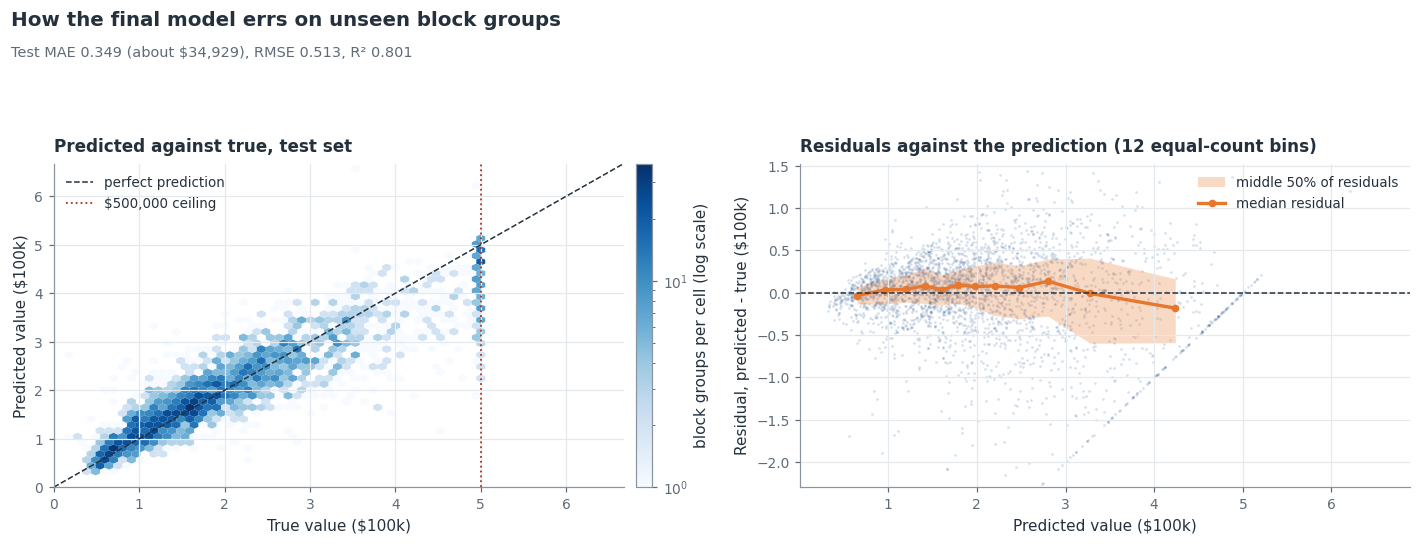

In [48]:
resid = y_pred_test - y_test
abs_err = np.abs(resid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
ax = axes[0]
hi = max(5.4, float(y_pred_test.max()) + 0.1)
hb = ax.hexbin(y_test, y_pred_test, gridsize=46, cmap="Blues", mincnt=1, bins="log", linewidths=0)
ax.plot([0, hi], [0, hi], color=INK, lw=1, ls="--", label="perfect prediction")
ax.axvline(TARGET_CAP, color=REDWOOD, lw=1.2, ls=":", label=f"{usd_plot(500_000)} ceiling")
ax.set_xlim(0, hi)
ax.set_ylim(min(0.0, float(y_pred_test.min()) - 0.1), hi)
ax.set_xlabel("True value (\\$100k)")
ax.set_ylabel("Predicted value (\\$100k)")
ax.legend(loc="upper left")
ax.set_title("Predicted against true, test set")
fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.02, label="block groups per cell (log scale)")

ax = axes[1]
edges = np.quantile(y_pred_test, np.linspace(0, 1, 13))
which = np.clip(np.digitize(y_pred_test, edges[1:-1]), 0, 11)
bins_used = [k for k in range(12) if np.any(which == k)]
centers = np.array([y_pred_test[which == k].mean() for k in bins_used])
groups = [resid[which == k] for k in bins_used]
ax.scatter(y_pred_test, resid, s=3, alpha=0.18, color=PACIFIC, linewidths=0)
ax.fill_between(centers, [np.quantile(g, 0.25) for g in groups], [np.quantile(g, 0.75) for g in groups],
                color=POPPY, alpha=0.28, lw=0, label="middle 50% of residuals")
ax.plot(centers, [np.median(g) for g in groups], color=POPPY, lw=2.2, marker="o", ms=4, label="median residual")
ax.axhline(0, color=INK, lw=1, ls="--")
ax.set_ylim(*np.quantile(resid, [0.003, 0.997]))
ax.set_xlabel("Predicted value (\\$100k)")
ax.set_ylabel("Residual, predicted - true (\\$100k)")
ax.legend(loc="upper right")
ax.set_title("Residuals against the prediction (12 equal-count bins)")
headline(fig, "How the final model errs on unseen block groups",
         f"Test MAE {test_mae:.3f} (about {usd_plot(test_mae * DOLLARS)}), RMSE {test_rmse:.3f}, R² {test_r2:.3f}")
plt.show()

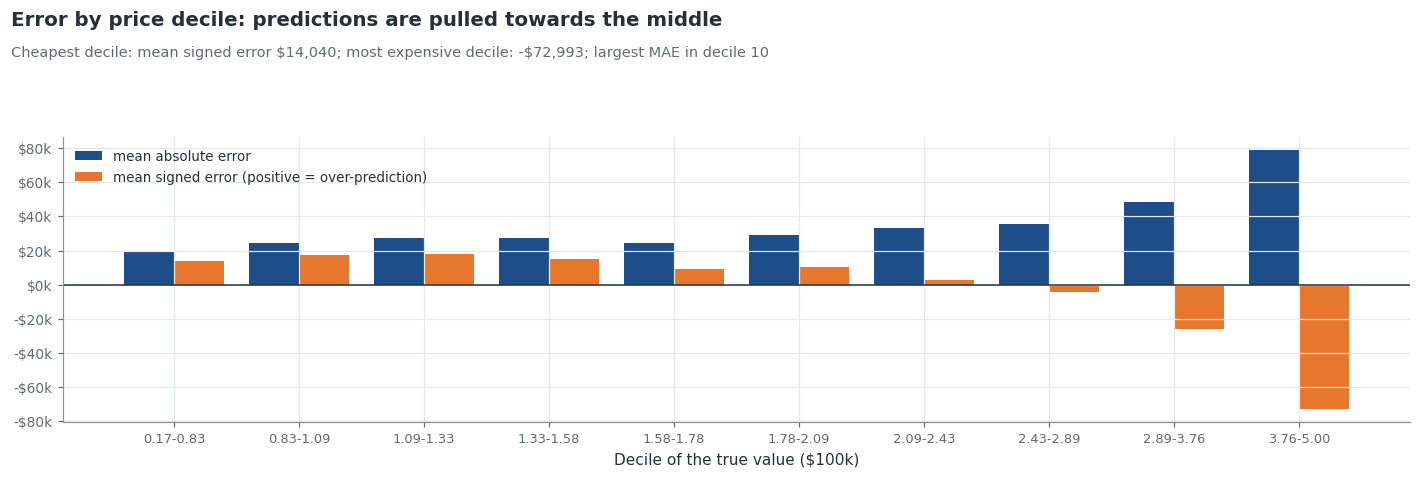

,true value range,n,MAE ($),mean signed error ($)
decile,,,,
0,0.17-0.83,310,19729.0,14040.0
1,0.83-1.09,308,24532.0,17292.0
2,1.09-1.33,311,27544.0,17767.0
3,1.33-1.58,307,27281.0,14792.0
4,1.58-1.78,312,24564.0,9118.0
5,1.78-2.09,310,29295.0,10551.0
6,2.09-2.43,309,33404.0,3021.0
7,2.43-2.89,309,35401.0,-4305.0
8,2.89-3.76,309,48638.0,-25831.0


In [49]:
dec_edges = np.quantile(y_test, np.linspace(0, 1, 11))
dec = np.clip(np.digitize(y_test, dec_edges[1:-1]), 0, 9)
dec_df = (pd.DataFrame({"decile": dec, "abs_err": abs_err, "resid": resid})
          .groupby("decile").agg(mae=("abs_err", "mean"), bias=("resid", "mean"), n=("abs_err", "size")))
dec_df["true value range"] = [f"{dec_edges[k]:.2f}-{dec_edges[k + 1]:.2f}" for k in dec_df.index]

fig, ax = plt.subplots(figsize=(13, 4.4))
xd = np.arange(len(dec_df))
ax.bar(xd - 0.2, dec_df["mae"] * DOLLARS, width=0.4, color=PACIFIC, label="mean absolute error")
ax.bar(xd + 0.2, dec_df["bias"] * DOLLARS, width=0.4, color=POPPY, label="mean signed error (positive = over-prediction)")
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(xd, dec_df["true value range"], fontsize=8.5)
ax.set_xlabel("Decile of the true value (\\$100k)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: usd_plot(v / 1000) + "k"))
ax.legend(loc="upper left")
pulls = dec_df["bias"].iloc[0] > 0 and dec_df["bias"].iloc[-1] < 0
headline(fig, "Error by price decile: predictions are pulled towards the middle" if pulls else "Error by price decile",
         f"Cheapest decile: mean signed error {usd_plot(dec_df['bias'].iloc[0] * DOLLARS)}; most expensive decile: "
         f"{usd_plot(dec_df['bias'].iloc[-1] * DOLLARS)}; largest MAE in decile {int(dec_df['mae'].idxmax()) + 1}")
plt.show()
display(dec_df.assign(**{"MAE ($)": dec_df["mae"] * DOLLARS, "mean signed error ($)": dec_df["bias"] * DOLLARS})
        [["true value range", "n", "MAE ($)", "mean signed error ($)"]].round(0))

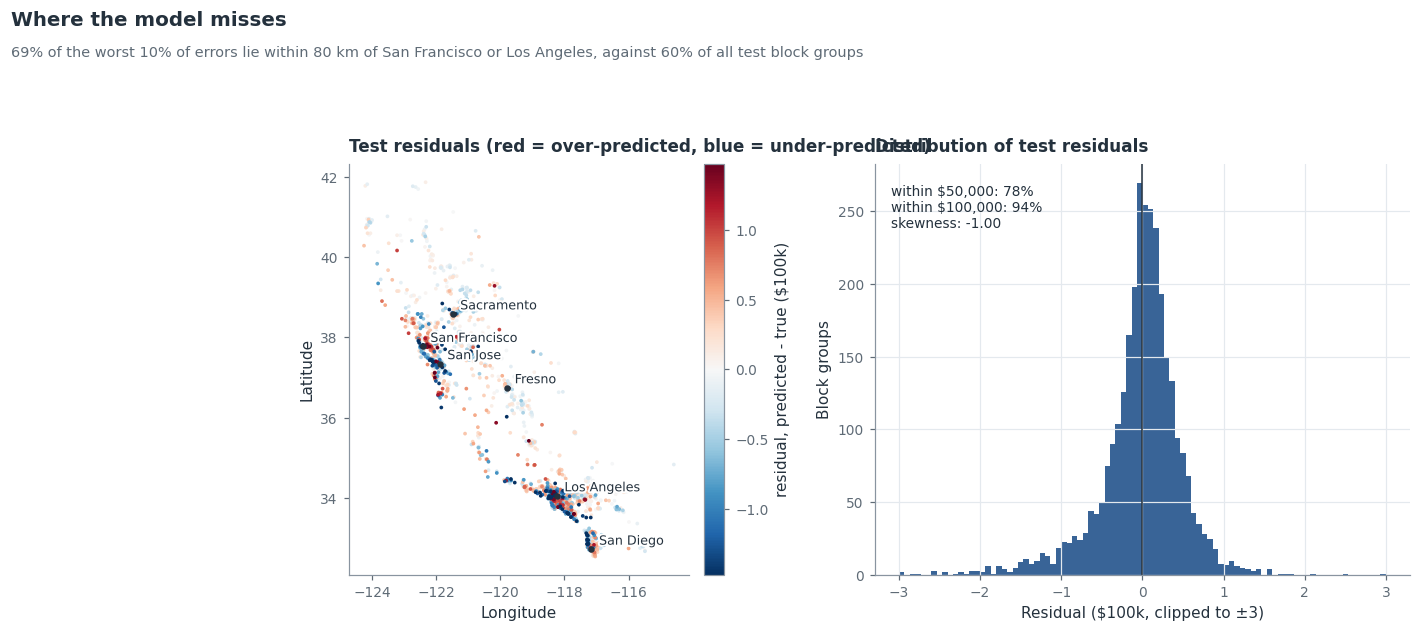

In [50]:
lat_t, lon_t = X_test[:, FEATURES.index("Latitude")], X_test[:, FEATURES.index("Longitude")]


def near_metro_mask(lat_arr, lon_arr, km=80):
    mask = np.zeros(len(lat_arr), dtype=bool)
    for city in ("San Francisco", "Los Angeles"):
        clat, clon = CITIES[city]
        dx = (lon_arr - clon) * 111.0 * np.cos(np.deg2rad(clat))
        mask |= np.hypot(dx, (lat_arr - clat) * 111.0) <= km
    return mask


near_t = near_metro_mask(lat_t, lon_t)
worst10 = abs_err >= np.quantile(abs_err, 0.9)
lim_r = float(np.quantile(abs_err, 0.98))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
order_e = np.argsort(abs_err)
sc = ax.scatter(lon_t[order_e], lat_t[order_e], c=resid[order_e], cmap="RdBu_r",
                norm=TwoSlopeNorm(vmin=-lim_r, vcenter=0.0, vmax=lim_r), s=6, linewidths=0)
fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02, label="residual, predicted - true (\\$100k)")
geo_axes(ax)
ax.set_title("Test residuals (red = over-predicted, blue = under-predicted)")
ax = axes[1]
ax.hist(np.clip(resid, -3, 3), bins=90, color=PACIFIC, alpha=0.88)
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel("Residual (\\$100k, clipped to ±3)")
ax.set_ylabel("Block groups")
ax.set_title("Distribution of test residuals")
ax.text(0.03, 0.95, f"within {usd_plot(50_000)}: {np.mean(abs_err <= 0.5):.0%}\n"
                    f"within {usd_plot(100_000)}: {np.mean(abs_err <= 1.0):.0%}\n"
                    f"skewness: {stats.skew(resid):.2f}", transform=ax.transAxes, va="top", fontsize=9)
headline(fig, "Where the model misses",
         f"{near_t[worst10].mean():.0%} of the worst 10% of errors lie within 80 km of San Francisco or Los Angeles, "
         f"against {near_t.mean():.0%} of all test block groups")
plt.show()

In [51]:
z_abs = np.abs(X_test_s)
top_err = np.argsort(-abs_err)[:10]
largest = pd.DataFrame(X_test[top_err], columns=FEATURES)
largest.insert(0, "row id", idx_test[top_err])
largest["true"] = y_test[top_err]
largest["predicted"] = y_pred_test[top_err]
largest["residual"] = resid[top_err]
largest["most extreme input"] = [f"{FEATURES[int(z_abs[i].argmax())]} (|z| = {z_abs[i].max():.1f})" for i in top_err]
print("The ten largest test errors:")
display(largest.round(3))
print(f"{np.mean([z_abs[i].max() > 5 for i in top_err]):.0%} of these ten involve an input more than "
      f"5 standard deviations from the training mean; {np.mean(cap_test[top_err]):.0%} are capped block groups.")

The ten largest test errors:


,row id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,true,predicted,residual,most extreme input
0,19542,1.768,39.0,5.000,0.889,22.0,2.444,37.63,-120.92,4.500,1.186,-3.314,Population (|z| = 1.2)
1,17235,4.976,35.0,7.050,1.102,1995.0,5.209,34.47,-119.67,5.000,1.891,-3.109,AveRooms (|z| = 0.7)
2,1566,15.000,2.0,22.222,2.222,25.0,2.778,37.74,-121.96,3.500,6.575,3.075,AveRooms (|z| = 6.8)
3,17306,2.728,17.0,5.574,1.051,681.0,1.946,34.38,-119.55,5.000,2.179,-2.821,HouseAge (|z| = 0.9)
4,12069,4.239,6.0,7.723,1.169,228.0,3.508,33.83,-117.55,5.000,2.227,-2.773,HouseAge (|z| = 1.8)
5,9421,3.750,38.0,5.771,0.956,628.0,3.063,37.86,-122.53,4.786,2.213,-2.573,Longitude (|z| = 1.5)
6,5354,3.728,33.0,4.766,1.063,994.0,2.738,34.03,-118.41,5.000,2.448,-2.552,Latitude (|z| = 0.8)
7,12213,6.993,13.0,6.429,1.000,120.0,2.857,33.51,-117.18,5.000,2.455,-2.545,MedInc (|z| = 1.6)
8,5887,2.367,39.0,3.572,1.217,259.0,1.877,34.15,-118.33,0.175,2.660,2.485,Population (|z| = 1.0)
9,13015,3.232,11.0,7.041,1.153,1520.0,2.424,38.71,-121.19,3.908,1.500,-2.408,Latitude (|z| = 1.4)


10% of these ten involve an input more than 5 standard deviations from the training mean; 50% are capped block groups.


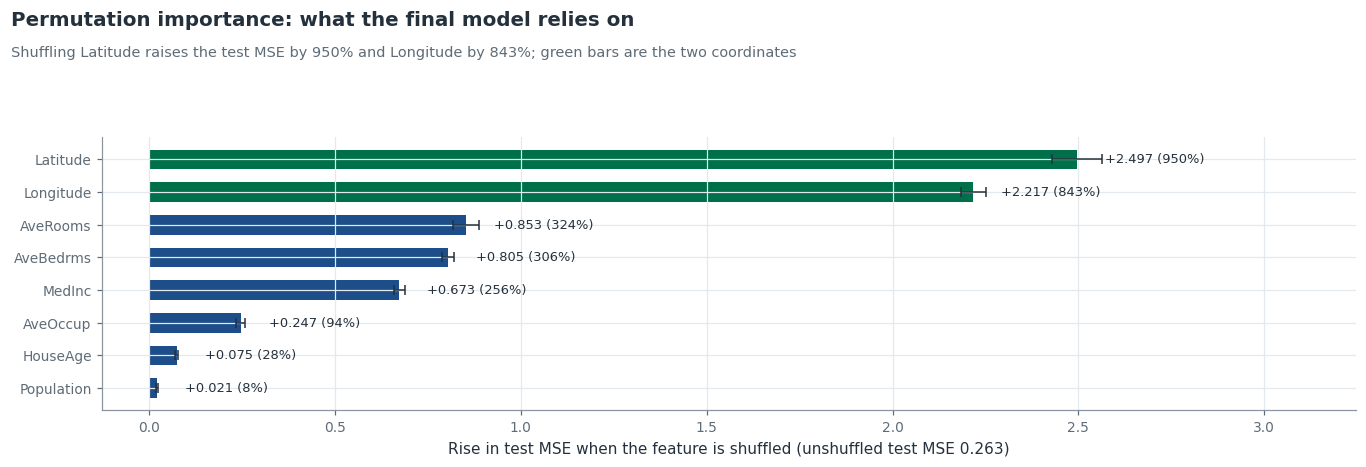

,mean rise in test MSE,SD over 10 shuffles,rise as % of test MSE
Latitude,2.4968,0.0676,949.6188
Longitude,2.2173,0.0336,843.3179
AveRooms,0.8531,0.0360,324.4541
AveBedrms,0.8046,0.0173,306.0284
MedInc,0.6734,0.0146,256.1025
AveOccup,0.2472,0.0121,94.0072
HouseAge,0.0749,0.0045,28.4813
Population,0.0213,0.0026,8.1089


In [52]:
def permutation_importance_mse(model, X, y, n_repeats=10, seed=SEED):
    rng = np.random.default_rng(seed)
    base = float(np.mean((predict(model, X) - y) ** 2))
    deltas = np.zeros((X.shape[1], n_repeats))
    for j in range(X.shape[1]):
        for r in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])
            deltas[j, r] = float(np.mean((predict(model, X_perm) - y) ** 2)) - base
    return base, deltas


base_mse, perm = permutation_importance_mse(final_model, X_test_s, y_test)
imp = pd.DataFrame({"mean rise in test MSE": perm.mean(axis=1), "SD over 10 shuffles": perm.std(axis=1, ddof=1)},
                   index=FEATURES).sort_values("mean rise in test MSE")
imp["rise as % of test MSE"] = 100 * imp["mean rise in test MSE"] / base_mse

fig, ax = plt.subplots(figsize=(12.5, 4.3))
ax.barh(imp.index, imp["mean rise in test MSE"], xerr=imp["SD over 10 shuffles"], height=0.6, capsize=3,
        color=[HIGHWAY if f in ("Latitude", "Longitude") else PACIFIC for f in imp.index], error_kw=dict(ecolor=INK, lw=1))
span = imp["mean rise in test MSE"].abs().max()
for i, (v, pct) in enumerate(zip(imp["mean rise in test MSE"], imp["rise as % of test MSE"])):
    ax.text(max(v, 0) + span * 0.03, i, f"{v:+.3f} ({pct:.0f}%)", va="center", fontsize=8.5)
ax.set_xlim(min(0, imp["mean rise in test MSE"].min()) - span * 0.05, span * 1.3)
ax.set_xlabel(f"Rise in test MSE when the feature is shuffled (unshuffled test MSE {base_mse:.3f})")
top2 = list(imp.index[::-1][:2])
headline(fig, "Permutation importance: what the final model relies on",
         f"Shuffling {top2[0]} raises the test MSE by {imp.loc[top2[0], 'rise as % of test MSE']:.0f}% and {top2[1]} by "
         f"{imp.loc[top2[1], 'rise as % of test MSE']:.0f}%; green bars are the two coordinates")
plt.show()
display(imp.iloc[::-1].round(4))

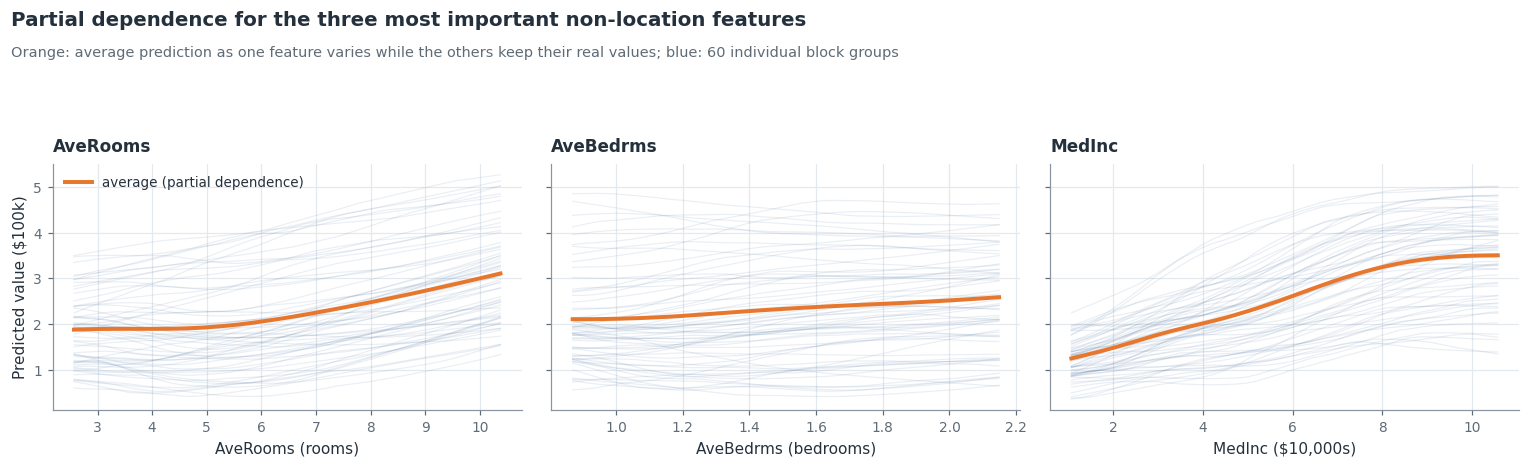

In [53]:
pd_features = [f for f in imp.index[::-1] if f not in ("Latitude", "Longitude")][:3]
rows_pd = np.random.default_rng(SEED).choice(len(X_test), size=min(400, len(X_test)), replace=False)
base_raw = X_test[rows_pd].astype(np.float64)

fig, axes = plt.subplots(1, len(pd_features), figsize=(14, 4.3), sharey=True)
axes = np.atleast_1d(axes)
for ax, f in zip(axes, pd_features):
    j = FEATURES.index(f)
    grid = np.linspace(np.quantile(X_train[:, j], 0.01), np.quantile(X_train[:, j], 0.99), 40)
    stacked = np.repeat(base_raw[None, :, :], len(grid), axis=0)        # (grid point, block group, feature)
    stacked[:, :, j] = grid[:, None]
    preds = predict(final_model, scaler.transform(stacked.reshape(-1, len(FEATURES))).astype(np.float32))
    preds = preds.reshape(len(grid), -1)
    for r in range(min(60, preds.shape[1])):
        ax.plot(grid, preds[:, r], color=PACIFIC, alpha=0.09, lw=0.8)
    ax.plot(grid, preds.mean(axis=1), color=POPPY, lw=2.6, label="average (partial dependence)")
    ax.set_xlabel(f"{f} ({FEATURE_INFO[f][1]})".replace("$", "\\$"))
    ax.set_title(f)
axes[0].set_ylabel("Predicted value (\\$100k)")
axes[0].legend(loc="upper left")
headline(fig, "Partial dependence for the three most important non-location features",
         "Orange: average prediction as one feature varies while the others keep their real values; "
         "blue: 60 individual block groups")
plt.show()

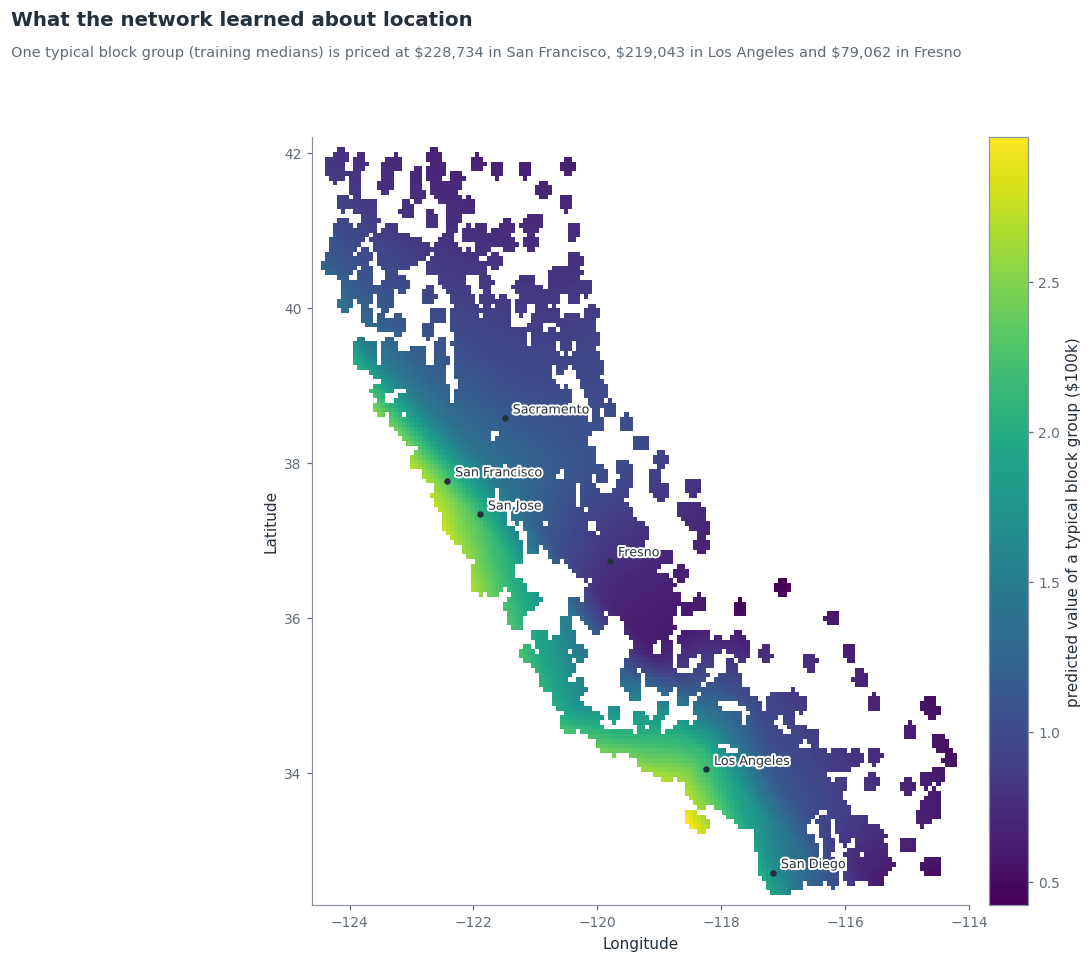

In [54]:
lat_g, lon_g = np.linspace(32.4, 42.1, 160), np.linspace(-124.5, -114.1, 160)
LON, LAT = np.meshgrid(lon_g, lat_g)
i_lat, i_lon = FEATURES.index("Latitude"), FEATURES.index("Longitude")
typical = np.median(X_train, axis=0).astype(np.float64)
grid_X = np.tile(typical, (LON.size, 1))
grid_X[:, i_lat], grid_X[:, i_lon] = LAT.ravel(), LON.ravel()
surface = predict(final_model, scaler.transform(grid_X).astype(np.float32)).reshape(LAT.shape)
dist, _ = cKDTree(np.c_[X_train[:, i_lon], X_train[:, i_lat]]).query(np.c_[LON.ravel(), LAT.ravel()])
surface_masked = np.ma.masked_where(dist.reshape(LAT.shape) > 0.12, surface)


def surface_at(lat0, lon0):
    return float(surface[np.abs(lat_g - lat0).argmin(), np.abs(lon_g - lon0).argmin()])


sf_v, la_v, fr_v = (surface_at(*CITIES[c]) for c in ("San Francisco", "Los Angeles", "Fresno"))
fig, ax = plt.subplots(figsize=(10, 8.8))
mesh = ax.pcolormesh(LON, LAT, surface_masked, cmap="viridis", shading="auto")
fig.colorbar(mesh, ax=ax, fraction=0.04, pad=0.02, label="predicted value of a typical block group (\\$100k)")
geo_axes(ax)
ax.set_xlim(-124.6, -114.0)
ax.set_ylim(32.3, 42.2)
headline(fig, "What the network learned about location",
         f"One typical block group (training medians) is priced at {usd_plot(sf_v * DOLLARS)} in San Francisco, "
         f"{usd_plot(la_v * DOLLARS)} in Los Angeles and {usd_plot(fr_v * DOLLARS)} in Fresno")
plt.show()

### 6b.1 What the diagnostics show

The diagnostics show that the errors are structured rather than random, and most of the structure points to two causes: price level and location.

**Price level.** The residual plot bends: cheap block groups are over-predicted and expensive ones under-predicted, the familiar pull towards the middle of a model trained on squared error. In the cheapest tenth of the test set the model over-predicts by \$14,040 on average. In the most expensive tenth it under-predicts by \$72,993, and the MAE there is \$78,753, four times the \$19,729 of the cheapest tenth. Part of the top-decile error comes from the ceiling. Half of the ten largest errors are capped block groups, and eight of the ten are under-predictions of expensive places. The residuals also have a long left tail (skewness −1.0).

**Location.** The worst 10% of errors are over-represented near San Francisco and Los Angeles: 69% of them lie within 80 km of either city, against 60% of all test block groups. The largest misses are expensive pockets such as the Santa Barbara coast, southern Marin County and the Westside of Los Angeles, which the network prices closer to their region's average than to their true value. Extreme inputs, which Step 1 flagged as a risk, turned out to matter little: only one of the ten largest errors involves an input more than 5 standard deviations from the training mean.

**What the model relies on.** Shuffling Latitude raised the test MSE by 950% and Longitude by 843%, far ahead of AveRooms (324%), AveBedrms (306%) and MedInc (256%). Two cautions apply (Fisher et al., 2019). First, the coordinates and the two room counts come in correlated pairs, so shuffling one member creates impossible combinations, such as a point in the ocean or more bedrooms than rooms, and that inflates both scores. Second, importance measures reliance, not causation, and income's lower rank does not mean income matters little. Its partial-dependence curve rises steadily, from roughly \$135,000 at a median household income of \$15,000 to roughly \$345,000 at \$100,000, flattening at the top (Friedman, 2001). The learned location surface shows the coastal premium directly. The same typical block group is priced at \$228,734 in San Francisco and \$219,043 in Los Angeles but only \$79,062 in Fresno, a factor of almost three for location alone.

<a id="ext-c"></a>

## 6c. Extension: stronger testing of the final model

A single test score is one draw from a noisy process. It depends on which 3,096 block groups happened to land in the test set, and a random split hides how the model would cope with places it has never seen. This section adds six tests. None of them changes the final model, and those that use the test set work only with the predictions already made in Step 6.

| Test | Question it answers | Data used |
|---|---|---|
| Bootstrap confidence intervals | How much would the test MAE, RMSE and R² move with a different, equally plausible test sample? | test predictions from Step 6 |
| Paired bootstrap comparisons | Does the final model really beat, or lose to, each alternative on these block groups? | test predictions from Step 6 |
| Random 5-fold cross-validation | Was the single 70/15/15 split lucky or unlucky? | training and validation rows only |
| Spatial block cross-validation | How well does the network price regions it has never seen? | training and validation rows only |
| Slice tests | Where, and for which kinds of block group, is the model weakest? | test predictions from Step 6 |
| Conformal prediction intervals | How wide must an interval be to contain the true value with a chosen probability, and does that promise hold? | validation residuals, checked on the test predictions |

**Bootstrap.** Resampling the test rows with replacement 2,000 times approximates the sampling distribution of each metric, and the 2.5th and 97.5th percentiles give a 95% interval (Efron & Tibshirani, 1993). Every model is scored on the same resamples, so the difference between two models gets its own paired interval. If that interval excludes zero, the gap is unlikely to be an accident of this particular test sample.

**Cross-validation.** The final configuration (the size and activation chosen in Steps 4 and 5, the reference compile settings and the number of epochs fixed in Step 6) is retrained once per fold on the development rows, meaning the training and validation sets combined (Kohavi, 1995). Each fold refits the scaler on its own training rows, so no fold sees statistics from the rows it is tested on. Random folds mix neighbouring block groups across the train/test boundary. Spatial folds first group the block groups into 25 compact regions with k-means on their coordinates (Lloyd, 1982) and then hold out whole regions, so every held-out fold lies in territory the model has not seen. The gap between the two estimates measures how optimistic a random split is when the data are spatially autocorrelated (Roberts et al., 2017).

### 6c.1 Bootstrap intervals and paired comparisons

In [55]:
N_BOOT = 300 if QUICK_MODE else 2000
test_preds = {
    "Final model": y_pred_test,
    "Tuned champion": y_pred_champ,
    "Linear regression": ref_fitted["Linear regression"].predict(X_test_s),
    "Gradient-boosted trees": ref_fitted["Gradient-boosted trees (HistGradientBoosting)"].predict(X_test_s),
}


def bootstrap_metrics(y, preds, n_boot=N_BOOT, seed=SEED, chunk=250):
    """Percentile bootstrap over test rows; every model is scored on the same resamples (paired)."""
    rng = np.random.default_rng(seed)
    draws = {name: {"MAE": [], "RMSE": [], "R2": []} for name in preds}
    done = 0
    while done < n_boot:
        b = min(chunk, n_boot - done)
        idx = rng.integers(0, len(y), size=(b, len(y)))
        yb = y[idx]
        sst = ((yb - yb.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)
        for name, p in preds.items():
            eb = np.asarray(p)[idx] - yb
            draws[name]["MAE"].append(np.abs(eb).mean(axis=1))
            draws[name]["RMSE"].append(np.sqrt((eb ** 2).mean(axis=1)))
            draws[name]["R2"].append(1 - (eb ** 2).sum(axis=1) / sst)
        done += b
    return {name: {k: np.concatenate(v) for k, v in d.items()} for name, d in draws.items()}


boot = bootstrap_metrics(y_test, test_preds)
point = {name: {"MAE": mean_absolute_error(y_test, p), "RMSE": float(np.sqrt(mean_squared_error(y_test, p))),
                "R2": r2_score(y_test, p)} for name, p in test_preds.items()}
boot_rows = []
for name in test_preds:
    row = {"model": name}
    for metric in ("MAE", "RMSE", "R2"):
        lo, hi = np.percentile(boot[name][metric], [2.5, 97.5])
        row[metric], row[f"{metric} low"], row[f"{metric} high"] = point[name][metric], lo, hi
    boot_rows.append(row)
boot_summary = pd.DataFrame(boot_rows).set_index("model")
display(pd.DataFrame({
    "MAE (95% CI)": [f"${r['MAE'] * DOLLARS:,.0f} (${r['MAE low'] * DOLLARS:,.0f} to ${r['MAE high'] * DOLLARS:,.0f})"
                     for _, r in boot_summary.iterrows()],
    "RMSE (95% CI)": [f"${r['RMSE'] * DOLLARS:,.0f} (${r['RMSE low'] * DOLLARS:,.0f} to ${r['RMSE high'] * DOLLARS:,.0f})"
                      for _, r in boot_summary.iterrows()],
    "R squared (95% CI)": [f"{r['R2']:.3f} ({r['R2 low']:.3f} to {r['R2 high']:.3f})" for _, r in boot_summary.iterrows()],
}, index=boot_summary.index))

paired_rows = []
for name in test_preds:
    if name == "Final model":
        continue
    d = boot["Final model"]["MAE"] - boot[name]["MAE"]
    lo, hi = np.percentile(d, [2.5, 97.5])
    share = float(np.mean(d > 0))
    paired_rows.append({"comparison": f"Final model vs {name}",
                        "MAE difference ($)": (point["Final model"]["MAE"] - point[name]["MAE"]) * DOLLARS,
                        "95% CI low ($)": lo * DOLLARS, "95% CI high ($)": hi * DOLLARS,
                        "two-sided bootstrap p": max(2 * min(share, 1 - share), 1 / N_BOOT),
                        "verdict": "final model better" if hi < 0 else ("final model worse" if lo > 0 else "no clear difference")})
paired_table = pd.DataFrame(paired_rows).set_index("comparison")
display(paired_table.round({"MAE difference ($)": 0, "95% CI low ($)": 0, "95% CI high ($)": 0, "two-sided bootstrap p": 4}))

,MAE (95% CI),RMSE (95% CI),R squared (95% CI)
model,,,
Final model,"$34,929 ($33,614 to $36,319)","$51,277 ($48,930 to $53,736)",0.801 (0.782 to 0.818)
Tuned champion,"$35,402 ($34,140 to $36,721)","$50,692 ($48,554 to $52,917)",0.806 (0.788 to 0.821)
Linear regression,"$52,104 ($50,363 to $53,919)","$72,129 ($67,906 to $77,602)",0.607 (0.548 to 0.647)
Gradient-boosted trees,"$30,324 ($29,167 to $31,513)","$44,731 ($42,651 to $46,877)",0.849 (0.833 to 0.862)


,MAE difference ($),95% CI low ($),95% CI high ($),two-sided bootstrap p,verdict
comparison,,,,,
Final model vs Tuned champion,-473.0,-932.0,-19.0,0.0420,final model better
Final model vs Linear regression,-17175.0,-18521.0,-15822.0,0.0005,final model better
Final model vs Gradient-boosted trees,4605.0,3797.0,5415.0,0.0005,final model worse


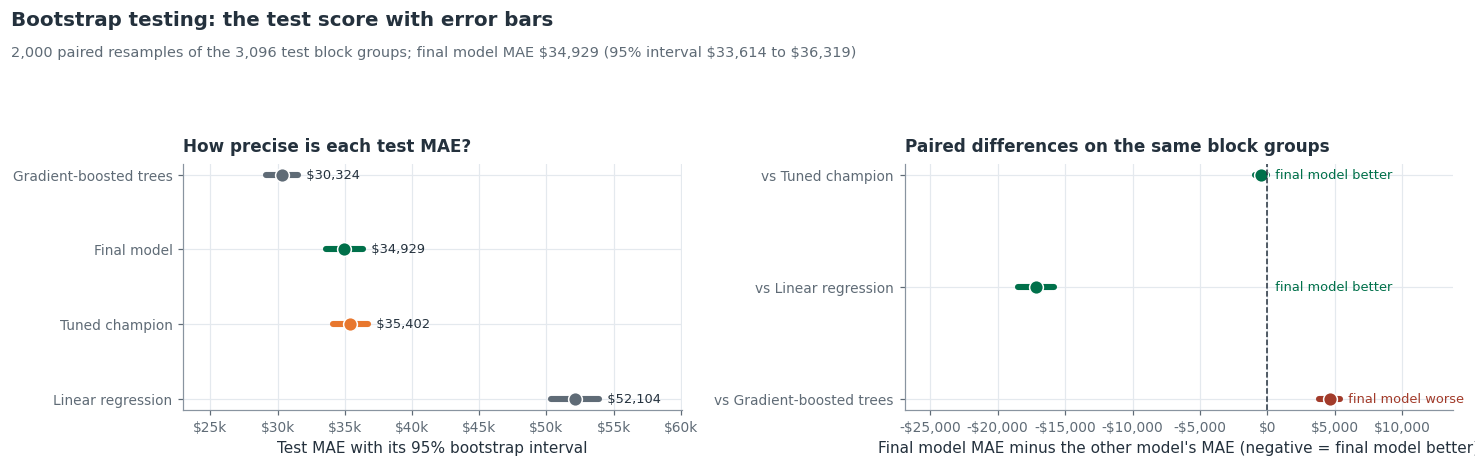

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3), gridspec_kw={"width_ratios": [1, 1.1]})
ax = axes[0]
order_m = boot_summary.sort_values("MAE").index.tolist()
for i, name in enumerate(order_m):
    r = boot_summary.loc[name]
    color = HIGHWAY if name == "Final model" else (POPPY if name == "Tuned champion" else SUBTLE)
    ax.plot([r["MAE low"] * DOLLARS, r["MAE high"] * DOLLARS], [i, i], color=color, lw=4, solid_capstyle="round")
    ax.plot(r["MAE"] * DOLLARS, i, "o", color=color, ms=9, markeredgecolor="white")
    ax.text(r["MAE high"] * DOLLARS, i, "  " + usd_plot(r["MAE"] * DOLLARS), fontsize=8.5, va="center")
ax.set_yticks(range(len(order_m)), order_m)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: usd_plot(v / 1000) + "k"))
ax.margins(x=0.25)
ax.set_xlabel("Test MAE with its 95% bootstrap interval")
ax.set_title("How precise is each test MAE?")
ax = axes[1]
names_p = paired_table.index.tolist()
for i, name in enumerate(names_p):
    r = paired_table.loc[name]
    color = {"final model better": HIGHWAY, "final model worse": REDWOOD}.get(r["verdict"], SUBTLE)
    ax.plot([r["95% CI low ($)"], r["95% CI high ($)"]], [i, i], color=color, lw=4, solid_capstyle="round")
    ax.plot(r["MAE difference ($)"], i, "o", color=color, ms=9, markeredgecolor="white")
    ax.text(max(r["95% CI high ($)"], 0), i, "  " + r["verdict"], fontsize=8.5, va="center", color=color)
ax.axvline(0, color=INK, lw=1, ls="--")
ax.set_yticks(range(len(names_p)), [n.replace("Final model vs ", "vs ") for n in names_p])
ax.invert_yaxis()
ax.margins(x=0.35)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: usd_plot(v)))
ax.set_xlabel("Final model MAE minus the other model's MAE (negative = final model better)")
ax.set_title("Paired differences on the same block groups")
fb = boot_summary.loc["Final model"]
headline(fig, "Bootstrap testing: the test score with error bars",
         f"{N_BOOT:,} paired resamples of the {len(y_test):,} test block groups; final model MAE "
         f"{usd_plot(fb['MAE'] * DOLLARS)} (95% interval {usd_plot(fb['MAE low'] * DOLLARS)} to "
         f"{usd_plot(fb['MAE high'] * DOLLARS)})")
plt.show()

### 6c.2 Random versus spatial cross-validation (development rows only)

In [58]:
from sklearn.model_selection import GroupKFold, KFold

CV_FOLDS = 3 if QUICK_MODE else 5
CV_EPOCHS = int(FINAL_RES["best_epoch"])
N_REGIONS = 25
idx_dev = np.concatenate([idx_train, idx_val])
X_dev, y_dev = X_all[idx_dev], y_all[idx_dev]
lat_dev, lon_dev = X_dev[:, FEATURES.index("Latitude")], X_dev[:, FEATURES.index("Longitude")]
coords_km = np.c_[lat_dev * 111.0, lon_dev * 111.0 * np.cos(np.deg2rad(37))]


def kmeans_regions(X, k, n_init=10, max_iter=300, seed=SEED):
    """Lloyd's k-means (Lloyd, 1982) with k-means++ seeding, in plain NumPy.
    Used instead of sklearn's KMeans, which fails on some Windows installs because of a
    threadpoolctl/OpenBLAS incompatibility."""
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    best_labels, best_inertia = None, np.inf
    for _ in range(n_init):
        centers = X[[rng.integers(len(X))]]
        for _ in range(1, k):                       # k-means++: distant points are likelier seeds
            d2 = ((X[:, None, :] - centers[None]) ** 2).sum(-1).min(axis=1)
            centers = np.vstack([centers, X[rng.choice(len(X), p=d2 / d2.sum())]])
        for _ in range(max_iter):
            labels = ((X[:, None, :] - centers[None]) ** 2).sum(-1).argmin(axis=1)
            new = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
                            for j in range(k)])
            converged = np.allclose(new, centers)
            centers = new
            if converged:
                break
        labels = ((X[:, None, :] - centers[None]) ** 2).sum(-1).argmin(axis=1)
        inertia = float(((X - centers[labels]) ** 2).sum())
        if inertia < best_inertia:
            best_labels, best_inertia = labels, inertia
    return best_labels


region = kmeans_regions(coords_km, N_REGIONS)


def cv_fold(scheme, k, tr, te):
    """Retrain the final configuration on one fold; the scaler is refitted on the fold's own training rows."""
    key = run_key({"scheme": scheme, "fold": k, "units": CHOSEN_UNITS, "act": CHOSEN_ACT, "epochs": CV_EPOCHS,
                   "seed": SEED, "n": int(len(tr)), "head": [int(i) for i in tr[:5]]})
    path = RUN_DIR / f"cv_{scheme}{k}_{key}.json"
    if USE_CACHE and path.exists():
        return {**json.loads(path.read_text()), "cached": True}
    fold_scaler = StandardScaler().fit(X_dev[tr])
    set_global_determinism(SEED)
    model = build_shallow_net(CHOSEN_UNITS, CHOSEN_ACT, X_dev.shape[1], name=f"cv_{scheme}{k}")
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    t0 = time.perf_counter()
    model.fit(fold_scaler.transform(X_dev[tr]).astype(np.float32), y_dev[tr], epochs=CV_EPOCHS,
              batch_size=BATCH_SIZE, shuffle=True, verbose=0)
    p = predict(model, fold_scaler.transform(X_dev[te]).astype(np.float32))
    res = {"scheme": scheme, "fold": k, "n_train": int(len(tr)), "n_test": int(len(te)),
           "MSE": float(np.mean((p - y_dev[te]) ** 2)), "MAE": float(np.mean(np.abs(p - y_dev[te]))),
           "R2": float(r2_score(y_dev[te], p)), "seconds": time.perf_counter() - t0}
    path.write_text(json.dumps(res))
    return {**res, "cached": False}


cv_rows, spatial_fold = [], np.full(len(idx_dev), -1)
for k, (tr, te) in enumerate(KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED).split(X_dev)):
    cv_rows.append(cv_fold("random", k, tr, te))
for k, (tr, te) in enumerate(GroupKFold(n_splits=CV_FOLDS).split(X_dev, y_dev, groups=region)):
    cv_rows.append(cv_fold("spatial", k, tr, te))
    spatial_fold[te] = k
for r in cv_rows:
    timing = "from cache" if r["cached"] else f"{r['seconds']:.0f} s"
    print(f"{r['scheme']:<8} fold {r['fold'] + 1}: MAE ${r['MAE'] * DOLLARS:>8,.0f} on {r['n_test']:>5,} held-out rows | {timing}")
cv_df = pd.DataFrame(cv_rows).drop(columns=["cached"])
cv_summary = cv_df.groupby("scheme")[["MAE", "MSE", "R2"]].agg(["mean", "std"])
display(cv_summary.round(4))
cv_mean = cv_df.groupby("scheme")["MAE"].mean()
optimism = float(100 * (cv_mean["spatial"] / cv_mean["random"] - 1))
print(f"Spatial cross-validation MAE differs from random cross-validation MAE by {optimism:+.1f}%")

random   fold 1: MAE $  37,957 on 3,509 held-out rows | 49 s
random   fold 2: MAE $  38,621 on 3,509 held-out rows | 48 s
random   fold 3: MAE $  36,399 on 3,509 held-out rows | 50 s
random   fold 4: MAE $  36,622 on 3,509 held-out rows | 49 s
random   fold 5: MAE $  36,803 on 3,508 held-out rows | 48 s
spatial  fold 1: MAE $  48,504 on 3,645 held-out rows | 69 s
spatial  fold 2: MAE $  45,750 on 3,523 held-out rows | 61 s
spatial  fold 3: MAE $  38,247 on 3,465 held-out rows | 61 s
spatial  fold 4: MAE $  43,997 on 3,452 held-out rows | 51 s
spatial  fold 5: MAE $  48,519 on 3,459 held-out rows | 60 s


MAE             MSE              R2        
           mean     std    mean     std    mean     std
scheme                                                 
random   0.3728  0.0096  0.3066  0.0323  0.7699  0.0253
spatial  0.4500  0.0424  0.4265  0.1125  0.6580  0.1434

Spatial cross-validation MAE differs from random cross-validation MAE by +20.7%


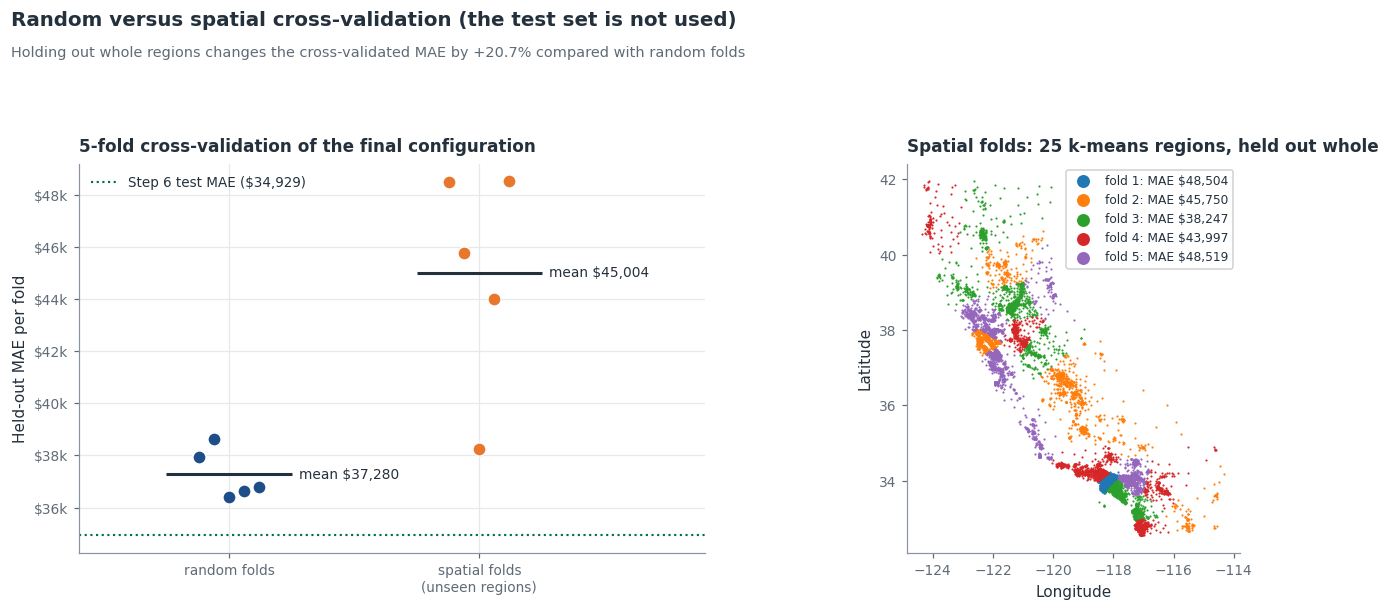

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
for i, scheme in enumerate(["random", "spatial"]):
    vals = cv_df.loc[cv_df["scheme"] == scheme, "MAE"].to_numpy() * DOLLARS
    ax.scatter(i + np.linspace(-0.12, 0.12, len(vals)), vals, s=75, color=[PACIFIC, POPPY][i], edgecolor="white", zorder=3)
    ax.hlines(vals.mean(), i - 0.25, i + 0.25, color=INK, lw=2)
    ax.text(i + 0.28, vals.mean(), "mean " + usd_plot(vals.mean()), va="center", fontsize=9)
ax.axhline(test_mae * DOLLARS, color=HIGHWAY, ls=":", lw=1.4, label=f"Step 6 test MAE ({usd_plot(test_mae * DOLLARS)})")
ax.set_xticks([0, 1], ["random folds", "spatial folds\n(unseen regions)"])
ax.set_xlim(-0.6, 1.9)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: usd_plot(v / 1000) + "k"))
ax.set_ylabel("Held-out MAE per fold")
ax.legend(loc="upper left")
ax.set_title(f"{CV_FOLDS}-fold cross-validation of the final configuration")
ax = axes[1]
fold_cmap = mpl.colormaps["tab10"]
for k in range(CV_FOLDS):
    m = spatial_fold == k
    mae_k = cv_df[(cv_df["scheme"] == "spatial") & (cv_df["fold"] == k)]["MAE"].iloc[0] * DOLLARS
    ax.scatter(lon_dev[m], lat_dev[m], s=2, color=fold_cmap(k), linewidths=0, label=f"fold {k + 1}: MAE {usd_plot(mae_k)}")
geo_axes(ax, cities=False)
ax.legend(loc="upper right", markerscale=6, fontsize=8, frameon=True, framealpha=0.9)
ax.set_title(f"Spatial folds: {N_REGIONS} k-means regions, held out whole")
headline(fig, "Random versus spatial cross-validation (the test set is not used)",
         f"Holding out whole regions changes the cross-validated MAE by {optimism:+.1f}% compared with random folds")
plt.show()

### 6c.3 Slice tests on the test predictions

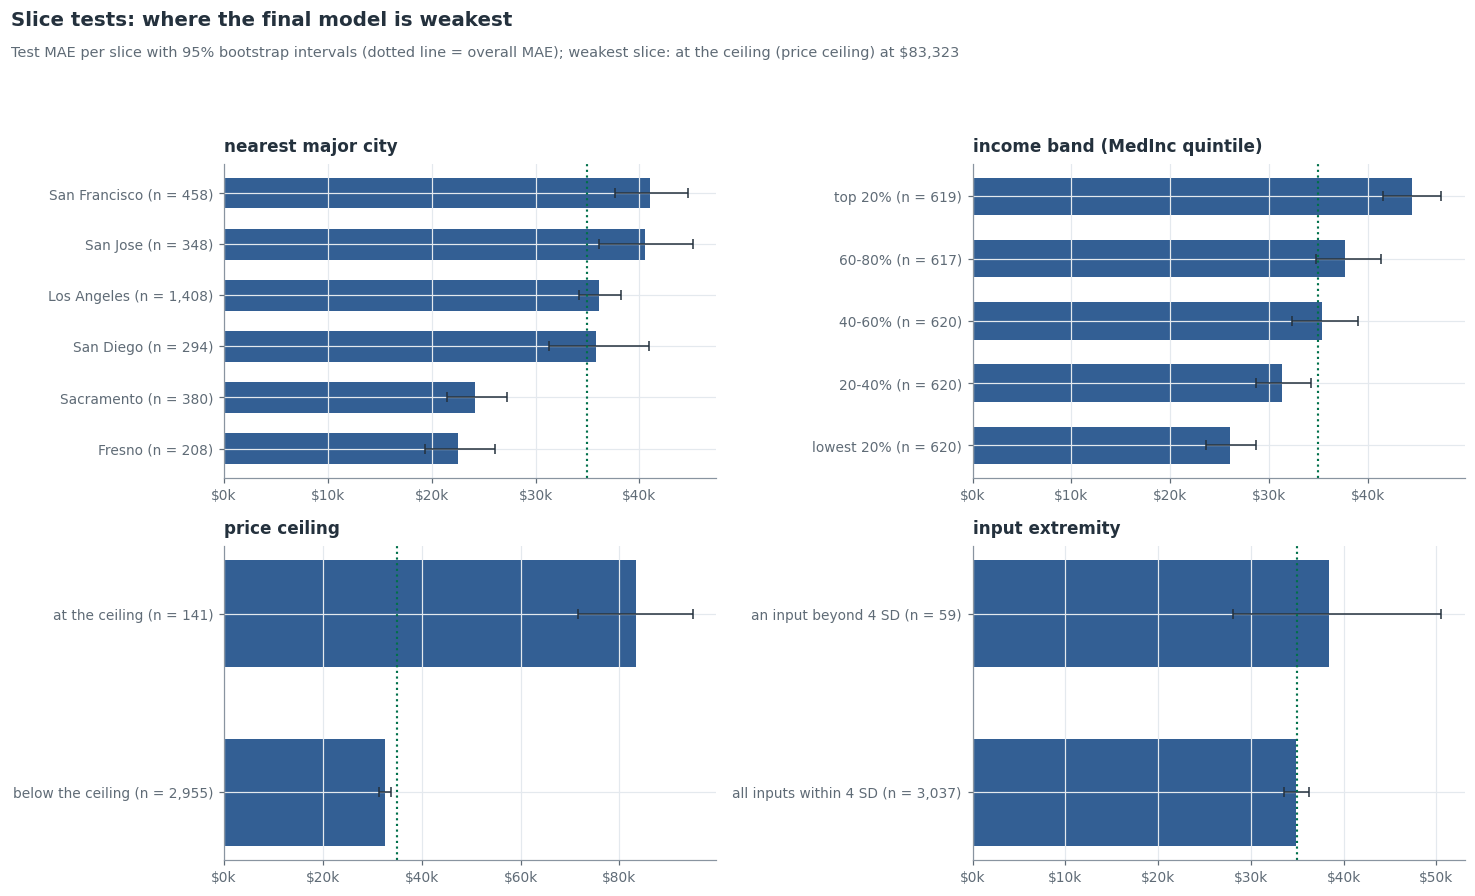

In [60]:
def nearest_city(lat_arr, lon_arr):
    names = list(CITIES)
    c = np.array([CITIES[n] for n in names])
    d = (lat_arr[:, None] - c[None, :, 0]) ** 2 + ((lon_arr[:, None] - c[None, :, 1]) * np.cos(np.deg2rad(37))) ** 2
    return np.array(names)[d.argmin(axis=1)]


income_band = pd.qcut(X_test[:, FEATURES.index("MedInc")], 5,
                      labels=["lowest 20%", "20-40%", "40-60%", "60-80%", "top 20%"])
SLICES = {
    "nearest major city": nearest_city(lat_t, lon_t),
    "income band (MedInc quintile)": np.asarray(income_band.astype(str)),
    "price ceiling": np.where(cap_test, "at the ceiling", "below the ceiling"),
    "input extremity": np.where(np.abs(X_test_s).max(axis=1) > 4, "an input beyond 4 SD", "all inputs within 4 SD"),
}


def slice_report(labels, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for lab in pd.unique(labels):
        m = labels == lab
        ae = abs_err[m]
        draws = ae[rng.integers(0, m.sum(), size=(n_boot, m.sum()))].mean(axis=1)
        lo, hi = np.percentile(draws, [2.5, 97.5])
        rows.append({"slice": str(lab), "block groups": int(m.sum()), "MAE ($)": ae.mean() * DOLLARS,
                     "CI low ($)": lo * DOLLARS, "CI high ($)": hi * DOLLARS,
                     "mean signed error ($)": resid[m].mean() * DOLLARS})
    return pd.DataFrame(rows).sort_values("MAE ($)", ascending=False).reset_index(drop=True)


slice_tables = {name: slice_report(labels) for name, labels in SLICES.items()}
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.2))
for ax, (name, tbl) in zip(axes.ravel(), slice_tables.items()):
    yy = np.arange(len(tbl))
    ax.barh(yy, tbl["MAE ($)"], color=PACIFIC, height=0.6, alpha=0.9)
    ax.errorbar(tbl["MAE ($)"], yy, xerr=[tbl["MAE ($)"] - tbl["CI low ($)"], tbl["CI high ($)"] - tbl["MAE ($)"]],
                fmt="none", ecolor=INK, capsize=3, lw=1)
    ax.axvline(test_mae * DOLLARS, color=HIGHWAY, ls=":", lw=1.4)
    ax.set_yticks(yy, [f"{s} (n = {n:,})" for s, n in zip(tbl["slice"], tbl["block groups"])])
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: usd_plot(v / 1000) + "k"))
    ax.set_title(name)
worst_name, worst_tbl = max(slice_tables.items(), key=lambda kv: kv[1]["MAE ($)"].iloc[0])
headline(fig, "Slice tests: where the final model is weakest",
         f"Test MAE per slice with 95% bootstrap intervals (dotted line = overall MAE); weakest slice: "
         f"{worst_tbl['slice'].iloc[0]} ({worst_name}) at {usd_plot(worst_tbl['MAE ($)'].iloc[0])}")
plt.show()

### 6c.4 Conformal prediction intervals

A point prediction says nothing about how far off it might be. Split conformal prediction turns the validation residuals into an interval around every new prediction. Without assuming any distribution for the errors, it guarantees that the interval covers the true value with at least the chosen probability on average, provided the calibration and test block groups are exchangeable (Vovk et al., 2005; Lei et al., 2018). For coverage level $1 - \alpha$ the interval is $\hat{y} \pm \hat{q}$, where $\hat{q}$ is the $\lceil (n + 1)(1 - \alpha) \rceil$-th smallest absolute validation residual among the $n$ calibration rows (Angelopoulos & Bates, 2023).

One caveat matters. The validation set also chose the epoch, the width and the activation, so it is not a perfectly untouched calibration set, and the guarantee is approximate rather than exact. The test set is the honest check: if the empirical test coverage sits close to the promised level, the intervals can be trusted in practice. The calibration residuals are exported with each model, so the dashboard and the API attach the same intervals to every prediction.

,promised coverage,half-width ($),test coverage,coverage at the ceiling,coverage below the ceiling
0,0.50,24548.0,0.5181,0.2553,0.5306
1,0.60,31298.0,0.6085,0.3262,0.6220
2,0.70,40074.0,0.7019,0.3972,0.7164
3,0.80,54453.0,0.8075,0.4610,0.8240
4,0.90,82868.0,0.9099,0.5603,0.9266
5,0.95,111339.0,0.9522,0.6879,0.9648


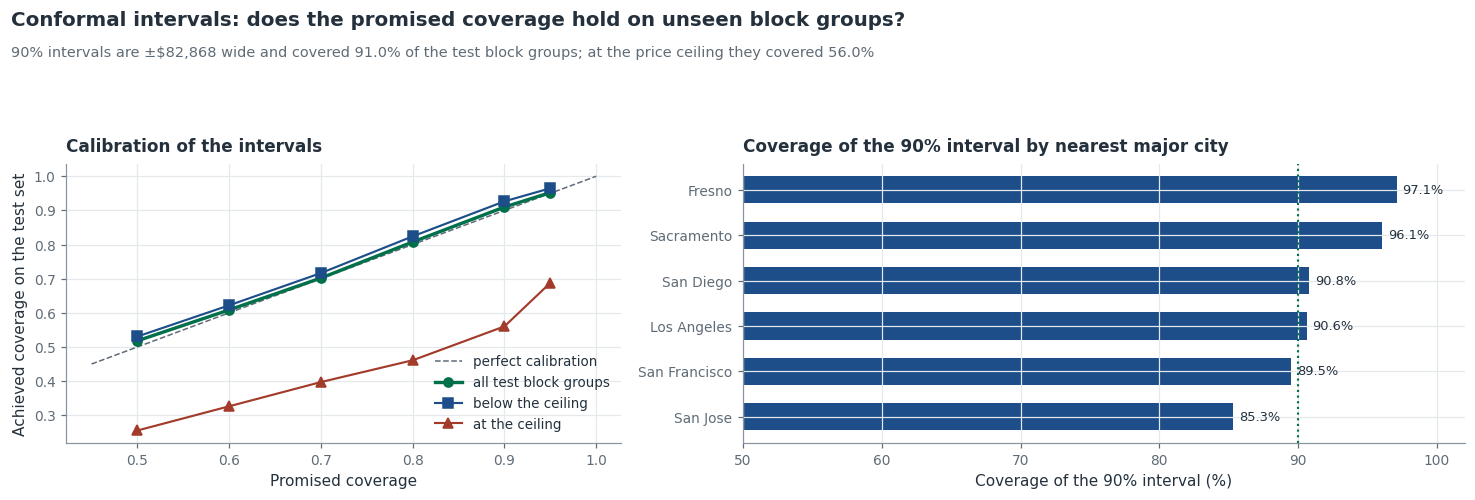

In [61]:
def conformal_halfwidth(scores, level):
    """Split-conformal half-width: the ceil((n + 1) * level)-th smallest calibration score."""
    s = np.sort(np.asarray(scores, dtype=float))
    k = int(np.ceil((len(s) + 1) * level))
    return float(s[k - 1]) if k <= len(s) else float("inf")


cal_scores = {"final": np.abs(y_val - predict(final_model, X_val_s)),
              "tuned": np.abs(y_val - predict(champion_model, VAL_INPUTS[CHAMP_FEATURES]))}
CONF_LEVELS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
conf_rows = []
for level in CONF_LEVELS:
    q = conformal_halfwidth(cal_scores["final"], level)
    covered = abs_err <= q
    conf_rows.append({"promised coverage": level, "half-width ($)": q * DOLLARS, "test coverage": covered.mean(),
                      "coverage at the ceiling": covered[cap_test].mean() if cap_test.any() else np.nan,
                      "coverage below the ceiling": covered[~cap_test].mean()})
conformal_table = pd.DataFrame(conf_rows)
display(conformal_table.round({"half-width ($)": 0, "test coverage": 4, "coverage at the ceiling": 4,
                               "coverage below the ceiling": 4}))
q90 = conformal_halfwidth(cal_scores["final"], 0.9)
cover90 = abs_err <= q90
city_cov = pd.Series(cover90).groupby(SLICES["nearest major city"]).mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
ax.plot([0.45, 1], [0.45, 1], color=SUBTLE, ls="--", lw=1, label="perfect calibration")
ax.plot(conformal_table["promised coverage"], conformal_table["test coverage"], color=HIGHWAY, marker="o", lw=2.2,
        label="all test block groups")
ax.plot(conformal_table["promised coverage"], conformal_table["coverage below the ceiling"], color=PACIFIC, marker="s",
        lw=1.4, label="below the ceiling")
ax.plot(conformal_table["promised coverage"], conformal_table["coverage at the ceiling"], color=REDWOOD, marker="^",
        lw=1.4, label="at the ceiling")
ax.set_xlabel("Promised coverage")
ax.set_ylabel("Achieved coverage on the test set")
ax.legend(loc="lower right")
ax.set_title("Calibration of the intervals")
ax = axes[1]
ax.barh(city_cov.index, city_cov.values * 100, color=PACIFIC, height=0.6)
ax.axvline(90, color=HIGHWAY, ls=":", lw=1.4)
for i, v in enumerate(city_cov.values):
    ax.text(v * 100 + 0.4, i, f"{v:.1%}", va="center", fontsize=8.5)
ax.set_xlim(max(0, min(50, city_cov.min() * 100 - 5)), 102)
ax.set_xlabel("Coverage of the 90% interval (%)")
ax.set_title("Coverage of the 90% interval by nearest major city")
headline(fig, "Conformal intervals: does the promised coverage hold on unseen block groups?",
         f"90% intervals are ±{usd_plot(q90 * DOLLARS)} wide and covered {cover90.mean():.1%} of the test block groups; "
         f"at the price ceiling they covered {cover90[cap_test].mean():.1%}")
plt.show()

### 6c.5 What the stronger tests show

The stronger tests sharpen the headline number considerably.

**The test score has error bars, and the test set was kind.** The bootstrap puts the test MAE at \$34,929, with a 95% interval of \$33,614 to \$36,319 (Efron & Tibshirani, 1993). Cross-validation suggests that the figure for a random new block group lies near the top of that range or above it. Five random folds of the development rows gave a mean MAE of \$37,280 with a fold-to-fold standard deviation of \$961, and every one of the five folds was worse than the test set. Together with the validation MAE of \$36,312, this says the 3,096 test block groups happened to be a little easier than average. A fair expectation for new block groups from familiar areas is \$35,000 to \$37,000.

**Unseen regions are much harder.** Holding out whole regions raised the cross-validated MAE to \$45,004, 20.7% above random folds. The spread across folds grew from \$961 to \$4,238, and one held-out region reached an R² of only 0.41. This is the clearest evidence in the study that a random split flatters the model: much of its accuracy comes from interpolating between neighbouring block groups it has already seen (Roberts et al., 2017).

**The model rankings are real, not noise.** In paired comparisons on identical resamples, the network beat linear regression by \$17,175 (95% interval \$15,822 to \$18,521) and lost to gradient-boosted trees by \$4,605 (\$3,797 to \$5,415). It also beat the tuned champion in MAE by a small but consistent \$473 (\$19 to \$932), even though the champion has the lower MSE. Tuning on squared error moved the model towards fewer large errors at the cost of slightly larger typical ones.

**The intervals keep their promise overall, but not everywhere.** The 90% conformal interval, ±\$82,868, covered 91.0% of the test block groups, and achieved coverage tracked the promise closely at every level from 50% (51.8% achieved) to 95% (95.2%) (Lei et al., 2018). The guarantee is marginal, though, and it shows (Angelopoulos & Bates, 2023). Coverage was only 56.0% for capped block groups and 85.3% around San Jose, against 96.1% around Sacramento and 97.1% around Fresno. One interval width fits everyone, so it is too narrow where prices and errors are high and too wide where they are low. Intervals whose width adapts to each block group, such as conformalized quantile regression, would address this (Romano et al., 2019).

**Who bears the errors.** MAE rises with income, from \$26,066 in the lowest fifth of block groups to \$44,366 in the highest. It also rises with the metropolitan setting, from \$22,576 around Fresno and \$24,187 around Sacramento to about \$41,000 around San Francisco and San Jose. Part of this is simply price level, since the same percentage error costs more dollars in an expensive market, but the absolute burden of the model's errors falls on the expensive coastal markets. Block groups with an extreme input were not measurably worse: their MAE was \$38,382, but its interval of \$28,087 to \$50,526 overlaps the rest.

<a id="ext-d"></a>

## 6d. Extension: export for the dashboard and cloud storage

The accompanying Streamlit dashboard presents these results interactively (Snowflake Inc., n.d.; Plotly Technologies Inc., 2015). It does not need TensorFlow: it re-implements the forward pass of the shallow network in NumPy from the exported weights and checks itself against predictions that Keras produced in this notebook. When the notebook runs inside the project repository (from its `notebooks/` folder), the files below go straight into the repository's `artifacts/` folder, ready to commit and deploy. The repository's `scripts/publish_artifacts.py` can also copy them to an S3-compatible bucket, from which the deployed app can load them. To keep the repository small, the larger files are gzip-compressed and the learning curves are rounded to six significant digits, which changes nothing visible. A `manifest.json` records a SHA-256 checksum for every file (National Institute of Standards and Technology, 2015), so the app refuses files that differ from what this notebook produced. Each model file also carries its validation residuals, which calibrate the conformal intervals that the app and the API attach to every prediction (Lei et al., 2018).

In [62]:
import gzip

for stale in ("histories.json", "dataset.csv", "test_predictions.csv"):   # uncompressed files from older runs
    (ART_DIR / stale).unlink(missing_ok=True)


def jsonable(o):
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


def records(df):
    return json.loads(df.reset_index().to_json(orient="records"))


def export_model(path, res, model, feature_mode, fitted_scaler, cal_residuals):
    W1, b1, W2, b2 = [np.asarray(a, dtype=np.float64) for a in res["best_weights"]]
    check_raw = X_test[:25].astype(np.float64)
    check_in = fitted_scaler.transform(log1p_heavy(check_raw) if feature_mode == "log" else check_raw).astype(np.float32)
    np.savez_compressed(path, W1=W1, b1=b1, W2=W2, b2=b2, activation=np.array(res["cfg"]["activation"]),
             feature_mode=np.array(feature_mode), log_idx=np.array(LOG_IDX), scaler_mean=fitted_scaler.mean_,
             scaler_scale=fitted_scaler.scale_, feature_names=np.array(FEATURES), check_raw=check_raw,
             check_pred=predict(model, check_in), best_epoch=np.array(res["best_epoch"]),
             cal_residuals=np.asarray(cal_residuals, dtype=np.float32))


results = {
    "meta": {"author": "Anush Goel", "generated": time.strftime("%Y-%m-%d %H:%M"),
             "versions": VERSIONS, "seed": SEED, "batch_size": BATCH_SIZE, "epochs": EPOCHS,
             "deterministic_ops": DETERMINISTIC_OPS, "quick_mode": QUICK_MODE, "robustness_seeds": ROBUSTNESS_SEEDS,
             "hpo_trials": len(trial_params), "hpo_confirm_seeds": HPO_CONFIRM_SEEDS, "schema_version": 3},
    "data": {"n_rows": int(len(X_df)), "features": FEATURES, "feature_info": FEATURE_INFO, "target": TARGET,
             "split_sizes": {k: int(len(v)) for k, v in SPLITS.items()}, "cap_count": int(at_cap.sum()),
             "cap_share": float(at_cap.mean()), "summary": json.loads(summary.to_json(orient="index"))},
    "baseline": {"best_epoch": baseline["best_epoch"], "best_val_loss": baseline["best_val_loss"],
                 "curve_stats": curve_stats(baseline), "repro_gap": repro_gap},
    "widths": {"table": records(width_table), "seed_table": records(width_seed_table),
               "selected": CHOSEN_UNITS, "decision": width_decision.to_dict()},
    "activations": {"table": records(act_table), "seed_table": records(act_seed_table), "selected": CHOSEN_ACT,
                    "decision": act_decision.to_dict(), "saturation": records(sat_table), "target_level": target_level},
    "hpo": {"space": SPACE, "trials": records(trials), "confirm_table": records(confirm_table),
            "champion_trial": CHAMP_TRIAL, "champion_cfg": champion["cfg"],
            "champion_best_val": champion["best_val_loss"]},
    "final": {"units": CHOSEN_UNITS, "activation": CHOSEN_ACT, "best_epoch": FINAL_RES["best_epoch"],
              "best_val_loss": FINAL_RES["best_val_loss"], "n_params": FINAL_RES["n_params"],
              "test_mse": test_mse, "test_mae": test_mae, "test_rmse": test_rmse, "test_r2": test_r2,
              "cap_table": records(cap_table), "pred_above_cap": int((y_pred_test > TARGET_CAP).sum())},
    "comparison_val": records(val_comparison),
    "comparison_test": records(test_comparison),
    "importance": records(imp.iloc[::-1]),
    "largest_errors": records(largest),
    "evaluation": {"n_boot": N_BOOT, "bootstrap": records(boot_summary), "paired": records(paired_table),
                   "cv_folds": CV_FOLDS, "cv_epochs": CV_EPOCHS, "n_regions": N_REGIONS, "cv": records(cv_df),
                   "cv_optimism_pct": optimism, "conformal": records(conformal_table), "conformal_q90": q90,
                   "coverage90_by_city": {k: float(v) for k, v in city_cov.items()},
                   "slices": {name: json.loads(tbl.to_json(orient="records")) for name, tbl in slice_tables.items()}},
}
(ART_DIR / "results.json").write_text(json.dumps(results, indent=2, default=jsonable))

histories = {name: {"cfg": r["cfg"], "history": r["history"], "best_epoch": r["best_epoch"],
                    "best_val_loss": r["best_val_loss"], "monitor": r["monitor"], "n_params": r["n_params"]}
             for name, r in RUN_LOG.items()}
def compact_floats(obj, digits=6):
    """Round floats to six significant digits: the curves look identical and the file shrinks."""
    if isinstance(obj, float):
        return float(f"{obj:.{digits}g}")
    if isinstance(obj, dict):
        return {k: compact_floats(v, digits) for k, v in obj.items()}
    if isinstance(obj, list):
        return [compact_floats(v, digits) for v in obj]
    return obj


GZIP = {"method": "gzip", "mtime": 0}          # mtime=0 makes the compressed bytes reproducible
with gzip.GzipFile(ART_DIR / "histories.json.gz", "wb", mtime=0) as fh:
    fh.write(json.dumps(compact_floats(histories), default=jsonable, separators=(",", ":")).encode("utf-8"))

split_label = np.empty(len(row_ids), dtype=object)
for name, idx in SPLITS.items():
    split_label[idx] = name
dataset = X_df.copy()
dataset[TARGET] = y_sr
dataset["split"] = split_label
fold_full = np.full(len(row_ids), -1)
fold_full[idx_dev] = spatial_fold
dataset["spatial_fold"] = fold_full          # -1 = test row, never used in cross-validation
dataset.to_csv(ART_DIR / "dataset.csv.gz", index_label="row_id", float_format="%.6g", compression=GZIP)

preds_df = pd.DataFrame(X_test, columns=FEATURES)
preds_df.insert(0, "row_id", idx_test)
preds_df["y_true"], preds_df["y_pred_final"], preds_df["y_pred_tuned"] = y_test, y_pred_test, y_pred_champ
preds_df["y_pred_linear"] = test_preds["Linear regression"]
preds_df["y_pred_hgb"] = test_preds["Gradient-boosted trees"]
preds_df.to_csv(ART_DIR / "test_predictions.csv.gz", index=False, float_format="%.6g", compression=GZIP)

export_model(ART_DIR / "model_final.npz", FINAL_RES, final_model, "raw", scaler, cal_scores["final"])
export_model(ART_DIR / "model_tuned.npz", champion, champion_model, CHAMP_FEATURES,
             scaler_log if CHAMP_FEATURES == "log" else scaler, cal_scores["tuned"])

ARTIFACT_FILES = ["results.json", "histories.json.gz", "dataset.csv.gz", "test_predictions.csv.gz",
                  "model_final.npz", "model_tuned.npz"]
manifest = {"schema_version": 3, "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
            "files": {name: {"sha256": hashlib.sha256((ART_DIR / name).read_bytes()).hexdigest(),
                             "bytes": (ART_DIR / name).stat().st_size} for name in ARTIFACT_FILES}}
(ART_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
for name, info in manifest["files"].items():
    print(f"{name:<26}{info['bytes'] / 1024:>8.0f} KB   sha256 {info['sha256'][:16]}")
print(f"{'total':<26}{sum(v['bytes'] for v in manifest['files'].values()) / 1024:>8.0f} KB")

results.json                    41 KB   sha256 04e0dc12c0f39048
histories.json.gz              127 KB   sha256 b99fa090a2a1c8ef
dataset.csv.gz                 507 KB   sha256 0b766c0a0249f762
test_predictions.csv.gz        124 KB   sha256 0f546fdedf830bf4
model_final.npz                 26 KB   sha256 c58fbe6a439c2a7e
model_tuned.npz                 26 KB   sha256 a51c322bf7df9559
total                          851 KB


<a id="step7"></a>

## 7. Final analysis and reflection

### Research question 1. How did hidden-layer size and activation function affect training behaviour (convergence, underfitting, overfitting) and validation performance, and how did they shape the choice of the final model?

Hidden-layer size controlled capacity in the expected direction, and within the 100-epoch budget more capacity was always better. Averaged over five seeds, the final training MSE fell from 0.316 at 16 units to 0.292 at 64 and 0.267 at 256, and the best validation MSE fell with it, from 0.331 to 0.315 and 0.292. The 16-unit network underfitted: its curves flattened earliest and at the highest errors. No width overfitted. The generalisation gap grew with width, from 0.018 to 0.025 and 0.031, which is the first sign of the trade-off between fitting and generalising (Goodfellow et al., 2016), but every validation curve was still falling at epoch 100 and every best epoch fell between 96 and 100. The widest network converged most slowly in relative terms, needing 72 epochs to achieve 95% of its improvement against about 33 for the others, and its validation curve was the noisiest, so for wider networks the best-epoch checkpoint did real work.

The activation function mattered even more than width. ReLU reached a mean best validation MSE of 0.292, against 0.328 for tanh and 0.359 for sigmoid, and it reached the common convergence target in 36 epochs, while neither smooth activation reached it at all. Saturation was not the cause, since only about 1% of tanh and sigmoid pre-activations were saturated. The cause was that both functions are nearly linear in the region where standardised inputs and Glorot initialisation place them, and that sigmoid's gradient there is a quarter of tanh's (Glorot & Bengio, 2010; LeCun et al., 2012). The price of ReLU's speed was stability, since its late-training validation curve was the most volatile of the three.

Both choices were made on validation data alone, using five-seed means and the one-standard-error rule, so neither depends on a lucky run (Bouthillier et al., 2021; Hastie et al., 2009). At each step the winner's results across seeds did not overlap the runner-up's, so no plausible re-run would have changed the decision. The final model is therefore 256 ReLU units, with the weights from epoch 96, the epoch with the lowest validation loss.

### Research question 2. What do the final results indicate about the model's ability to generalise to validation and test data, and which technique could improve performance or generalisation, and why?

The final model generalises well within the territory it was trained on, and noticeably less well beyond it. Its validation MAE was \$36,312. On the test set, evaluated once after every decision, its MAE was \$34,929 (95% bootstrap interval \$33,614 to \$36,319) and its R² 0.801, and its 90% conformal interval of ±\$82,868 covered 91.0% of test block groups. The test score is slightly flattering. All five random cross-validation folds were worse (mean \$37,280), so \$35,000 to \$37,000 is a fairer expectation for new block groups in familiar areas. Generalisation to new places is weaker still. Spatial cross-validation raised the MAE to \$45,004, 20.7% above random folds, and the remaining errors concentrate where prices are high: in the coastal metros and, above all, at the \$500,000 ceiling, where the MAE reaches \$83,323 and interval coverage falls to 56%.

The most promising single improvement is to give the network better location features, and the evidence points there from three directions. Latitude and longitude are by far the most important inputs: shuffling either raises the test MSE by more than 800%. The largest errors are expensive coastal pockets that the model blurs into their regional average. And pricing an unseen region costs 20.7% in accuracy. A single hidden layer has to assemble California's price surface from two raw coordinates, so it can represent sharp local differences, such as the narrow coastal premium visible on the learned map, only by spending many units. Supplying distances to the coast and to the main employment centres, or a smooth set of location features such as radial basis functions centred on clusters of block groups, would hand the network that structure directly. It should reduce error most where error is now largest, and the spatial cross-validation in 6c is the honest yardstick for testing it (Roberts et al., 2017).

The evidence on two other candidates is weaker. Regularised training was tested in 5b: L2 weight decay, a log transform of the heavy-tailed inputs and early stopping lowered the MSE but slightly raised the MAE. Training for longer did not help at all, since 300 epochs matched 100. Better location features therefore remain the stronger recommendation.

<a id="references"></a>

## References

<div class="references">

Abadi, M., Barham, P., Chen, J., Chen, Z., Davis, A., Dean, J., Devin, M., Ghemawat, S., Irving, G., Isard, M., Kudlur, M., Levenberg, J., Monga, R., Moore, S., Murray, D. G., Steiner, B., Tucker, P., Vasudevan, V., Warden, P., . . . Zheng, X. (2016). TensorFlow: A system for large-scale machine learning. In *Proceedings of the 12th USENIX Symposium on Operating Systems Design and Implementation* (pp. 265–283). USENIX Association. https://www.usenix.org/conference/osdi16/technical-sessions/presentation/abadi

Angelopoulos, A. N., & Bates, S. (2023). Conformal prediction: A gentle introduction. *Foundations and Trends in Machine Learning, 16*(4), 494–591. https://doi.org/10.1561/2200000101

Anthropic. (2026). *Claude* (Opus 5.5) [Large language model]. https://claude.ai

Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research, 13*, 281–305. https://jmlr.org/papers/v13/bergstra12a.html

Bouthillier, X., Delaunay, P., Bronzi, M., Trofimov, A., Nichyporuk, B., Szeto, J., Mohammadi Sepahvand, N., Raff, E., Madan, K., Voleti, V., Ebrahimi Kahou, S., Michalski, V., Arbel, T., Pal, C., Varoquaux, G., & Vincent, P. (2021). Accounting for variance in machine learning benchmarks. *Proceedings of Machine Learning and Systems, 3*, 747–769. https://proceedings.mlsys.org/paper_files/paper/2021/hash/0184b0cd3cfb185989f858a1d9f5c1eb-Abstract.html

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://jmlr.org/papers/v11/cawley10a.html

Chollet, F., & others. (2015). *Keras* [Computer software]. https://keras.io

Clevert, D.-A., Unterthiner, T., & Hochreiter, S. (2016). *Fast and accurate deep network learning by exponential linear units (ELUs)* [Conference paper]. International Conference on Learning Representations, San Juan, Puerto Rico. https://doi.org/10.48550/arXiv.1511.07289

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC. https://doi.org/10.1201/9780429246593

Fisher, A., Rudin, C., & Dominici, F. (2019). All models are wrong, but many are useful: Learning a variable's importance by studying an entire class of prediction models simultaneously. *Journal of Machine Learning Research, 20*(177), 1–81. https://jmlr.org/papers/v20/18-760.html

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics, 29*(5), 1189–1232. https://doi.org/10.1214/aos/1013203451

Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In *Proceedings of the Thirteenth International Conference on Artificial Intelligence and Statistics* (pp. 249–256). PMLR. https://proceedings.mlr.press/v9/glorot10a.html

Glorot, X., Bordes, A., & Bengio, Y. (2011). Deep sparse rectifier neural networks. In *Proceedings of the Fourteenth International Conference on Artificial Intelligence and Statistics* (pp. 315–323). PMLR. https://proceedings.mlr.press/v15/glorot11a.html

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org

Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? In *Advances in Neural Information Processing Systems 35* (pp. 507–520). Curran Associates. https://proceedings.neurips.cc/paper_files/paper/2022/hash/0378c7692da36807bdec87ab043cdadc-Abstract-Datasets_and_Benchmarks.html

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., . . . Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

Hendrycks, D., & Gimpel, K. (2016). *Gaussian error linear units (GELUs)* (arXiv:1606.08415). arXiv. https://doi.org/10.48550/arXiv.1606.08415

Hornik, K., Stinchcombe, M., & White, H. (1989). Multilayer feedforward networks are universal approximators. *Neural Networks, 2*(5), 359–366. https://doi.org/10.1016/0893-6080(89)90020-8

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), Article 15. https://doi.org/10.1145/2382577.2382579

Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. In *Advances in Neural Information Processing Systems 30* (pp. 3146–3154). Curran Associates.

Keskar, N. S., Mudigere, D., Nocedal, J., Smelyanskiy, M., & Tang, P. T. P. (2017). *On large-batch training for deep learning: Generalization gap and sharp minima* [Conference paper]. International Conference on Learning Representations, Toulon, France. https://doi.org/10.48550/arXiv.1609.04836

Kingma, D. P., & Ba, J. (2014). *Adam: A method for stochastic optimization* (arXiv:1412.6980). arXiv. https://doi.org/10.48550/arXiv.1412.6980

Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. In *Proceedings of the 14th International Joint Conference on Artificial Intelligence* (Vol. 2, pp. 1137–1143). Morgan Kaufmann.

Krogh, A., & Hertz, J. A. (1992). A simple weight decay can improve generalization. In J. E. Moody, S. J. Hanson, & R. P. Lippmann (Eds.), *Advances in Neural Information Processing Systems 4* (pp. 950–957). Morgan Kaufmann.

LeCun, Y. A., Bottou, L., Orr, G. B., & Müller, K.-R. (2012). Efficient BackProp. In G. Montavon, G. B. Orr, & K.-R. Müller (Eds.), *Neural networks: Tricks of the trade* (2nd ed., pp. 9–48). Springer. https://doi.org/10.1007/978-3-642-35289-8_3

Lei, J., G'Sell, M., Rinaldo, A., Tibshirani, R. J., & Wasserman, L. (2018). Distribution-free predictive inference for regression. *Journal of the American Statistical Association, 113*(523), 1094–1111. https://doi.org/10.1080/01621459.2017.1307116

Lloyd, S. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory, 28*(2), 129–137. https://doi.org/10.1109/TIT.1982.1056489

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

Nair, V., & Hinton, G. E. (2010). Rectified linear units improve restricted Boltzmann machines. In *Proceedings of the 27th International Conference on Machine Learning* (pp. 807–814). Omnipress.

National Institute of Standards and Technology. (2015). *Secure hash standard (SHS)* (FIPS PUB 180-4). U.S. Department of Commerce. https://doi.org/10.6028/NIST.FIPS.180-4

Pace, R. K., & Barry, R. (1997). Sparse spatial autoregressions. *Statistics & Probability Letters, 33*(3), 291–297. https://doi.org/10.1016/S0167-7152(96)00140-X

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Plotly Technologies Inc. (2015). *Collaborative data science*. https://plot.ly

Prechelt, L. (2012). Early stopping—But when? In G. Montavon, G. B. Orr, & K.-R. Müller (Eds.), *Neural networks: Tricks of the trade* (2nd ed., pp. 53–67). Springer. https://doi.org/10.1007/978-3-642-35289-8_5

Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., Guillera-Arroita, G., Hauenstein, S., Lahoz-Monfort, J. J., Schröder, B., Thuiller, W., Warton, D. I., Wintle, B. A., Hartig, F., & Dormann, C. F. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography, 40*(8), 913–929. https://doi.org/10.1111/ecog.02881

Robinson, W. S. (1950). Ecological correlations and the behavior of individuals. *American Sociological Review, 15*(3), 351–357. https://doi.org/10.2307/2087176

Romano, Y., Patterson, E., & Candès, E. J. (2019). Conformalized quantile regression. In *Advances in Neural Information Processing Systems 32* (pp. 3543–3553). Curran Associates.

scikit-learn developers. (n.d.). *California Housing dataset*. In *scikit-learn user guide*. Retrieved October 5, 2026, from https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

Snowflake Inc. (n.d.). *Streamlit* [Computer software]. https://streamlit.io

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*(56), 1929–1958. https://jmlr.org/papers/v15/srivastava14a.html

Tobin, J. (1958). Estimation of relationships for limited dependent variables. *Econometrica, 26*(1), 24–36. https://doi.org/10.2307/1907382

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., . . . SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

Vovk, V., Gammerman, A., & Shafer, G. (2005). *Algorithmic learning in a random world*. Springer. https://doi.org/10.1007/b106715

</div>

<a id="appendix"></a>

## Appendix. Acknowledgements, tools and run log

**Data.** The California Housing data as distributed with scikit-learn (Pace & Barry, 1997; Pedregosa et al., 2011).

**Software.** TensorFlow and Keras for the networks (Abadi et al., 2016; Chollet et al., 2015); NumPy, pandas and SciPy for computation (Harris et al., 2020; McKinney, 2010; Virtanen et al., 2020); scikit-learn for splitting, scaling, metrics and the reference models (Pedregosa et al., 2011); Matplotlib for the figures (Hunter, 2007); Streamlit and Plotly for the dashboard (Snowflake Inc., n.d.; Plotly Technologies Inc., 2015). Library calls follow the official documentation.

**AI assistance.** Claude (Anthropic, 2026) was used as an assistant for drafting and reviewing code and text. Every result reported in this notebook comes from code executed in it, and every claim can be traced to an output cell.

In [63]:
trained_now = [r for r in RUN_LOG.values() if not r.get("cached")]
print(f"Training runs in this notebook : {len(RUN_LOG)} ({len(trained_now)} trained in this session, "
      f"{len(RUN_LOG) - len(trained_now)} reloaded from the cache)")
print(f"Training time in this session  : {sum(r['seconds'] for r in trained_now) / 60:.1f} minutes")
print(f"Deterministic kernels          : {DETERMINISTIC_OPS}")
print(f"Quick mode                     : {QUICK_MODE}")
for lib, ver in VERSIONS.items():
    print(f"{lib:<31}: {ver}")

Training runs in this notebook : 57 (57 trained in this session, 0 reloaded from the cache)
Training time in this session  : 96.7 minutes
Deterministic kernels          : True
Quick mode                     : False
python                         : 3.11.7
tensorflow                     : 2.12.0
keras                          : 2.12.0
numpy                          : 1.23.5
pandas                         : 1.5.3
scikit-learn                   : 1.2.2
scipy                          : 1.10.1
matplotlib                     : 3.8.0
